<a href="https://colab.research.google.com/github/jxff2k/DataAnalytics/blob/main/Ola_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## OLA DATA ANALYTICS

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
df = pd.read_excel("/content/ola_drivers_cleaned.xlsx")
df.head(5)

,Log_Record,MMM_YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining_Designation,Grade,Total_Business_Value,Quarterly_Rating
0,0,2019-01-01,1,28.0,0,C23,2,57387,2018-12-24,NaT,1,1,2381060,2
1,1,2019-02-01,1,28.0,0,C23,2,57387,2018-12-24,NaT,1,1,-665480,2
2,2,2019-03-01,1,28.0,0,C23,2,57387,2018-12-24,2019-03-11,1,1,0,2
3,3,2020-11-01,2,31.0,0,C7,2,67016,2020-11-06,NaT,2,2,0,1
4,4,2020-12-01,2,31.0,0,C7,2,67016,2020-11-06,NaT,2,2,0,1


In [ ]:
df.dtypes

,0
Log_Record,int64
MMM_YY,datetime64[ns]
Driver_ID,int64
Age,float64
Gender,int64
City,object
Education_Level,int64
Income,int64
Dateofjoining,datetime64[ns]
LastWorkingDate,datetime64[ns]


In [ ]:
## Null values

df.isnull().sum()

,0
Log_Record,0
MMM_YY,0
Driver_ID,0
Age,0
Gender,0
City,0
Education_Level,0
Income,0
Dateofjoining,0
LastWorkingDate,17488


In [ ]:
## Installing Pyspark

!apt-get update
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!pip install pyspark -q

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["PYSPARK_PYTHON"] = "python3"

from pyspark.sql import SparkSession

# Create optimized Spark session for Colab
spark = SparkSession.builder \
    .appName("ola_drivers") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "2g") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.driver.extraJavaOptions", "-Xss4m") \
    .getOrCreate()

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [3,873 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [6,214 kB]
Fetched 10.2 MB in 2s (4,501 kB/s)
Reading packa

In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("ola_drivers").getOrCreate()
spark_df = spark.createDataFrame(df)
spark_df.show(5)

+----------+-------------------+---------+----+------+----+---------------+------+-------------------+-------------------+-------------------+-----+--------------------+----------------+
|Log_Record|             MMM_YY|Driver_ID| Age|Gender|City|Education_Level|Income|      Dateofjoining|    LastWorkingDate|Joining_Designation|Grade|Total_Business_Value|Quarterly_Rating|
+----------+-------------------+---------+----+------+----+---------------+------+-------------------+-------------------+-------------------+-----+--------------------+----------------+
|         0|2019-01-01 00:00:00|        1|28.0|     0| C23|              2| 57387|2018-12-24 00:00:00|               NULL|                  1|    1|             2381060|               2|
|         1|2019-02-01 00:00:00|        1|28.0|     0| C23|              2| 57387|2018-12-24 00:00:00|               NULL|                  1|    1|             -665480|               2|
|         2|2019-03-01 00:00:00|        1|28.0|     0| C23|      

In [ ]:
## Rename the spark dataframe as the existing name
spark_df.createOrReplaceTempView("ola_drivers")

**Basic Analysis**

In [ ]:
spark.sql("select count(*) as Total_Reports_by_drivers from ola_drivers").show()

+------------------------+
|Total_Reports_by_drivers|
+------------------------+
|                   19104|
+------------------------+



In [ ]:
spark.sql("select count(distinct Driver_ID) as Total_Drivers from ola_drivers").show()

+-------------+
|Total_Drivers|
+-------------+
|         2381|
+-------------+



In [ ]:
spark.sql("select datediff(day, min(MMM_YY), max(LastWorkingDate)) as Total_tripdays_made_overall from ola_drivers").show()

+---------------------------+
|Total_tripdays_made_overall|
+---------------------------+
|                        727|
+---------------------------+



In [ ]:
spark.sql("""select count(*) * 30 as Total_trips_made_per_report from ola_drivers """).show()

+---------------------------+
|Total_trips_made_per_report|
+---------------------------+
|                     573120|
+---------------------------+



In [ ]:
total_days_for_trips_df = spark.sql("""select datediff(day, min(Dateofjoining), max(LastWorkingDate)) as Total_days_for_trips_being_taken from ola_drivers """)
total_days_for_trips_df.show()

+--------------------------------+
|Total_days_for_trips_being_taken|
+--------------------------------+
|                            2828|
+--------------------------------+



In [ ]:
total_tripdays_overall_df = spark.sql("select datediff(day, min(MMM_YY), max(LastWorkingDate)) as Total_tripdays_made_overall from ola_drivers")
total_tripdays_overall_df.show()

+---------------------------+
|Total_tripdays_made_overall|
+---------------------------+
|                        727|
+---------------------------+



In [ ]:
total_tripdays_overall = total_tripdays_overall_df.collect()[0]['Total_tripdays_made_overall']
total_days_for_trips = total_days_for_trips_df.collect()[0]['Total_days_for_trips_being_taken']
total_tripdays_overall_plot = total_tripdays_overall * 100/ total_days_for_trips
total_tripdays_remaining_plot = 1 - total_tripdays_overall

print(f"Total Trip Days Overall: {total_tripdays_overall}")
print(f"Total Days for Trips Being Taken: {total_days_for_trips}")


Total Trip Days Overall: 727
Total Days for Trips Being Taken: 2828


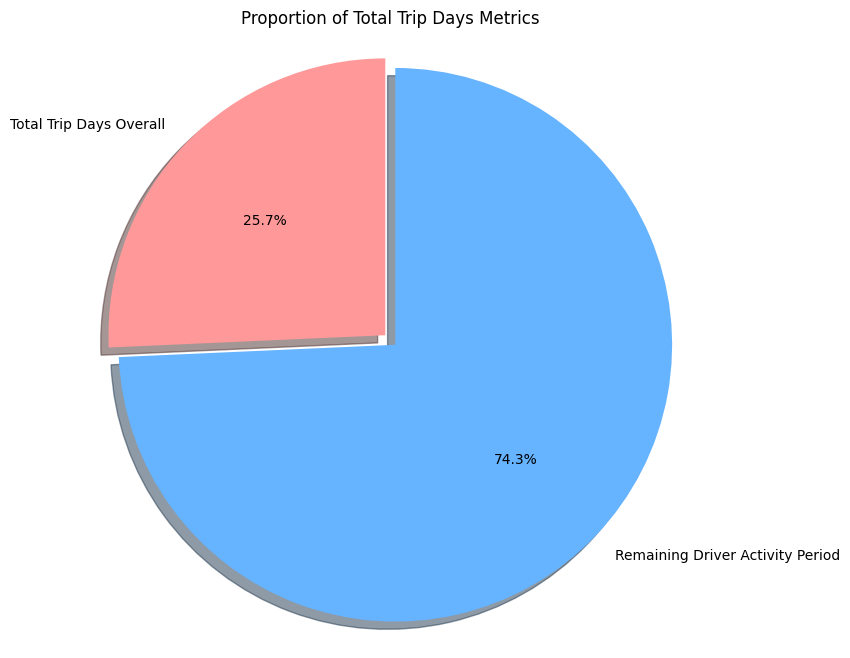

In [ ]:
labels = ['Total Trip Days Overall', 'Remaining Driver Activity Period']
sizes = [total_tripdays_overall, total_days_for_trips - total_tripdays_overall]
colors = ['#ff9999','#66b3ff']
explode = (0.05, 0) # explode 1st slice

fig1, ax1 = plt.subplots(figsize=(8, 8))
ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=90)
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.title('Proportion of Total Trip Days Metrics')
plt.show()

In [ ]:
## Total reports not recorded

spark.sql("""select DATEDIFF(month , min(Dateofjoining), min(MMM_YY)) as Unrecorded_reports from ola_drivers""").show()

+------------------+
|Unrecorded_reports|
+------------------+
|                69|
+------------------+



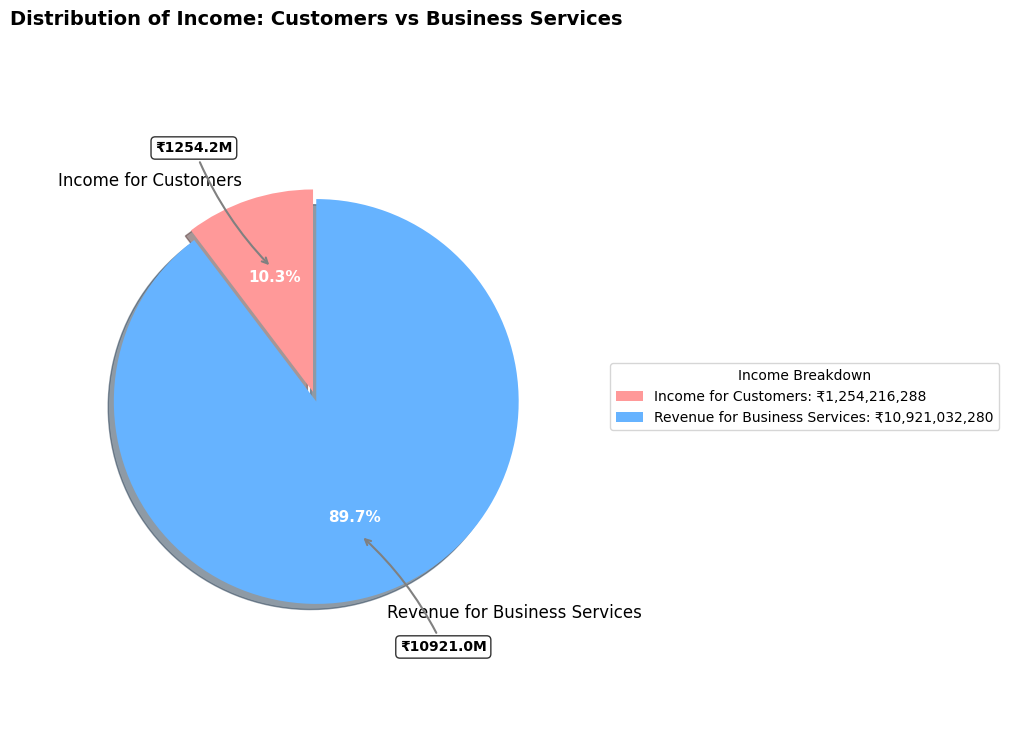


Summary Statistics:
Total Income from Customers: ₹1,254,216,288.00
Total Income from Business Services: ₹10,921,032,280.00
Overall Total: ₹12,175,248,568.00
Customer Income Proportion: 10.3%
Business Services Proportion: 89.7%


In [ ]:
# Execute the SQL query and get the results
income_distribution = spark.sql("""
    SELECT
        SUM(Income) as Total_Income,
        SUM(Total_Business_Value) as Total_Business_Value
    FROM ola_drivers
""").collect()[0]

total_income = income_distribution['Total_Income']
total_business_value = income_distribution['Total_Business_Value']
overall_total = total_income + total_business_value

# Calculate proportions
income_for_customers_proportion = total_income / overall_total if overall_total > 0 else 0
income_for_business_services_proportion = total_business_value / overall_total if overall_total > 0 else 0

# Data for the pie chart
labels = ['Income for Customers', 'Revenue for Business Services']
sizes = [income_for_customers_proportion, income_for_business_services_proportion]
colors = ['#ff9999', '#66b3ff']
explode = (0.05, 0)  # Slightly explode the first slice

# Create the pie chart with better styling
fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    shadow=True,
    startangle=90,
    textprops={'fontsize': 12}
)

# Improve the title and overall styling
plt.title('Distribution of Income: Customers vs Business Services',
          fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')

# Enhance the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

# Add numerical values with better formatting
for i, wedge in enumerate(wedges):
    ang = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))

    horizontalalignment = 'center' if abs(x) < 1e-6 else 'left' if x > 0 else 'right'

    # Choose value based on slice
    value = total_income if i == 0 else total_business_value

    # Format the value nicely
    if value >= 1e6:
        formatted_value = f'₹{value/1e6:.1f}M'
    elif value >= 1e3:
        formatted_value = f'₹{value/1e3:.1f}K'
    else:
        formatted_value = f'₹{value:,.0f}'

    # Add annotation with arrow
    ax.annotate(
        formatted_value,
        xy=(x * 0.7, y * 0.7),  # Point to the middle of the slice
        xytext=(x * 1.3, y * 1.3),  # Text position
        horizontalalignment=horizontalalignment,
        fontsize=10,
        fontweight='bold',
        arrowprops=dict(
            arrowstyle="->",
            color='gray',
            lw=1.5,
            connectionstyle="arc3,rad=0.1"
        ),
        bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8)
    )

# Add a legend with values
legend_labels = [f'{label}: ₹{value:,.0f}' for label, value in
                zip(labels, [total_income, total_business_value])]
ax.legend(wedges, legend_labels, title="Income Breakdown",
          loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSummary Statistics:")
print(f"Total Income from Customers: ₹{total_income:,.2f}")
print(f"Total Income from Business Services: ₹{total_business_value:,.2f}")
print(f"Overall Total: ₹{overall_total:,.2f}")
print(f"Customer Income Proportion: {income_for_customers_proportion:.1%}")
print(f"Business Services Proportion: {income_for_business_services_proportion:.1%}")

In [ ]:
## Basic Summary Statistics

df.describe().T

,count,mean,min,25%,50%,75%,max,std
Log_Record,19104.0,9551.5,0.0,4775.75,9551.5,14327.25,19103.0,5514.994107
MMM_YY,19104,2019-12-11 02:09:29.849246464,2019-01-01 00:00:00,2019-06-01 00:00:00,2019-12-01 00:00:00,2020-07-01 00:00:00,2020-12-01 00:00:00,NaN
Driver_ID,19104.0,1415.591133,1.0,710.0,1417.0,2137.0,2788.0,810.705321
Age,19104.0,34.650453,21.0,30.0,34.0,39.0,58.0,6.264545
Gender,19104.0,0.418813,0.0,0.0,0.0,1.0,1.0,0.493378
Education_Level,19104.0,1.021671,0.0,0.0,1.0,2.0,2.0,0.800167
Income,19104.0,65652.025126,10747.0,42383.0,60087.0,83969.0,188418.0,30914.515344
Dateofjoining,19104,2018-04-28 20:52:54.874371840,2013-04-01 00:00:00,2016-11-29 12:00:00,2018-09-12 00:00:00,2019-11-05 00:00:00,2020-12-28 00:00:00,NaN
LastWorkingDate,1616,2019-12-21 20:59:06.534653696,2018-12-31 00:00:00,2019-06-06 00:00:00,2019-12-20 12:00:00,2020-07-03 00:00:00,2020-12-28 00:00:00,NaN
Joining_Designation,19104.0,1.690536,1.0,1.0,1.0,2.0,5.0,0.836984


**QUARTERLY RATING**

In [ ]:
from pyspark.sql import Window
from pyspark.sql.functions import lag, when

# Define a window specification to partition by Driver_ID and order by MMM_YY
windowSpec = Window.partitionBy("Driver_ID").orderBy("MMM_YY")

# Add a new column 'Previous_Quarterly_Rating' using the lag function
spark_df = spark_df.withColumn("Previous_Quarterly_Rating", lag("Quarterly_Rating", 1).over(windowSpec))

# Determine if the quarterly rating has increased
spark_df = spark_df.withColumn("Quarterly_Rating_Increased",
                               when(spark_df["Quarterly_Rating"] > spark_df["Previous_Quarterly_Rating"], 1)
                               .otherwise(0))

# Show the updated DataFrame with the new columns
spark_df.show(15)

# Recreate the temporary view to include the new column
spark_df.createOrReplaceTempView("ola_drivers")

+----------+-------------------+---------+----+------+----+---------------+------+-------------------+-------------------+-------------------+-----+--------------------+----------------+-------------------------+--------------------------+
|Log_Record|             MMM_YY|Driver_ID| Age|Gender|City|Education_Level|Income|      Dateofjoining|    LastWorkingDate|Joining_Designation|Grade|Total_Business_Value|Quarterly_Rating|Previous_Quarterly_Rating|Quarterly_Rating_Increased|
+----------+-------------------+---------+----+------+----+---------------+------+-------------------+-------------------+-------------------+-----+--------------------+----------------+-------------------------+--------------------------+
|         0|2019-01-01 00:00:00|        1|28.0|     0| C23|              2| 57387|2018-12-24 00:00:00|               NULL|                  1|    1|             2381060|               2|                     NULL|                         0|
|         1|2019-02-01 00:00:00|        

**Increasing Quaterly Rating on Active Drivers**

In [ ]:
# Identify active drivers
active_drivers_df = spark.sql("SELECT DISTINCT Driver_ID as Active_members FROM ola_drivers WHERE Driver_ID NOT IN (SELECT DISTINCT Driver_ID FROM ola_drivers WHERE LastWorkingDate IS NOT NULL)")

# Rename the 'Active_members' column to 'Driver_ID' for joining
active_drivers_df = active_drivers_df.withColumnRenamed("Active_members", "Driver_ID")

# Join with main dataframe and calculate sum of Quarterly_Rating_Increased for active drivers
active_driver_change_sum = spark_df.join(active_drivers_df, "Driver_ID").groupBy("Driver_ID").sum("Quarterly_Rating_Increased")

# Show the result
active_driver_change_sum.show()

# Get the count of active drivers with increase sum
print(active_driver_change_sum.count())

+---------+-------------------------------+
|Driver_ID|sum(Quarterly_Rating_Increased)|
+---------+-------------------------------+
|       26|                              1|
|      191|                              2|
|     1224|                              2|
|     1145|                              0|
|      243|                              0|
|       54|                              3|
|      296|                              2|
|      926|                              1|
|      348|                              0|
|      415|                              1|
|     1077|                              1|
|      112|                              1|
|      385|                              0|
|      237|                              0|
|      427|                              0|
|     1050|                              3|
|     1157|                              0|
|       77|                              2|
|      532|                              2|
|     1200|                     

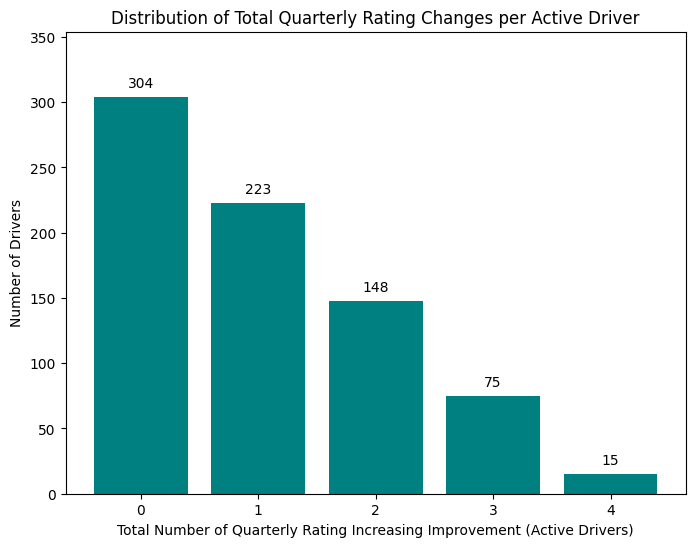

In [ ]:
# Group by the sum of Quarterly_Rating_Increased and count the occurrences for active drivers
active_change_counts = active_driver_change_sum.groupBy("sum(Quarterly_Rating_Increased)").count().orderBy("sum(Quarterly_Rating_Increased)")

# Convert to pandas DataFrame for plotting
active_change_counts_pd = active_change_counts.toPandas()

# Create a bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar(active_change_counts_pd["sum(Quarterly_Rating_Increased)"].astype(str), active_change_counts_pd["count"], color='teal')
plt.xlabel('Total Number of Quarterly Rating Increasing Improvement (Active Drivers)')
plt.ylabel('Number of Drivers')
plt.title('Distribution of Total Quarterly Rating Changes per Active Driver')

# Add labels to the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.ylim(0, active_change_counts_pd["count"].max() + 50) # Set the upper limit of the y-axis

plt.show()

- Around **461 (60%)** Active drivers have been involved in quarterly rating increased.

- **Maximal Successive improvement** on **quarterly increased** have been observed as **1.9%** of the total drivers in the current phase.

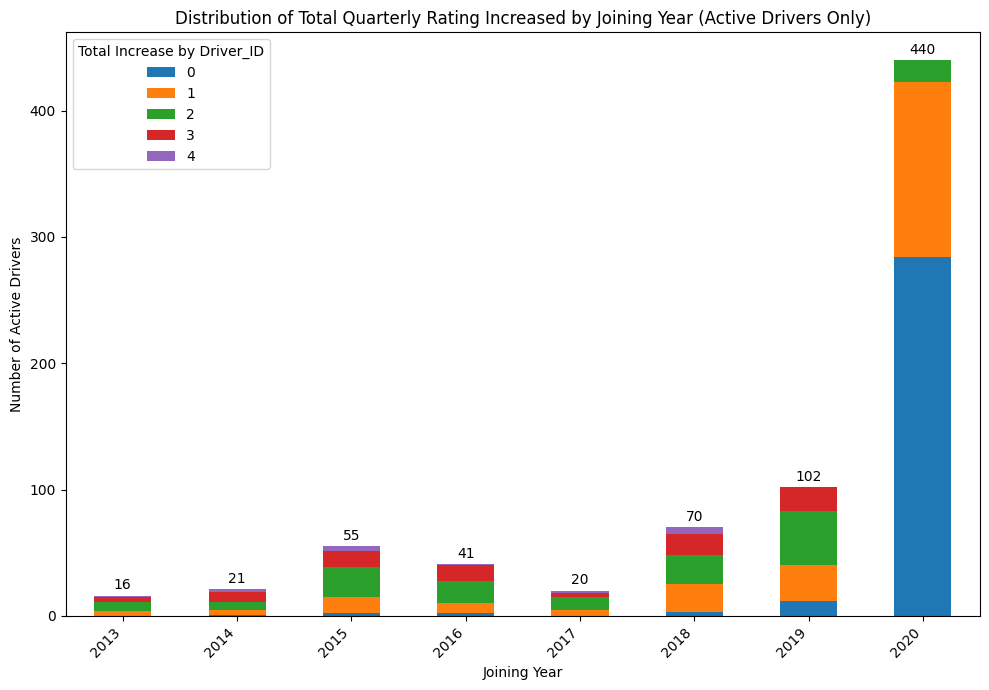

In [ ]:
from pyspark.sql.functions import year
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Extract joining year and calculate total increases per driver
driver_yearly_changes_sum = spark_df.withColumn("Joining_Year", year("Dateofjoining")) \
                                    .groupBy("Joining_Year", "Driver_ID") \
                                    .sum("Quarterly_Rating_Increased") \
                                    .withColumnRenamed("sum(Quarterly_Rating_Increased)", "Total_Increased")

# Join with active drivers and group by joining year and total increases, then count occurrences
yearly_changes_distribution = driver_yearly_changes_sum.join(active_drivers_df, "Driver_ID") \
                                                        .groupBy("Joining_Year", "Total_Increased").count().orderBy("Joining_Year", "Total_Increased")

# Convert to pandas for plotting and pivot for stacked bar chart
yearly_changes_distribution_pd = yearly_changes_distribution.toPandas()
pivot_df = yearly_changes_distribution_pd.pivot(index='Joining_Year', columns='Total_Increased', values='count').fillna(0)

# Create stacked bar chart
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.xlabel('Joining Year')
plt.ylabel('Number of Active Drivers')
plt.title('Distribution of Total Quarterly Rating Increased by Joining Year (Active Drivers Only)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Total Increase by Driver_ID')
plt.tight_layout()

# Add total count labels on top of the stacks
for i, year in enumerate(pivot_df.index):
    total = pivot_df.loc[year].sum()
    ax.text(i, total + 5, int(total), ha='center')


plt.show()

- **Higher quarterly increasing variation** are evident till **2018** depicting all the **four changes**.

**Increasing Quarterly Rating by Inactive Drivers**

In [ ]:
# Identify left drivers
left_drivers_df = spark.sql("SELECT DISTINCT Driver_ID as Left_members FROM ola_drivers WHERE LastWorkingDate is NOT NULL")

# Rename the 'Active_members' column to 'Driver_ID' for joining
left_drivers_df = left_drivers_df.withColumnRenamed("Left_members", "Driver_ID")

# Join with main dataframe and calculate sum of Quarterly_Rating_Increased for active drivers
left_driver_changes_sum = spark_df.join(left_drivers_df, "Driver_ID").groupBy("Driver_ID").sum("Quarterly_Rating_Increased")
left_driver_changes_sum.show()

# Get the count of active drivers with increase sum
print(left_driver_changes_sum.count())

+---------+-------------------------------+
|Driver_ID|sum(Quarterly_Rating_Increased)|
+---------+-------------------------------+
|       29|                              0|
|      474|                              0|
|      964|                              0|
|       65|                              2|
|      418|                              0|
|      541|                              1|
|      558|                              0|
|     1010|                              2|
|     1258|                              0|
|     1277|                              0|
|     1360|                              0|
|      222|                              0|
|      270|                              0|
|      293|                              0|
|      938|                              1|
|      278|                              0|
|      442|                              0|
|      705|                              0|
|     1175|                              0|
|     1202|                     

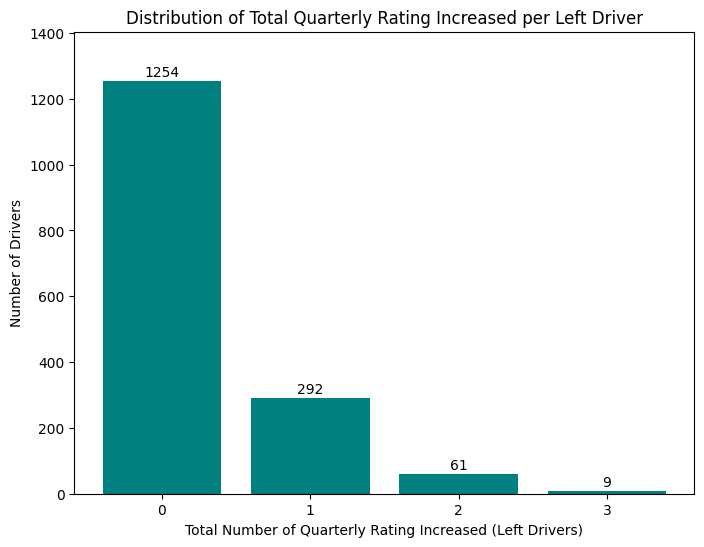

In [ ]:
# Group by the sum of Quarterly_Rating_Increased and count the occurrences for left drivers
left_changes_counts = left_driver_changes_sum.groupBy("sum(Quarterly_Rating_Increased)").count().orderBy("sum(Quarterly_Rating_Increased)")

# Convert to pandas DataFrame for plotting
left_changes_counts_pd = left_changes_counts.toPandas()

# Create a bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar(left_changes_counts_pd["sum(Quarterly_Rating_Increased)"].astype(str), left_changes_counts_pd["count"], color='teal')
plt.xlabel('Total Number of Quarterly Rating Increased (Left Drivers)')
plt.ylabel('Number of Drivers')
plt.title('Distribution of Total Quarterly Rating Increased per Left Driver')

# Add labels to the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.ylim(0, left_changes_counts_pd["count"].max() + 150) # Set the upper limit of the y-axis

plt.show()

- Total number of left drivers come upto **362 (22.40%)**. With comparison on Active drivers shows a huge drop in the quarterly value, as per the variation with respect to the population growth there is **37.6%** deficit giving a downward slope on the driver retention.

- Quarterly increase on left drivers per rate is lesser depicting a figure around 14.29% (~ 5% lesser to active drivers). As total increase on quarterly changes are only on **3-scale** (means **3** is the number of changes after the left drivers, whereas **4-scale** is for active drivers which a maximal successive improvement)

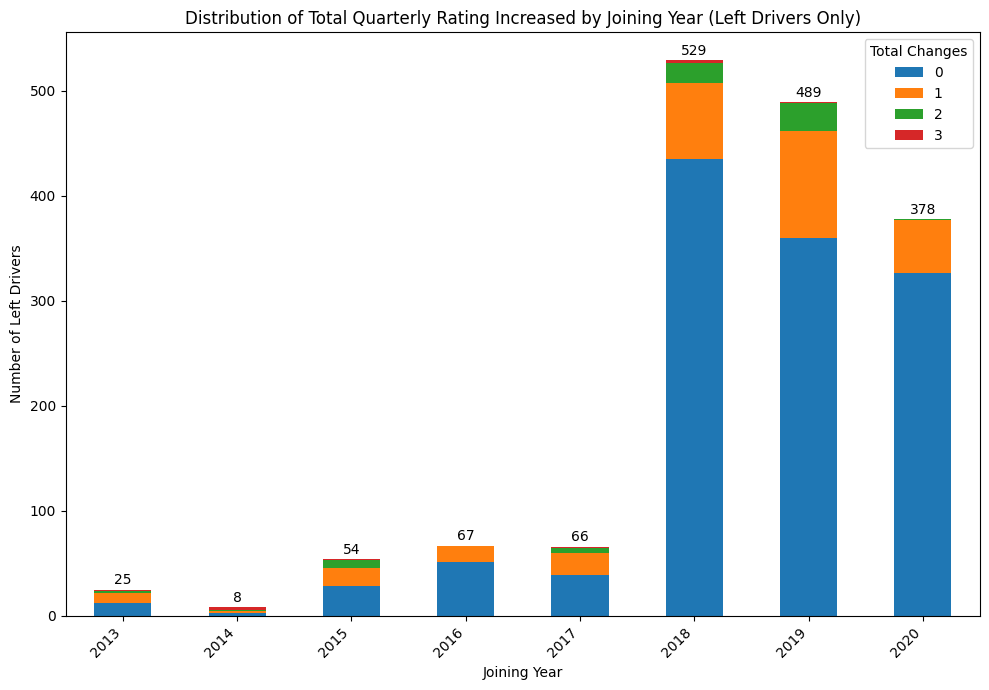

In [ ]:
from pyspark.sql.functions import year
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Extract joining year and calculate total increases per driver
driver_yearly_changes_sum = spark_df.withColumn("Joining_Year", year("Dateofjoining")) \
                                    .groupBy("Joining_Year", "Driver_ID") \
                                    .sum("Quarterly_Rating_Increased") \
                                    .withColumnRenamed("sum(Quarterly_Rating_Increased)", "Total_Increased")

# Identify left drivers
left_drivers_df = spark.sql("SELECT DISTINCT Driver_ID FROM ola_drivers WHERE LastWorkingDate IS NOT NULL")

# Join with left drivers and group by joining year and total increases, then count occurrences
yearly_changes_distribution = driver_yearly_changes_sum.join(left_drivers_df, "Driver_ID") \
                                                        .groupBy("Joining_Year", "Total_Increased").count().orderBy("Joining_Year", "Total_Increased")

# Convert to pandas for plotting and pivot for stacked bar chart
yearly_changes_distribution_pd = yearly_changes_distribution.toPandas()
pivot_df = yearly_changes_distribution_pd.pivot(index='Joining_Year', columns='Total_Increased', values='count').fillna(0)

# Create stacked bar chart
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.xlabel('Joining Year')
plt.ylabel('Number of Left Drivers')
plt.title('Distribution of Total Quarterly Rating Increased by Joining Year (Left Drivers Only)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Total Changes')
plt.tight_layout()

# Add total count labels on top of the stacks
for i, year in enumerate(pivot_df.index):
    total = pivot_df.loc[year].sum()
    ax.text(i, total + 5, int(total), ha='center')


plt.show()

In [ ]:
spark.sql("SELECT count(distinct Driver_ID) as Total_Improvement_by_Drivers from ola_drivers where Quarterly_Rating_Increased == 1").show()

+----------------------------+
|Total_Improvement_by_Drivers|
+----------------------------+
|                         823|
+----------------------------+



**Quarterly Rating Decline on Active Drivers**

In [ ]:
from pyspark.sql import Window
from pyspark.sql.functions import lag, when, year

# Define a window specification to partition by Driver_ID and order by MMM_YY
windowSpec = Window.partitionBy("Driver_ID").orderBy("MMM_YY")

# Add a new column 'Previous_Quarterly_Rating' using the lag function
spark_df = spark_df.withColumn("Previous_Quarterly_Rating", lag("Quarterly_Rating", 1).over(windowSpec))

# Determine if the quarterly rating has declined
spark_df = spark_df.withColumn("Quarterly_Rating_Declined",
                               when(spark_df["Quarterly_Rating"] < spark_df["Previous_Quarterly_Rating"], 1)
                               .otherwise(0))

# Show the updated DataFrame with the new columns
spark_df.show(15)

# Recreate the temporary view to include the new column
spark_df.createOrReplaceTempView("ola_drivers")

+----------+-------------------+---------+----+------+----+---------------+------+-------------------+-------------------+-------------------+-----+--------------------+----------------+-------------------------+--------------------------+-------------------------+
|Log_Record|             MMM_YY|Driver_ID| Age|Gender|City|Education_Level|Income|      Dateofjoining|    LastWorkingDate|Joining_Designation|Grade|Total_Business_Value|Quarterly_Rating|Previous_Quarterly_Rating|Quarterly_Rating_Increased|Quarterly_Rating_Declined|
+----------+-------------------+---------+----+------+----+---------------+------+-------------------+-------------------+-------------------+-----+--------------------+----------------+-------------------------+--------------------------+-------------------------+
|         0|2019-01-01 00:00:00|        1|28.0|     0| C23|              2| 57387|2018-12-24 00:00:00|               NULL|                  1|    1|             2381060|               2|                

In [ ]:
# Identify active drivers
active_drivers_df = spark.sql("SELECT DISTINCT Driver_ID as Active_members FROM ola_drivers WHERE Driver_ID NOT IN (SELECT DISTINCT Driver_ID FROM ola_drivers WHERE LastWorkingDate IS NOT NULL)")

# Rename the 'Active_members' column to 'Driver_ID' for joining
active_drivers_df = active_drivers_df.withColumnRenamed("Active_members", "Driver_ID")

# Join with main dataframe and calculate sum of Quarterly_Rating_Declined for active drivers
active_driver_decline_sum = spark_df.join(active_drivers_df, "Driver_ID").groupBy("Driver_ID").sum("Quarterly_Rating_Declined")

# Show the result
active_driver_decline_sum.show()

# Get the count of active drivers with decline sum
print("Active Drivers Decline Count:")
print(active_driver_decline_sum.count())

+---------+------------------------------+
|Driver_ID|sum(Quarterly_Rating_Declined)|
+---------+------------------------------+
|       26|                             2|
|      191|                             1|
|     1224|                             0|
|     1145|                             0|
|      243|                             0|
|       54|                             2|
|      296|                             2|
|      926|                             1|
|      348|                             0|
|      415|                             0|
|     1077|                             2|
|      112|                             2|
|      385|                             0|
|      237|                             0|
|      427|                             0|
|     1050|                             4|
|     1157|                             0|
|       77|                             1|
|      532|                             0|
|     1200|                             1|
+---------+

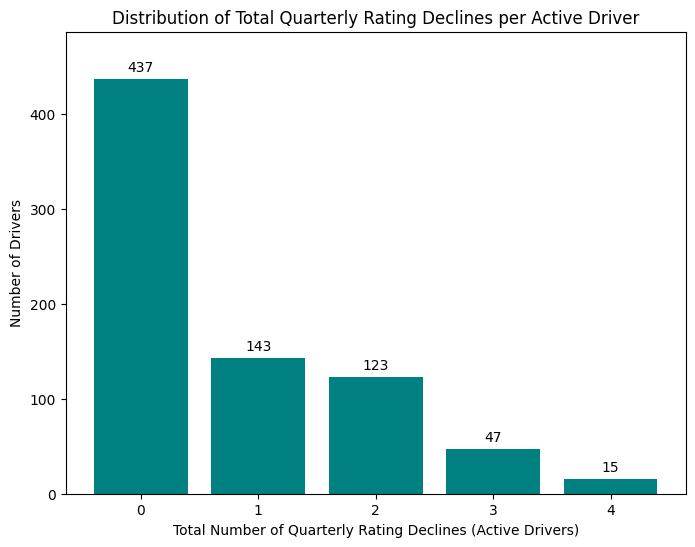

In [ ]:
# Group by the sum of Quarterly_Rating_Declined and count the occurrences for active drivers
active_decline_counts = active_driver_decline_sum.groupBy("sum(Quarterly_Rating_Declined)").count().orderBy("sum(Quarterly_Rating_Declined)")

# Convert to pandas DataFrame for plotting
active_decline_counts_pd = active_decline_counts.toPandas()

# Create a bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar(active_decline_counts_pd["sum(Quarterly_Rating_Declined)"].astype(str), active_decline_counts_pd["count"], color='teal')
plt.xlabel('Total Number of Quarterly Rating Declines (Active Drivers)')
plt.ylabel('Number of Drivers')
plt.title('Distribution of Total Quarterly Rating Declines per Active Driver')

# Add labels to the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.ylim(0, active_decline_counts_pd["count"].max() + 50) # Set the upper limit of the y-axis

plt.show()

- Total number of quarterly decline is experienced by **42.87%** of the entire active drivers.

- Quarterly decline till **2 changes** are got by **34.77%** of the drivers and the remaining 8.1% for the quarterly decline **more than 3**. Shows that sudden changes on decline does not give a quick attrition rate which would be a decisive factor on **customer retentional measures**.

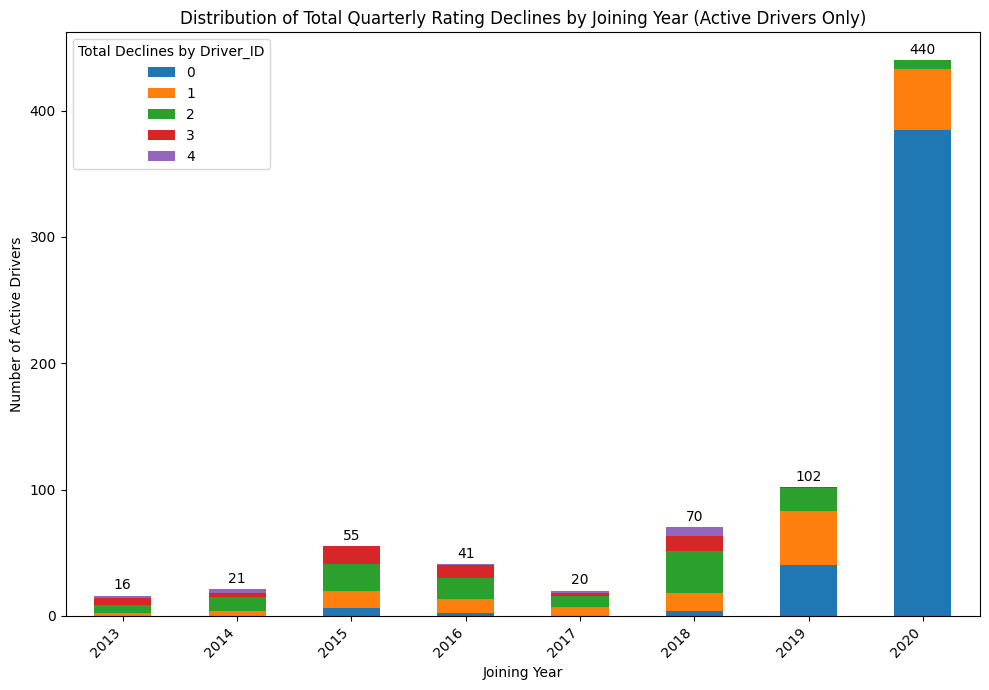

In [ ]:
# Extract joining year and calculate total declines per driver for active drivers
active_driver_yearly_declines_sum = spark_df.withColumn("Joining_Year", year("Dateofjoining")) \
                                    .join(active_drivers_df, "Driver_ID") \
                                    .groupBy("Joining_Year", "Driver_ID") \
                                    .sum("Quarterly_Rating_Declined") \
                                    .withColumnRenamed("sum(Quarterly_Rating_Declined)", "Total_Declined")

# Group by joining year and total declines, then count occurrences for active drivers
active_yearly_declines_distribution = active_driver_yearly_declines_sum.groupBy("Joining_Year", "Total_Declined").count().orderBy("Joining_Year", "Total_Declined")

# Convert to pandas for plotting and pivot for stacked bar chart
active_yearly_declines_distribution_pd = active_yearly_declines_distribution.toPandas()
pivot_df_active = active_yearly_declines_distribution_pd.pivot(index='Joining_Year', columns='Total_Declined', values='count').fillna(0)

# Create stacked bar chart for active drivers
ax_active = pivot_df_active.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.xlabel('Joining Year')
plt.ylabel('Number of Active Drivers')
plt.title('Distribution of Total Quarterly Rating Declines by Joining Year (Active Drivers Only)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Total Declines by Driver_ID')
plt.tight_layout()

# Add total count labels on top of the stacks for active drivers
for i, joining_year in enumerate(pivot_df_active.index):
    total = pivot_df_active.loc[joining_year].sum()
    ax_active.text(i, total + 5, int(total), ha='center')

plt.show()

**Quarterly Rating Decline on Left Drivers**

In [ ]:
# Identify left drivers
left_drivers_df = spark.sql("SELECT DISTINCT Driver_ID as Left_members FROM ola_drivers WHERE LastWorkingDate is NOT NULL")

# Rename the 'Left_members' column to 'Driver_ID' for joining
left_drivers_df = left_drivers_df.withColumnRenamed("Left_members", "Driver_ID")

# Join with main dataframe and calculate sum of Quarterly_Rating_Declined for left drivers
left_driver_declines_sum = spark_df.join(left_drivers_df, "Driver_ID").groupBy("Driver_ID").sum("Quarterly_Rating_Declined")
left_driver_declines_sum.show()

# Get the count of left drivers with decline sum
print("Left Drivers Decline Count:")
print(left_driver_declines_sum.count())

+---------+------------------------------+
|Driver_ID|sum(Quarterly_Rating_Declined)|
+---------+------------------------------+
|       29|                             1|
|      474|                             0|
|      964|                             0|
|       65|                             2|
|      418|                             1|
|      541|                             1|
|      558|                             2|
|     1010|                             3|
|     1258|                             0|
|     1277|                             0|
|     1360|                             0|
|      222|                             0|
|      270|                             0|
|      293|                             0|
|      938|                             1|
|      278|                             0|
|      442|                             0|
|      705|                             0|
|     1175|                             1|
|     1202|                             0|
+---------+

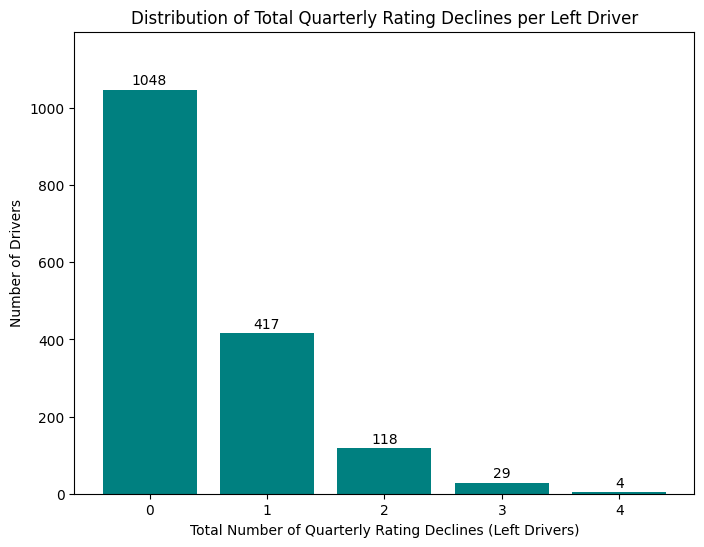

In [ ]:
# Group by the sum of Quarterly_Rating_Declined and count the occurrences for left drivers
left_declines_counts = left_driver_declines_sum.groupBy("sum(Quarterly_Rating_Declined)").count().orderBy("sum(Quarterly_Rating_Declined)")

# Convert to pandas DataFrame for plotting
left_declines_counts_pd = left_declines_counts.toPandas()

# Create a bar plot for left drivers
plt.figure(figsize=(8, 6))
bars_left = plt.bar(left_declines_counts_pd["sum(Quarterly_Rating_Declined)"].astype(str), left_declines_counts_pd["count"], color='teal')
plt.xlabel('Total Number of Quarterly Rating Declines (Left Drivers)')
plt.ylabel('Number of Drivers')
plt.title('Distribution of Total Quarterly Rating Declines per Left Driver')

# Add labels to the bars for left drivers
for bar in bars_left:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.ylim(0, left_declines_counts_pd["count"].max() + 150) # Set the upper limit of the y-axis

plt.show()

- Attrition rates are higher on the initial quarterly rating changes giving **25.80%** of the Total left drivers. On comparison with the active drivers the drivers in these group are more susceptable on sensitivity to changes on decline on the first decline rather than on the progressive decline.

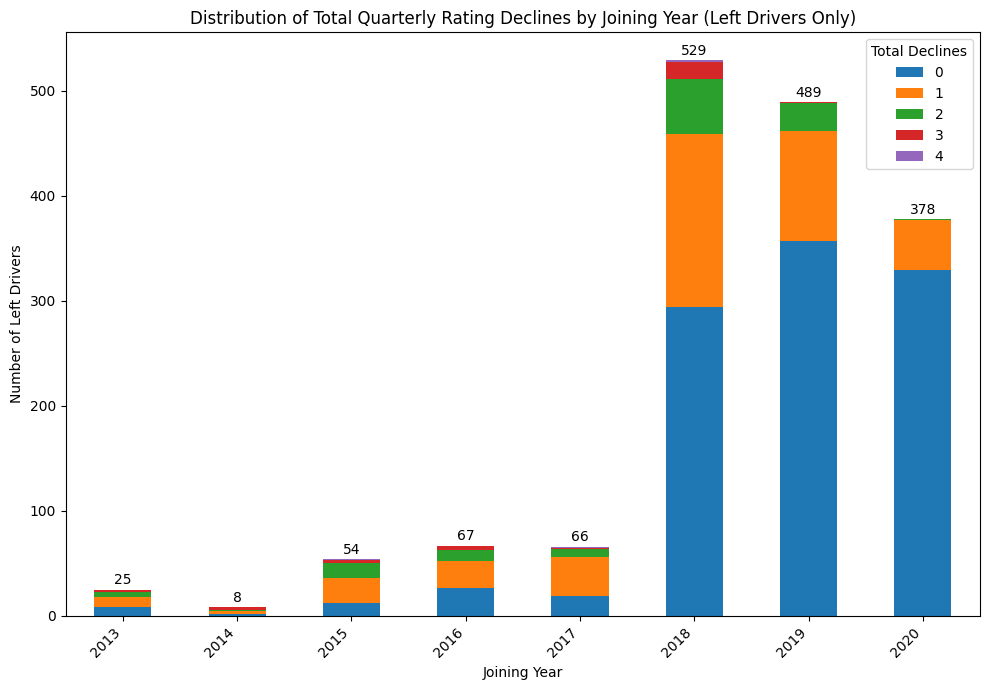

In [ ]:
# Extract joining year and calculate total declines per driver for left drivers
left_driver_yearly_declines_sum = spark_df.withColumn("Joining_Year", year("Dateofjoining")) \
                                    .join(left_drivers_df, "Driver_ID") \
                                    .groupBy("Joining_Year", "Driver_ID") \
                                    .sum("Quarterly_Rating_Declined") \
                                    .withColumnRenamed("sum(Quarterly_Rating_Declined)", "Total_Declined")

# Group by joining year and total declines, then count occurrences for left drivers
left_yearly_declines_distribution = left_driver_yearly_declines_sum.groupBy("Joining_Year", "Total_Declined").count().orderBy("Joining_Year", "Total_Declined")

# Convert to pandas for plotting and pivot for stacked bar chart
left_yearly_declines_distribution_pd = left_yearly_declines_distribution.toPandas()
pivot_df_left = left_yearly_declines_distribution_pd.pivot(index='Joining_Year', columns='Total_Declined', values='count').fillna(0)

# Create stacked bar chart for left drivers
ax_left = pivot_df_left.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.xlabel('Joining Year')
plt.ylabel('Number of Left Drivers')
plt.title('Distribution of Total Quarterly Rating Declines by Joining Year (Left Drivers Only)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Total Declines')
plt.tight_layout()

# Add total count labels on top of the stacks for left drivers
for i, joining_year in enumerate(pivot_df_left.index):
    total = pivot_df_left.loc[joining_year].sum()
    ax_left.text(i, total + 5, int(total), ha='center')

plt.show()


In [ ]:
spark.sql("SELECT count(distinct Driver_ID) as Total_Decline_by_Drivers from ola_drivers where Quarterly_Rating_Declined == 1").show()

+------------------------+
|Total_Decline_by_Drivers|
+------------------------+
|                     896|
+------------------------+



**Quaterly Ratings with No Changes for Active Drivers**

In [ ]:
from pyspark.sql import Window
from pyspark.sql.functions import lag, when

# Define a window specification to partition by Driver_ID and order by MMM_YY
windowSpec = Window.partitionBy("Driver_ID").orderBy("MMM_YY")

# Add a new column 'Previous_Quarterly_Rating' using the lag function
spark_df = spark_df.withColumn("Previous_Quarterly_Rating", lag("Quarterly_Rating", 1).over(windowSpec))

# Determine if the quarterly rating remained unchanged
spark_df = spark_df.withColumn("Quarterly_Rating_Unchanged",
                               when(spark_df["Quarterly_Rating"] == spark_df["Previous_Quarterly_Rating"], 1)
                               .otherwise(0))

# Show the updated DataFrame with the new column
spark_df.show(15)

# Recreate the temporary view to include the new column
spark_df.createOrReplaceTempView("ola_drivers")

+----------+-------------------+---------+----+------+----+---------------+------+-------------------+-------------------+-------------------+-----+--------------------+----------------+-------------------------+--------------------------+-------------------------+--------------------------+
|Log_Record|             MMM_YY|Driver_ID| Age|Gender|City|Education_Level|Income|      Dateofjoining|    LastWorkingDate|Joining_Designation|Grade|Total_Business_Value|Quarterly_Rating|Previous_Quarterly_Rating|Quarterly_Rating_Increased|Quarterly_Rating_Declined|Quarterly_Rating_Unchanged|
+----------+-------------------+---------+----+------+----+---------------+------+-------------------+-------------------+-------------------+-----+--------------------+----------------+-------------------------+--------------------------+-------------------------+--------------------------+
|         0|2019-01-01 00:00:00|        1|28.0|     0| C23|              2| 57387|2018-12-24 00:00:00|               NULL

In [ ]:
# Identify active drivers
active_drivers_df = spark.sql("SELECT DISTINCT Driver_ID as Active_members FROM ola_drivers WHERE Driver_ID NOT IN (SELECT DISTINCT Driver_ID FROM ola_drivers WHERE LastWorkingDate IS NOT NULL)")

# Rename the 'Active_members' column to 'Driver_ID' for joining
active_drivers_df = active_drivers_df.withColumnRenamed("Active_members", "Driver_ID")

# Join with main dataframe and calculate sum of Quarterly_Rating_Unchanged for active drivers
active_driver_unchanged_sum = spark_df.join(active_drivers_df, "Driver_ID").groupBy("Driver_ID").sum("Quarterly_Rating_Unchanged")

# Show the result
active_driver_unchanged_sum.show()

# Get the count of active drivers with unchanged sum
print("Active Drivers Unchanged Count:")
print(active_driver_unchanged_sum.count())

+---------+-------------------------------+
|Driver_ID|sum(Quarterly_Rating_Unchanged)|
+---------+-------------------------------+
|       26|                             20|
|      191|                              9|
|     1224|                              3|
|     1145|                              0|
|      243|                              4|
|       54|                             12|
|      296|                             19|
|      926|                             21|
|      348|                              3|
|      415|                              2|
|     1077|                             20|
|      112|                             20|
|      385|                              2|
|      237|                              3|
|      427|                              2|
|     1050|                             16|
|     1157|                              0|
|       77|                             20|
|      532|                             12|
|     1200|                     

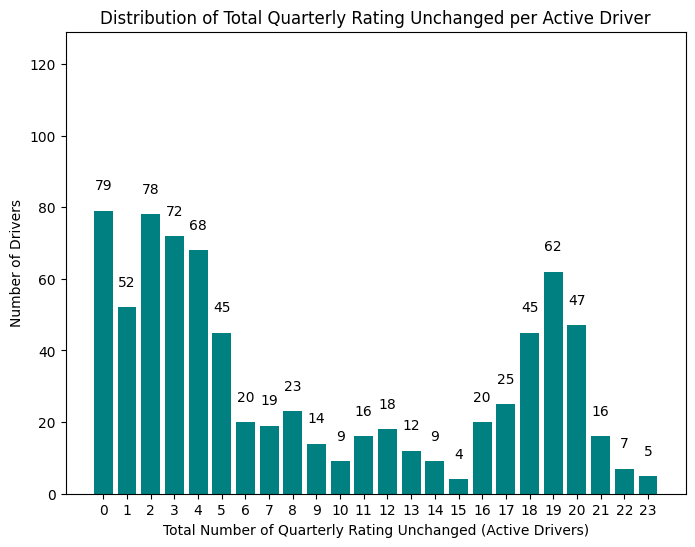

In [ ]:
# Group by the sum of Quarterly_Rating_Unchanged and count the occurrences for active drivers
active_unchanged_counts = active_driver_unchanged_sum.groupBy("sum(Quarterly_Rating_Unchanged)").count().orderBy("sum(Quarterly_Rating_Unchanged)")

# Convert to pandas DataFrame for plotting
active_unchanged_counts_pd = active_unchanged_counts.toPandas()

# Create a bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar(active_unchanged_counts_pd["sum(Quarterly_Rating_Unchanged)"].astype(str), active_unchanged_counts_pd["count"], color='teal')
plt.xlabel('Total Number of Quarterly Rating Unchanged (Active Drivers)')
plt.ylabel('Number of Drivers')
plt.title('Distribution of Total Quarterly Rating Unchanged per Active Driver')

# Add labels to the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.ylim(0, active_unchanged_counts_pd["count"].max() + 50) # Set the upper limit of the y-axis

plt.show()

- Higher number for quarterly unchanged are shown in the initial times per the customer report which is the **2,3 and 4** showing a total collection of **218 drivers** with an **estimated trips of 19000-19320 approx**. with reporting members on **644 reports count**.

- Drivers which are serving more than **1.5 years** from **18 - 20 bracket** which shows a total of **154 drivers** with an estimated trips of **87000 - 87840** approx. with a reporting members count of **2928**.

**No Quarterly Ratings for Left Drivers**

In [ ]:
# Identify left drivers
left_drivers_df = spark.sql("SELECT DISTINCT Driver_ID as Left_members FROM ola_drivers WHERE LastWorkingDate is NOT NULL")

# Rename the 'Left_members' column to 'Driver_ID' for joining
left_drivers_df = left_drivers_df.withColumnRenamed("Left_members", "Driver_ID")

# Join with main dataframe and calculate sum of Quarterly_Rating_Unchanged for left drivers
left_driver_unchanged_sum = spark_df.join(left_drivers_df, "Driver_ID").groupBy("Driver_ID").sum("Quarterly_Rating_Unchanged")
left_driver_unchanged_sum.show()

# Get the count of left drivers with unchanged sum
print("Left Drivers Unchanged Count:")
print(left_driver_unchanged_sum.count())

+---------+-------------------------------+
|Driver_ID|sum(Quarterly_Rating_Unchanged)|
+---------+-------------------------------+
|       29|                              3|
|      474|                              0|
|      964|                              5|
|       65|                             13|
|      418|                             10|
|      541|                             17|
|      558|                             11|
|     1010|                             16|
|     1258|                              4|
|     1277|                              6|
|     1360|                              6|
|      222|                              1|
|      270|                              3|
|      293|                              2|
|      938|                              3|
|      278|                              2|
|      442|                              2|
|      705|                              3|
|     1175|                              9|
|     1202|                     

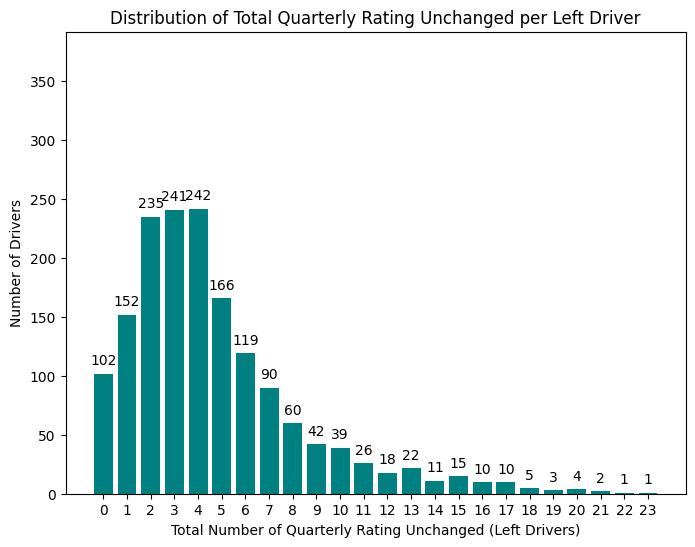

In [ ]:
# Group by the sum of Quarterly_Rating_Unchanged and count the occurrences for left drivers
left_unchanged_counts = left_driver_unchanged_sum.groupBy("sum(Quarterly_Rating_Unchanged)").count().orderBy("sum(Quarterly_Rating_Unchanged)")

# Convert to pandas DataFrame for plotting
left_unchanged_counts_pd = left_unchanged_counts.toPandas()

# Create a bar plot for left drivers
plt.figure(figsize=(8, 6))
bars_left = plt.bar(left_unchanged_counts_pd["sum(Quarterly_Rating_Unchanged)"].astype(str), left_unchanged_counts_pd["count"], color='teal')
plt.xlabel('Total Number of Quarterly Rating Unchanged (Left Drivers)')
plt.ylabel('Number of Drivers')
plt.title('Distribution of Total Quarterly Rating Unchanged per Left Driver')

# Add labels to the bars for left drivers
for bar in bars_left:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.ylim(0, left_unchanged_counts_pd["count"].max() + 150) # Set the upper limit of the y-axis

plt.show()

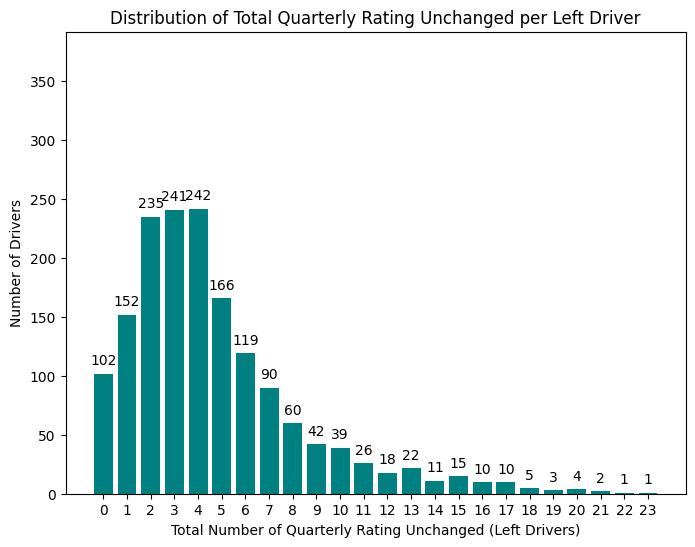

In [ ]:
# Group by the sum of Quarterly_Rating_Unchanged and count the occurrences for left drivers
left_unchanged_counts = left_driver_unchanged_sum.groupBy("sum(Quarterly_Rating_Unchanged)").count().orderBy("sum(Quarterly_Rating_Unchanged)")

# Convert to pandas DataFrame for plotting
left_unchanged_counts_pd = left_unchanged_counts.toPandas()

# Create a bar plot for left drivers
plt.figure(figsize=(8, 6))
bars_left = plt.bar(left_unchanged_counts_pd["sum(Quarterly_Rating_Unchanged)"].astype(str), left_unchanged_counts_pd["count"], color='teal')
plt.xlabel('Total Number of Quarterly Rating Unchanged (Left Drivers)')
plt.ylabel('Number of Drivers')
plt.title('Distribution of Total Quarterly Rating Unchanged per Left Driver')

# Add labels to the bars for left drivers
for bar in bars_left:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.ylim(0, left_unchanged_counts_pd["count"].max() + 150) # Set the upper limit of the y-axis

plt.show()

- Higher chances of drivers leaving as quarterly changes are not shown for the **1-6 months** on report showing an average of **150 people** on each **unchanged period leaving**. The plot shows the **right skewed distribution** where the **sudden decline progresses** from the **6th period** it diminishes to a **negligible number**.

- Drivers are more sensitive to changes from the starting few **5-6 months**.

In [ ]:
spark.sql("SELECT count(distinct Driver_ID) as Total_Unchanged_by_Drivers from ola_drivers where Quarterly_Rating_Unchanged == 1").show()

+--------------------------+
|Total_Unchanged_by_Drivers|
+--------------------------+
|                      2200|
+--------------------------+



In [ ]:
spark.sql("""
    select count(distinct Driver_ID) as Total_drivers_common FROM(SELECT Driver_ID from ola_drivers where Quarterly_Rating_Increased == 1
    INTERSECT
    SELECT Driver_ID from ola_drivers where Quarterly_Rating_Declined == 1)td
""").show()

+--------------------+
|Total_drivers_common|
+--------------------+
|                 615|
+--------------------+



**SALARY INCREMENT**

In [ ]:
from pyspark.sql import Window
from pyspark.sql.functions import lag
from pyspark.sql import SparkSession

# Define a window specification to partition by Driver_ID and order by MMM_YY
windowSpec = Window.partitionBy("Driver_ID").orderBy("MMM_YY")

# Add a new column 'Previous_Income' using the lag function
spark_df = spark_df.withColumn("Previous_Income", lag("Income", 1).over(windowSpec))

# Calculate the income increase
spark_df = spark_df.withColumn("Income_Increase",
                               spark_df["Income"] - spark_df["Previous_Income"])

# Show the updated DataFrame with the new columns
spark_df.show(15)

# Recreate the temporary view to include the new column
spark_df.createOrReplaceTempView("ola_drivers")

+----------+-------------------+---------+----+------+----+---------------+------+-------------------+-------------------+-------------------+-----+--------------------+----------------+-------------------------+--------------------------+-------------------------+--------------------------+---------------+---------------+
|Log_Record|             MMM_YY|Driver_ID| Age|Gender|City|Education_Level|Income|      Dateofjoining|    LastWorkingDate|Joining_Designation|Grade|Total_Business_Value|Quarterly_Rating|Previous_Quarterly_Rating|Quarterly_Rating_Increased|Quarterly_Rating_Declined|Quarterly_Rating_Unchanged|Previous_Income|Income_Increase|
+----------+-------------------+---------+----+------+----+---------------+------+-------------------+-------------------+-------------------+-----+--------------------+----------------+-------------------------+--------------------------+-------------------------+--------------------------+---------------+---------------+
|         0|2019-01-01 00

In [ ]:
spark.sql("""WITH Total_Driver_single AS (
    SELECT
        Driver_ID,
        COUNT(*) as Total_reportings_one
    FROM ola_drivers
    GROUP BY Driver_ID
    HAVING COUNT(*) = 1
)
SELECT
    count(td.Driver_ID) as Total_drivers_single_entry
FROM Total_Driver_single td
INNER JOIN ola_drivers od ON td.Driver_ID = od.Driver_ID
WHERE od.LastWorkingDate is not null;""").show(10)

+--------------------------+
|Total_drivers_single_entry|
+--------------------------+
|                       102|
+--------------------------+



In [ ]:
## Total Salary Increment by Drivers

spark.sql("""
    WITH DriverIncomeSummary AS (
        SELECT
            od.Driver_ID,
            SUM(CASE WHEN od.Income_Increase > 0 THEN 1 ELSE 0 END) as Total_increment_count,
            SUM(CASE WHEN od.Income_Increase = 0 THEN 1 ELSE 0 END) as Total_unchanged_count,
            SUM(CASE WHEN od.Income_Increase < 0 THEN 1 ELSE 0 END) as Total_decreased_count,
            COUNT(*) as Total_reporting_periods
        FROM ola_drivers od
        WHERE od.Income_Increase IS NOT NULL
        GROUP BY od.Driver_ID
    ),
    AggregatedSummary AS (
        SELECT
            SUM(Total_increment_count) as Total_increment_across_all_reports,
            SUM(Total_unchanged_count) as Total_unchanged_across_all_reports,
            SUM(Total_decreased_count) as Total_decreased_across_all_reports,
            SUM(Total_reporting_periods) as Total_reporting_periods_across_all_reports,
            COUNT(CASE WHEN Total_increment_count > 0 THEN Driver_ID ELSE NULL END) as Distinct_Drivers_with_Increment,
            COUNT(CASE WHEN Total_unchanged_count > 0 THEN Driver_ID ELSE NULL END) as Distinct_Drivers_with_Unchanged,
            COUNT(CASE WHEN Total_decreased_count > 0 THEN Driver_ID ELSE NULL END) as Distinct_Drivers_with_Decreased,
            COUNT(DISTINCT Driver_ID) as Total_Distinct_Drivers_with_Change
        FROM DriverIncomeSummary
    )
    SELECT 'Total increment across all reports' as Metric, Total_increment_across_all_reports as Value FROM AggregatedSummary
    UNION ALL
    SELECT 'Total unchanged across all reports' as Metric, Total_unchanged_across_all_reports as Value FROM AggregatedSummary
    UNION ALL
    SELECT 'Total decreased across all reports' as Metric, Total_decreased_across_all_reports as Value FROM AggregatedSummary
    UNION ALL
    SELECT 'Total reporting periods across all reports' as Metric, Total_reporting_periods_across_all_reports as Value FROM AggregatedSummary
    UNION ALL
    SELECT 'Distinct Drivers with Increment' as Metric, Distinct_Drivers_with_Increment as Value FROM AggregatedSummary
    UNION ALL
    SELECT 'Distinct Drivers with Unchanged' as Metric, Distinct_Drivers_with_Unchanged as Value FROM AggregatedSummary
    UNION ALL
    SELECT 'Distinct Drivers with Decreased' as Metric, Distinct_Drivers_with_Decreased as Value FROM AggregatedSummary
    UNION ALL
    SELECT 'Total Distinct Drivers with Change' as Metric, Total_Distinct_Drivers_with_Change as Value FROM AggregatedSummary;
""").show(truncate=False)

+------------------------------------------+-----+
|Metric                                    |Value|
+------------------------------------------+-----+
|Total increment across all reports        |44   |
|Total unchanged across all reports        |16678|
|Total decreased across all reports        |1    |
|Total reporting periods across all reports|16723|
|Distinct Drivers with Increment           |44   |
|Distinct Drivers with Unchanged           |2200 |
|Distinct Drivers with Decreased           |1    |
|Total Distinct Drivers with Change        |2200 |
+------------------------------------------+-----+



In [ ]:
## Income Change Summary for Active Drivers

spark.sql("""
    WITH DriverIncomeSummary AS (
        SELECT
            od.Driver_ID,
            SUM(CASE WHEN od.Income_Increase > 0 THEN 1 ELSE 0 END) as Total_increment_by_driver,
            SUM(CASE WHEN od.Income_Increase = 0 THEN 1 ELSE 0 END) as Total_unchanged_by_driver,
            SUM(CASE WHEN od.Income_Increase < 0 THEN 1 ELSE 0 END) as Total_decreased_by_driver,
            COUNT(*) as Total_reporting_periods
        FROM ola_drivers od
        WHERE od.Income_Increase IS NOT NULL  -- Exclude the first reporting period for each driver
        GROUP BY od.Driver_ID
    ),
    ActiveDrivers AS (
        SELECT DISTINCT Driver_ID FROM ola_drivers WHERE Driver_ID NOT IN (SELECT DISTINCT Driver_ID FROM ola_drivers WHERE LastWorkingDate IS NOT NULL)
    ),
    AggregatedSummary AS (
        SELECT
            SUM(dis.Total_increment_by_driver) as Total_increment_across_all_reports,
            SUM(dis.Total_unchanged_by_driver) as Total_unchanged_across_all_reports,
            SUM(dis.Total_decreased_by_driver) as Total_decreased_across_all_reports,
            SUM(dis.Total_reporting_periods) as Total_reporting_periods_across_all_reports,
            COUNT(CASE WHEN Total_increment_by_driver > 0 THEN dis.Driver_ID ELSE NULL END) as Distinct_Drivers_with_Increment,
            COUNT(CASE WHEN Total_unchanged_by_driver > 0 THEN dis.Driver_ID ELSE NULL END) as Distinct_Drivers_with_Unchanged,
            COUNT(CASE WHEN Total_decreased_by_driver > 0 THEN dis.Driver_ID ELSE NULL END) as Distinct_Drivers_with_Decreased,
            COUNT(DISTINCT dis.Driver_ID) as Total_Distinct_Drivers_with_Change
        FROM DriverIncomeSummary dis
        INNER JOIN ActiveDrivers ad ON dis.Driver_ID = ad.Driver_ID
    )
    SELECT 'Total increment across all reports' as Metric, Total_increment_across_all_reports as Value FROM AggregatedSummary
    UNION ALL
    SELECT 'Total unchanged across all reports' as Metric, Total_unchanged_across_all_reports as Value FROM AggregatedSummary
    UNION ALL
    SELECT 'Total decreased across all reports' as Metric, Total_decreased_across_all_reports as Value FROM AggregatedSummary
    UNION ALL
    SELECT 'Total reporting periods across all reports' as Metric, Total_reporting_periods_across_all_reports as Value FROM AggregatedSummary
    UNION ALL
    SELECT 'Distinct Drivers with Increment' as Metric, Distinct_Drivers_with_Increment as Value FROM AggregatedSummary
    UNION ALL
    SELECT 'Distinct Drivers with Unchanged' as Metric, Distinct_Drivers_with_Unchanged as Value FROM AggregatedSummary
    UNION ALL
    SELECT 'Distinct Drivers with Decreased' as Metric, Distinct_Drivers_with_Decreased as Value FROM AggregatedSummary
    UNION ALL
    SELECT 'Total Distinct Drivers with Change' as Metric, Total_Distinct_Drivers_with_Change as Value FROM AggregatedSummary;
""").show(truncate=False)

+------------------------------------------+-----+
|Metric                                    |Value|
+------------------------------------------+-----+
|Total increment across all reports        |41   |
|Total unchanged across all reports        |7938 |
|Total decreased across all reports        |1    |
|Total reporting periods across all reports|7980 |
|Distinct Drivers with Increment           |41   |
|Distinct Drivers with Unchanged           |686  |
|Distinct Drivers with Decreased           |1    |
|Total Distinct Drivers with Change        |686  |
+------------------------------------------+-----+



In [ ]:
## Income Change Summary for Left Drivers

spark.sql("""
    WITH DriverIncomeSummary AS (
        SELECT
            od.Driver_ID,
            SUM(CASE WHEN od.Income_Increase > 0 THEN 1 ELSE 0 END) as Total_increment_by_driver,
            SUM(CASE WHEN od.Income_Increase = 0 THEN 1 ELSE 0 END) as Total_unchanged_by_driver,
            SUM(CASE WHEN od.Income_Increase < 0 THEN 1 ELSE 0 END) as Total_decreased_by_driver,
            COUNT(*) as Total_reporting_periods
        FROM ola_drivers od
        WHERE od.Income_Increase IS NOT NULL  -- Exclude the first reporting period for each driver
        GROUP BY od.Driver_ID
    ),
    LeftDrivers AS (
        SELECT DISTINCT Driver_ID FROM ola_drivers WHERE LastWorkingDate IS NOT NULL
    ),
    AggregatedSummary AS (
        SELECT
            SUM(dis.Total_increment_by_driver) as Total_increment_across_all_reports,
            SUM(dis.Total_unchanged_by_driver) as Total_unchanged_across_all_reports,
            SUM(dis.Total_decreased_by_driver) as Total_decreased_across_all_reports,
            SUM(dis.Total_reporting_periods) as Total_reporting_periods_across_all_reports,
            COUNT(CASE WHEN Total_increment_by_driver > 0 THEN dis.Driver_ID ELSE NULL END) as Distinct_Drivers_with_Increment,
            COUNT(CASE WHEN Total_unchanged_by_driver > 0 THEN dis.Driver_ID ELSE NULL END) as Distinct_Drivers_with_Unchanged,
            COUNT(CASE WHEN Total_decreased_by_driver > 0 THEN dis.Driver_ID ELSE NULL END) as Distinct_Drivers_with_Decreased,
            COUNT(DISTINCT dis.Driver_ID) as Total_Distinct_Drivers_with_Change
        FROM DriverIncomeSummary dis
        INNER JOIN LeftDrivers ld ON dis.Driver_ID = ld.Driver_ID
    )
    SELECT 'Total increment across all reports' as Metric, Total_increment_across_all_reports as Value FROM AggregatedSummary
    UNION ALL
    SELECT 'Total unchanged across all reports' as Metric, Total_unchanged_across_all_reports as Value FROM AggregatedSummary
    UNION ALL
    SELECT 'Total decreased across all reports' as Metric, Total_decreased_across_all_reports as Value FROM AggregatedSummary
    UNION ALL
    SELECT 'Total reporting periods across all reports' as Metric, Total_reporting_periods_across_all_reports as Value FROM AggregatedSummary
    UNION ALL
    SELECT 'Distinct Drivers with Increment' as Metric, Distinct_Drivers_with_Increment as Value FROM AggregatedSummary
    UNION ALL
    SELECT 'Distinct Drivers with Unchanged' as Metric, Distinct_Drivers_with_Unchanged as Value FROM AggregatedSummary
    UNION ALL
    SELECT 'Distinct Drivers with Decreased' as Metric, Distinct_Drivers_with_Decreased as Value FROM AggregatedSummary
    UNION ALL
    SELECT 'Total Distinct Drivers with Change' as Metric, Total_Distinct_Drivers_with_Change as Value FROM AggregatedSummary;
""").show(truncate=False)

+------------------------------------------+-----+
|Metric                                    |Value|
+------------------------------------------+-----+
|Total increment across all reports        |3    |
|Total unchanged across all reports        |8740 |
|Total decreased across all reports        |0    |
|Total reporting periods across all reports|8743 |
|Distinct Drivers with Increment           |3    |
|Distinct Drivers with Unchanged           |1514 |
|Distinct Drivers with Decreased           |0    |
|Total Distinct Drivers with Change        |1514 |
+------------------------------------------+-----+



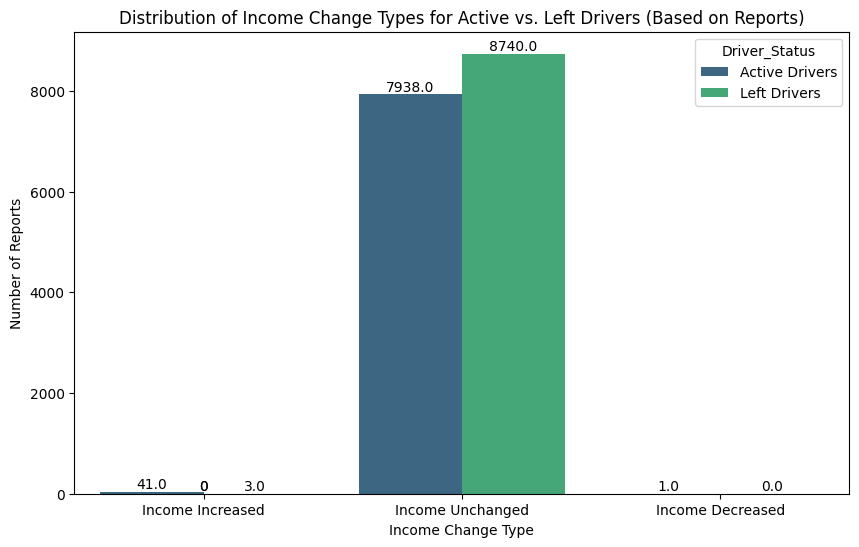

In [ ]:
# Data from previous cells
active_income_summary = {'Driver_Status': 'Active Drivers', 'Total_increment': 41, 'Total_unchanged': 7938, 'Total_decreased': 1, 'Total_reporting_periods': 7980}
left_income_summary = {'Driver_Status': 'Left Drivers', 'Total_increment': 3, 'Total_unchanged': 8740, 'Total_decreased': 0, 'Total_reporting_periods': 8743}

# Create a pandas DataFrame
income_summary_df = pd.DataFrame([active_income_summary, left_income_summary])

# Reshape the DataFrame for plotting
income_summary_melted = income_summary_df.melt(id_vars='Driver_Status',
                                               value_vars=['Total_increment', 'Total_unchanged', 'Total_decreased'],
                                               var_name='Income_Change_Type',
                                               value_name='Count')

# Map Income_Change_Type for better labels
income_summary_melted['Income_Change_Type'] = income_summary_melted['Income_Change_Type'].map({
    'Total_increment': 'Income Increased',
    'Total_unchanged': 'Income Unchanged',
    'Total_decreased': 'Income Decreased'
})

# Create a grouped bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=income_summary_melted, x='Income_Change_Type', y='Count', hue='Driver_Status', palette='viridis')

plt.xlabel('Income Change Type')
plt.ylabel('Number of Reports')
plt.title('Distribution of Income Change Types for Active vs. Left Drivers (Based on Reports)')

# Add count labels to the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

- All of the Drivers have a fixed salary as per the Ola services policy, but only for **1.8%** of the drivers have achieved the increment on their basic salary. Higher possibilities of these achievements are post designation changes, well performing employee showing more responsibility and loyalty towards company's perspective and growth.

- Decrement on salary has only been evident on a single employee which could not draw more conclusion on the behavioural affects making it still more reliable option for customers.

- Drivers involved salary decrement and increment are a huge part of unchanged salary, as mathematically:

$A$ being an salary increment and $B$ being a salary decrement shows that

**$\implies A ⊆ C$ and $B \subseteq C$**

**$\implies A \cup B
\subseteq C$**

Now, we know **$|A \cup B| \leq 45$ and $|C| = 2200$**

The Driver's who could not get any variation in their payscale is given by
**$|C| - |A \cup B| = 2200 - 45 = 2145$** employees or drivers didn't get any **salary variations** in the current phase which is **97.5%** of the drivers where **68.86%** of the drivers left the organisation.


**Relationship between Income and Quanterly Changes**

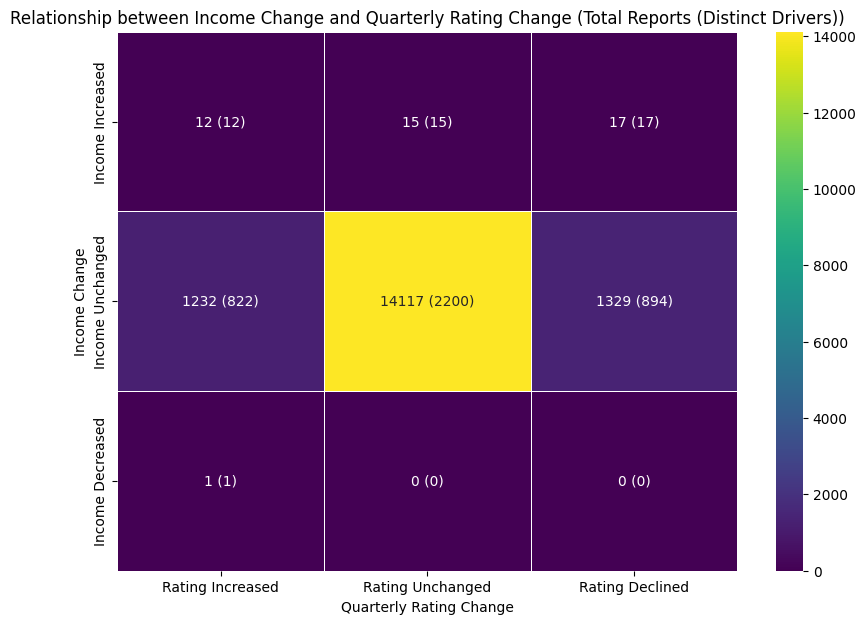

In [ ]:
from pyspark.sql import functions as F

# Filter for rows where Income_Increase is not null (excluding the first report for each driver)
filtered_df = spark_df.filter(spark_df["Income_Increase"].isNotNull())

# Group by Quarterly_Rating_Increased, Quarterly_Rating_Declined, Quarterly_Rating_Unchanged
# and Income_Increase > 0, Income_Increase = 0, Income_Increase < 0 to get counts for each combination
income_quarterly_counts = filtered_df.groupBy(
    F.when(F.col("Income_Increase") > 0, "Income Increased")
     .when(F.col("Income_Increase") < 0, "Income Decreased")
     .otherwise("Income Unchanged").alias("Income_Change"),
    F.when(F.col("Quarterly_Rating_Increased") == 1, "Rating Increased")
     .when(F.col("Quarterly_Rating_Declined") == 1, "Rating Declined")
     .when(F.col("Quarterly_Rating_Unchanged") == 1, "Rating Unchanged")
     .otherwise("No Previous Rating").alias("Quarterly_Rating_Change")
).agg(F.count("*").alias("total_reports"), F.countDistinct("Driver_ID").alias("distinct_drivers")).toPandas()

# Create a combined annotation string for the heatmap
income_quarterly_counts['annotation'] = income_quarterly_counts.apply(lambda row: f"{int(row['total_reports'])} ({int(row['distinct_drivers'])})", axis=1)

# Pivot the data for the heatmap annotations
heatmap_annotations = income_quarterly_counts.pivot(
    index="Income_Change",
    columns="Quarterly_Rating_Change",
    values="annotation"
).fillna("0 (0)")

# Pivot the data for the heatmap values (using total reports for color intensity)
heatmap_values = income_quarterly_counts.pivot(
    index="Income_Change",
    columns="Quarterly_Rating_Change",
    values="total_reports"
).fillna(0)

# Define the desired order for rows and columns
income_order = ["Income Increased", "Income Unchanged", "Income Decreased"]
rating_order = ["Rating Increased", "Rating Unchanged", "Rating Declined"]

# Reindex the heatmap data to the desired order and fill any missing combinations with 0
heatmap_annotations = heatmap_annotations.reindex(index=income_order, columns=rating_order).fillna("0 (0)")
heatmap_values = heatmap_values.reindex(index=income_order, columns=rating_order).fillna(0)

# Create the heatmap using total reports for color and combined annotation
plt.figure(figsize=(10, 7))
sns.heatmap(heatmap_values, annot=heatmap_annotations, fmt='s', cmap='viridis', linewidths=.5)
plt.xlabel('Quarterly Rating Change')
plt.ylabel('Income Change')
plt.title('Relationship between Income Change and Quarterly Rating Change (Total Reports (Distinct Drivers))')
plt.show()

- Total **73.89%** of the data consists of **No changes** made towards the **Income and Quarterly Ratings**.

- There is a **one to one** correspondance towards the Ratings and the salary Increment. Rating changes does not impact on a large scale for salary incremented drivers as Increments are beneficial for the sole driver in order to financially support his daily needs whereas Ratings decline are based on the collective feedback by the customers given.

**AGE GROUPS**

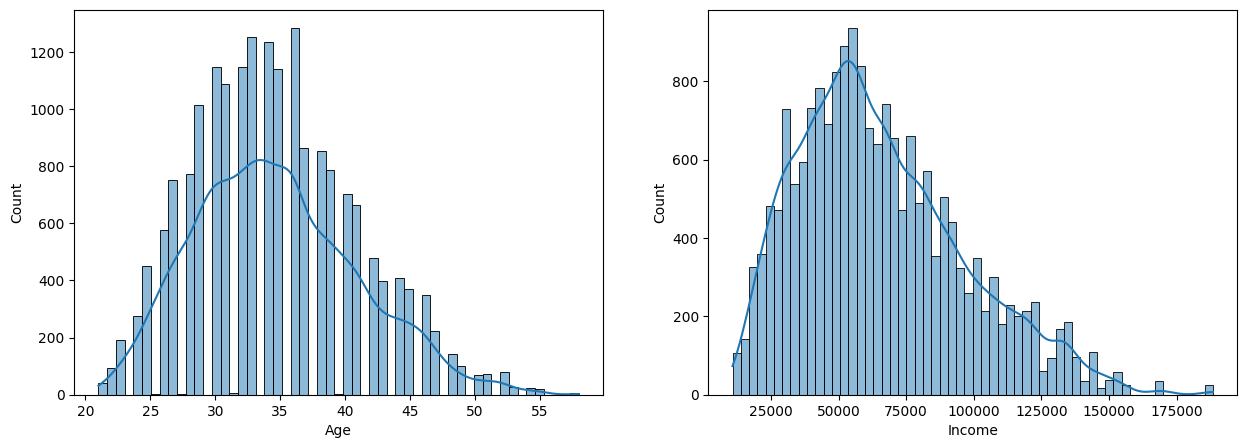

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Convert Spark DataFrame columns to pandas Series for plotting
age_pd = spark_df.select("Age").toPandas()["Age"]
income_pd = spark_df.select("Income").toPandas()["Income"]

sns.histplot(age_pd, kde=True, ax=ax[0])
sns.histplot(income_pd, kde=True, ax=ax[1])

plt.show()

- Since Age and Income are continuous in nature, lets create with Age and Income groups.

In [ ]:
# Define age groups
age_bins = [20, 30, 40, 50, 60]
age_labels = ['20-29', '30-39', '40-49', '50-59']

# Create Age_Group column
spark_df = spark_df.withColumn("Age_Group",
                               when((spark_df["Age"] >= age_bins[0]) & (spark_df["Age"] < age_bins[1]), age_labels[0])
                               .when((spark_df["Age"] >= age_bins[1]) & (spark_df["Age"] < age_bins[2]), age_labels[1])
                               .when((spark_df["Age"] >= age_bins[2]) & (spark_df["Age"] < age_bins[3]), age_labels[2])
                               .when((spark_df["Age"] >= age_bins[3]) & (spark_df["Age"] < age_bins[4]), age_labels[3])
                               .otherwise("60+")) # Handle ages 60 and above


# Define income groups based on min and max values
min_income = 10747
max_income = 188418

# You can define equal-interval bins between min and max income
# For example, 4 equal bins:
income_bins = [min_income, min_income + (max_income - min_income)/4, min_income + 2*(max_income - min_income)/4, min_income + 3*(max_income - min_income)/4, max_income + 1] # Add 1 to include the max value
income_labels = [f'₹{int(income_bins[0])}-₹{int(income_bins[1])-1}',
                 f'₹{int(income_bins[1])}-₹{int(income_bins[2])-1}',
                 f'₹{int(income_bins[2])}-₹{int(income_bins[3])-1}',
                 f'₹{int(income_bins[3])}-₹{int(income_bins[4])-1}']

# Create Income_Group column
spark_df = spark_df.withColumn("Income_Group",
                               when((spark_df["Income"] >= income_bins[0]) & (spark_df["Income"] < income_bins[1]), income_labels[0])
                               .when((spark_df["Income"] >= income_bins[1]) & (spark_df["Income"] < income_bins[2]), income_labels[1])
                               .when((spark_df["Income"] >= income_bins[2]) & (spark_df["Income"] < income_bins[3]), income_labels[2])
                               .when((spark_df["Income"] >= income_bins[3]) & (spark_df["Income"] < income_bins[4]), income_labels[3])
                               .otherwise("Unknown")) # Handle any outliers


# Recreate the temporary view to include the new columns
spark_df.createOrReplaceTempView("ola_drivers")

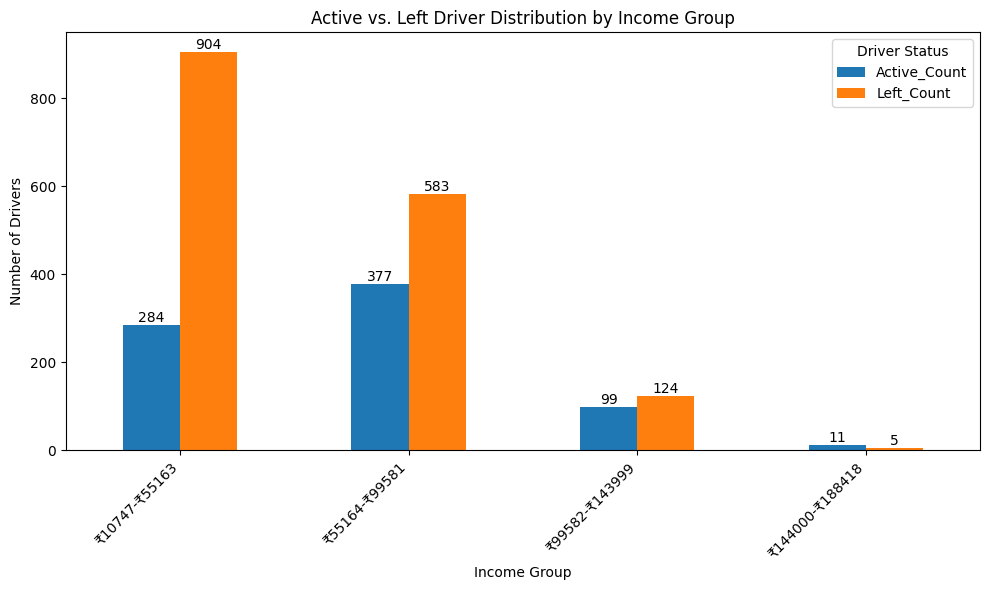

In [ ]:
# Get the count of active drivers per income group
active_income_counts = spark.sql("""
    SELECT Income_Group, COUNT(DISTINCT Driver_ID) as Active_Count
    FROM ola_drivers
    WHERE Driver_ID not in (select Driver_ID from ola_drivers
     where LastWorkingDate is not null)
    GROUP BY Income_Group
""").toPandas()

# Get the count of left drivers per income group
left_income_counts = spark.sql("""
    SELECT Income_Group, COUNT(DISTINCT Driver_ID) as Left_Count
    FROM ola_drivers
    WHERE LastWorkingDate IS NOT NULL
    GROUP BY Income_Group
""").toPandas()

# Merge the two dataframes
income_distribution_df = pd.merge(active_income_counts, left_income_counts, on='Income_Group', how='outer').fillna(0)

# Remove the 'Unknown' income group
income_distribution_df = income_distribution_df[income_distribution_df['Income_Group'] != 'Unknown']

# Set Income_Group as index for plotting and sort by index
income_distribution_df = income_distribution_df.set_index('Income_Group')

# Reorder the index to match the income levels (Low, Medium, High, Very High)
income_distribution_df = income_distribution_df.reindex(['₹10747-₹55163', '₹55164-₹99581', '₹99582-₹143999', '₹144000-₹188418']).fillna(0)


# Create a grouped bar chart
ax = income_distribution_df[['Active_Count', 'Left_Count']].plot(kind='bar', stacked=False, figsize=(10, 6))
plt.xlabel('Income Group')
plt.ylabel('Number of Drivers')
plt.title('Active vs. Left Driver Distribution by Income Group')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Driver Status')
plt.tight_layout()

# Add total count labels on top of the bars
for container in ax.containers:
    for j, v in enumerate(container):
        if v.get_height() > 0:  # Only add label if the bar has height
             ax.text(v.get_x() + v.get_width() / 2.,
                    v.get_y() + v.get_height(),
                    int(v.get_height()),
                    ha='center',
                    va='bottom')

plt.show()

- **Highest attrition rate** from the **Income Group (₹10747 - ₹55163)** resulting to **65.72%** of the workforce have been forced to leave as the introduction of new substitutes which could make their life's much more better.

- **Higher gaps** are widened as the Income groups are for a minimal wage amount that will insufficient for the Drivers to balance their life choices as high work pressure **demanding lower remuneration and additional paying** which is not an ideal choice for the worker as growth on experience without the pay on salary would lead the worker to chose other company over this.

- Only **0.2% of the workforce** have been into a **highly pay scale** of work where **retention scale is above 50%**.

- Total of **44 Drivers** have got a **increment** from their **original salary** pay scale, Change in the Income Group have been reflected for over **6 employees** which have positively make them retain within the organisation.

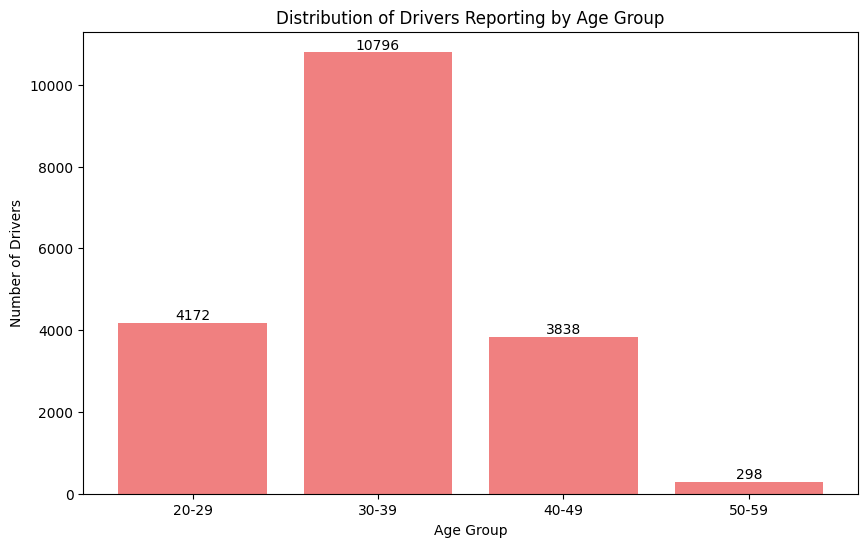

In [ ]:
# Get the count of drivers in each age group
age_group_counts = spark.sql("SELECT Age_Group, COUNT(*) as count FROM ola_drivers GROUP BY Age_Group ORDER BY Age_Group").toPandas()

# Create a bar plot for age group distribution
plt.figure(figsize=(10, 6))
bars = plt.bar(age_group_counts['Age_Group'], age_group_counts['count'], color='lightcoral')
plt.xlabel('Age Group')
plt.ylabel('Number of Drivers')
plt.title('Distribution of Drivers Reporting by Age Group')

# Add labels to the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.ylim(0, age_group_counts['count'].max() + 500) # Set the upper limit of the y-axis for better visualization
plt.show()

- Maximum number of reporting done per driver are 56.51% for 30 - 39.

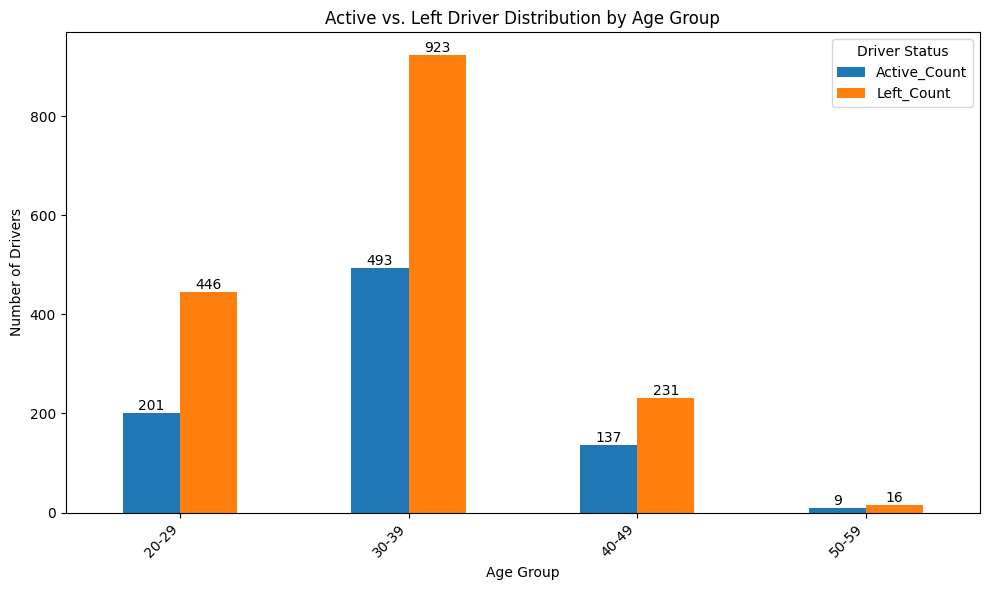

In [ ]:
# Get the count of active drivers per age group
active_age_counts = spark.sql("""
    SELECT Age_Group, COUNT(DISTINCT Driver_ID) as Active_Count
    FROM ola_drivers
    WHERE Driver_ID not in (select Driver_ID from ola_drivers
     where LastWorkingDate is not null)
    GROUP BY Age_Group
""").toPandas()

# Get the count of left drivers per age group
left_age_counts = spark.sql("""
    SELECT Age_Group, COUNT(DISTINCT Driver_ID) as Left_Count
    FROM ola_drivers
    WHERE LastWorkingDate IS NOT NULL
    GROUP BY Age_Group
""").toPandas()

# Merge the two dataframes
age_distribution_df = pd.merge(active_age_counts, left_age_counts, on='Age_Group', how='outer').fillna(0)

# Set Age_Group as index for plotting and sort by index
age_distribution_df = age_distribution_df.set_index('Age_Group')

# Reorder the index to match the age groups
age_distribution_df = age_distribution_df.reindex(['20-29', '30-39', '40-49', '50-59']).fillna(0)

# Create a grouped bar chart
ax = age_distribution_df[['Active_Count', 'Left_Count']].plot(kind='bar', stacked=False, figsize=(10, 6))
plt.xlabel('Age Group')
plt.ylabel('Number of Drivers')
plt.title('Active vs. Left Driver Distribution by Age Group')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Driver Status')
plt.tight_layout()

# Add total count labels on top of the bars
for container in ax.containers:
    for j, v in enumerate(container):
        if v.get_height() > 0:  # Only add label if the bar has height
             ax.text(v.get_x() + v.get_width() / 2.,
                    v.get_y() + v.get_height(),
                    int(v.get_height()),
                    ha='center',
                    va='bottom')

plt.show()

- **More number of Attrition rate** and **Retention rate** is among the **30 - 39** which are the **middle aged drivers**. At this point of time, higher chances of leaving the organisation could be at a more higher pace as **experience gain and transiting to a new environment is higher within the society** as most of these **drivers have their obligations and duties to be equally higher priority to the worklife balance** that each driver would possess on a long run. And **growth gaining** would be an **optimal area** on **shifting their life choices**.

- The **Attrition rates** are **more than 50%** of the workforce for **20 - 29 and 30 - 39**.

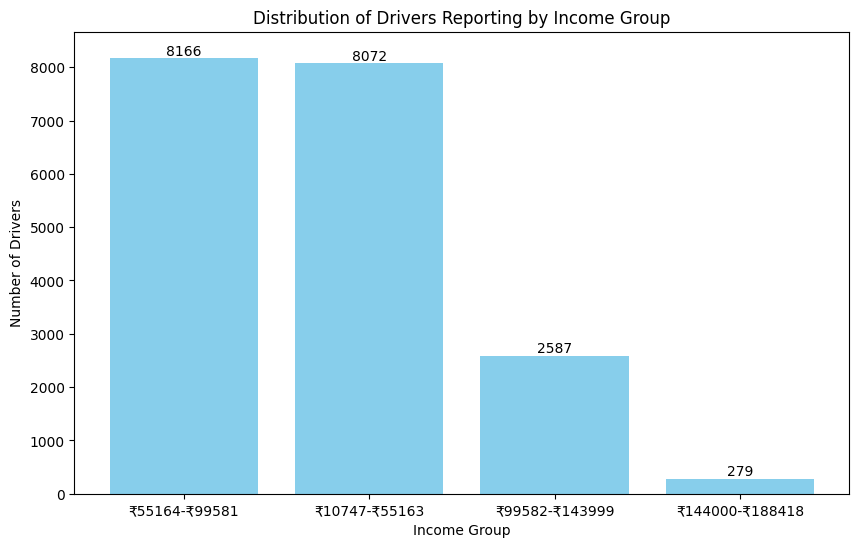

In [ ]:
# Get the count of drivers in each income group
income_group_counts = spark.sql("SELECT Income_Group, COUNT(*) as count FROM ola_drivers GROUP BY Income_Group ORDER BY count(*) desc").toPandas()

# Create a bar plot for income group distribution
plt.figure(figsize=(10, 6))
bars = plt.bar(income_group_counts['Income_Group'], income_group_counts['count'], color='skyblue')
plt.xlabel('Income Group')
plt.ylabel('Number of Drivers')
plt.title('Distribution of Drivers Reporting by Income Group')

# Add labels to the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.ylim(0, income_group_counts['count'].max() + 500) # Set the upper limit of the y-axis for better visualization
plt.show()

In [ ]:
from pyspark.sql import Window
from pyspark.sql.functions import lag, when

# Define a window specification to partition by Driver_ID and order by MMM_YY
windowSpec = Window.partitionBy("Driver_ID").orderBy("MMM_YY")

# Add a new column 'Previous_Age' using the lag function
spark_df = spark_df.withColumn("Previous_Age", lag("Age", 1).over(windowSpec))

# Determine if the age has increased
spark_df = spark_df.withColumn("Age_Increase",
                               when(spark_df["Age"] > spark_df["Previous_Age"], 1)
                               .otherwise(0))

# Show the updated DataFrame with the new columns
spark_df.show(5)

# Recreate the temporary view to include the new column
spark_df.createOrReplaceTempView("ola_drivers")

+----------+-------------------+---------+----+------+----+---------------+------+-------------------+-------------------+-------------------+-----+--------------------+----------------+-------------------------+--------------------------+-------------------------+--------------------------+---------------+---------------+---------+-------------+------------+------------+
|Log_Record|             MMM_YY|Driver_ID| Age|Gender|City|Education_Level|Income|      Dateofjoining|    LastWorkingDate|Joining_Designation|Grade|Total_Business_Value|Quarterly_Rating|Previous_Quarterly_Rating|Quarterly_Rating_Increased|Quarterly_Rating_Declined|Quarterly_Rating_Unchanged|Previous_Income|Income_Increase|Age_Group| Income_Group|Previous_Age|Age_Increase|
+----------+-------------------+---------+----+------+----+---------------+------+-------------------+-------------------+-------------------+-----+--------------------+----------------+-------------------------+--------------------------+-----------

In [ ]:
from pyspark.sql.functions import desc

# Group by Driver_ID and sum the Age_Increase column
driver_age_increase_sum = spark_df.groupBy("Driver_ID").sum("Age_Increase").filter("sum(Age_Increase) > 0").orderBy(desc("sum(Age_Increase)"))

# Show the result
driver_age_increase_sum.show(5)

+---------+-----------------+
|Driver_ID|sum(Age_Increase)|
+---------+-----------------+
|      422|                3|
|     1072|                3|
|      560|                3|
|      901|                3|
|     1050|                3|
+---------+-----------------+
only showing top 5 rows



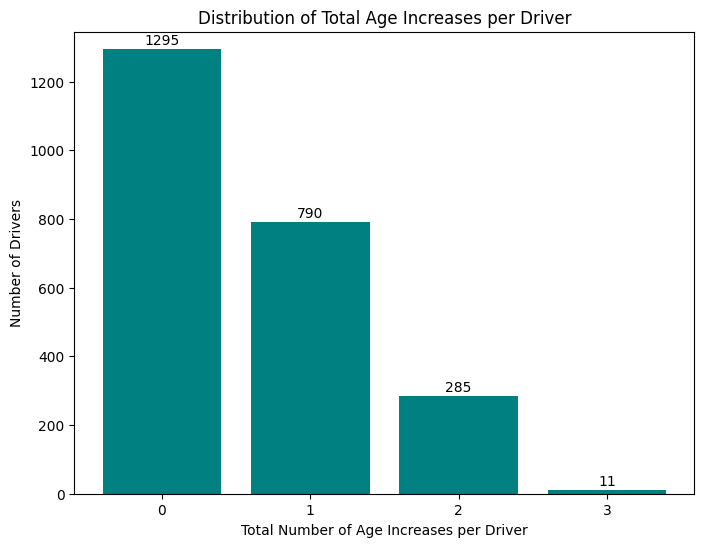

In [ ]:
# Group by the sum of Age_Increase and count the occurrences
age_increase_counts = spark_df.groupBy("Driver_ID").sum("Age_Increase").groupBy("sum(Age_Increase)").count().orderBy("sum(Age_Increase)")

# Convert to pandas DataFrame for plotting
age_increase_counts_pd = age_increase_counts.toPandas()

# Create a bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar(age_increase_counts_pd["sum(Age_Increase)"].astype(str), age_increase_counts_pd["count"], color='teal')
plt.xlabel('Total Number of Age Increases per Driver')
plt.ylabel('Number of Drivers')
plt.title('Distribution of Total Age Increases per Driver')

# Add labels to the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.ylim(0, age_increase_counts_pd["count"].max() + 50) # Set the upper limit of the y-axis

plt.show()

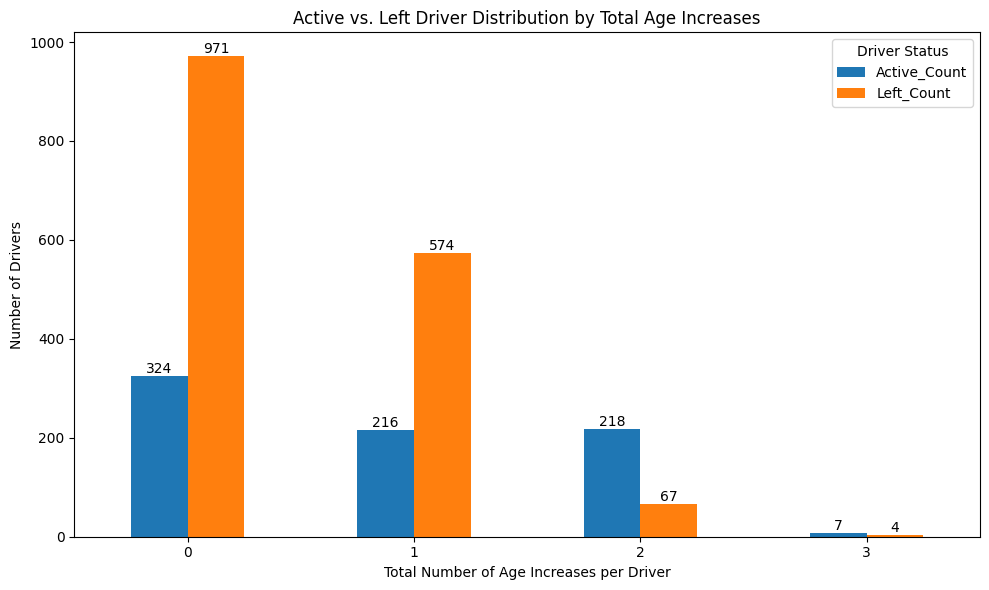

In [ ]:
# Get the count of active drivers per total age increase count
active_age_increase_counts = spark_df.groupBy("Driver_ID").sum("Age_Increase").withColumnRenamed("sum(Age_Increase)", "Total_Age_Increase") \
                                   .join(spark.sql("SELECT DISTINCT Driver_ID FROM ola_drivers WHERE Driver_ID not in(select Driver_ID from ola_drivers where LastWorkingDate is not null)"), "Driver_ID") \
                                   .groupBy("Total_Age_Increase").count().withColumnRenamed("count", "Active_Count").toPandas()

# Get the count of left drivers per total age increase count
left_age_increase_counts = spark_df.groupBy("Driver_ID").sum("Age_Increase").withColumnRenamed("sum(Age_Increase)", "Total_Age_Increase") \
                                 .join(spark.sql("SELECT DISTINCT Driver_ID FROM ola_drivers WHERE LastWorkingDate IS NOT NULL"), "Driver_ID") \
                                 .groupBy("Total_Age_Increase").count().withColumnRenamed("count", "Left_Count").toPandas()

# Merge the two dataframes
age_increase_distribution_df = pd.merge(active_age_increase_counts, left_age_increase_counts, on='Total_Age_Increase', how='outer').fillna(0)

# Set Total_Age_Increase as index for plotting and sort by index
age_increase_distribution_df = age_increase_distribution_df.set_index('Total_Age_Increase').sort_index()

# Create a grouped bar chart
ax = age_increase_distribution_df[['Active_Count', 'Left_Count']].plot(kind='bar', stacked=False, figsize=(10, 6))
plt.xlabel('Total Number of Age Increases per Driver')
plt.ylabel('Number of Drivers')
plt.title('Active vs. Left Driver Distribution by Total Age Increases')
plt.xticks(rotation=0)
plt.legend(title='Driver Status')
plt.tight_layout()

# Add total count labels on top of the bars
for container in ax.containers:
    for j, v in enumerate(container):
        if v.get_height() > 0:  # Only add label if the bar has height
             ax.text(v.get_x() + v.get_width() / 2.,
                    v.get_y() + v.get_height(),
                    int(v.get_height()),
                    ha='center',
                    va='bottom')

plt.show()

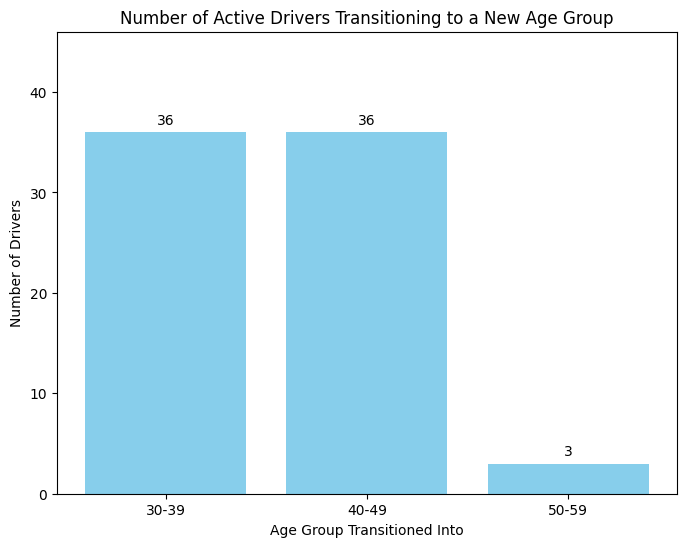

In [ ]:
# Execute the SQL query and convert the result to a pandas DataFrame
age_group_transition_counts_df = spark.sql("""With AgeGroup2 As(SELECT Driver_ID, COUNT(DISTINCT Age_Group) as Driver_Count
 FROM ola_drivers
 where Driver_ID not in (select Driver_ID from ola_drivers where LastWorkingDate is not null)
 GROUP BY Driver_ID
 having Driver_Count > 1)
 select Age_Group, count(*) as Top_Age_groups from(select ag.Driver_ID as Drivers, od.Age_Group,
 dense_rank() over (partition by ag.Driver_ID order by od.Age_Group asc) as rnk from AgeGroup2 ag
 inner join ola_drivers od on od.Driver_ID = ag.Driver_ID
 group by ag.Driver_ID, od.Age_Group)td
 where rnk = 2
 GROUP BY Age_Group
 """).toPandas()

# Create a bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar(age_group_transition_counts_df['Age_Group'], age_group_transition_counts_df['Top_Age_groups'], color='skyblue')
plt.xlabel('Age Group Transitioned Into')
plt.ylabel('Number of Drivers')
plt.title('Number of Active Drivers Transitioning to a New Age Group')

# Add labels to the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom')

plt.ylim(0, age_group_transition_counts_df['Top_Age_groups'].max() + 10) # Set the upper limit of the y-axis for better visualization
plt.show()

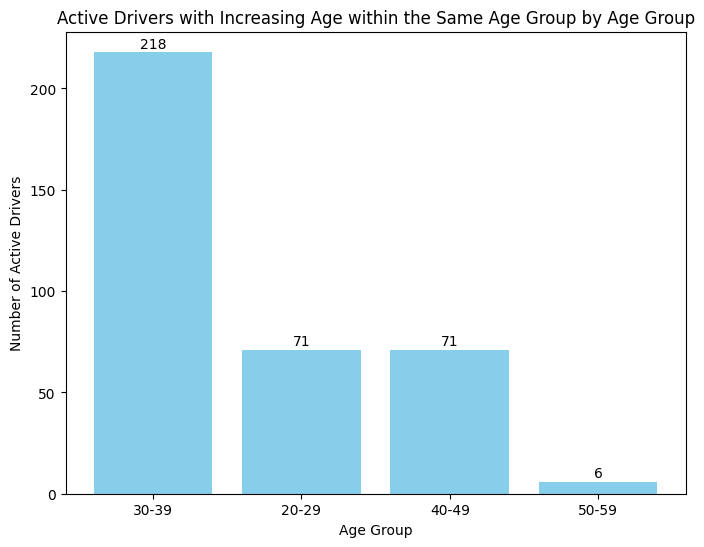

In [ ]:
age_group_inclusive_counts_df = spark.sql("""
WITH AgeGroupInclusive AS (
    SELECT
        Driver_ID,
        COUNT(DISTINCT Age) as Increasing_Age_Count
    FROM ola_drivers
    WHERE Driver_ID NOT IN (
        SELECT Driver_ID
        FROM ola_drivers
        WHERE LastWorkingDate IS NOT NULL
    )
    GROUP BY Driver_ID
    HAVING COUNT(DISTINCT Age) > 1 AND COUNT(DISTINCT Age_group) = 1
)
SELECT
    od.Age_group,
    COUNT(distinct ag.Driver_ID) as Total_Active_Drivers_Inclusive_Range
FROM AgeGroupInclusive ag
INNER JOIN ola_drivers od ON od.Driver_ID = ag.Driver_ID
GROUP BY od.Age_group
""").toPandas()

# Create a bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar(age_group_inclusive_counts_df['Age_group'], age_group_inclusive_counts_df['Total_Active_Drivers_Inclusive_Range'], color='skyblue')
plt.xlabel('Age Group')
plt.ylabel('Number of Active Drivers')
plt.title('Active Drivers with Increasing Age within the Same Age Group by Age Group')

# Add labels to the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom')

plt.ylim(0, age_group_inclusive_counts_df['Total_Active_Drivers_Inclusive_Range'].max() + 10) # Set the upper limit of the y-axis for better visualization
plt.show()

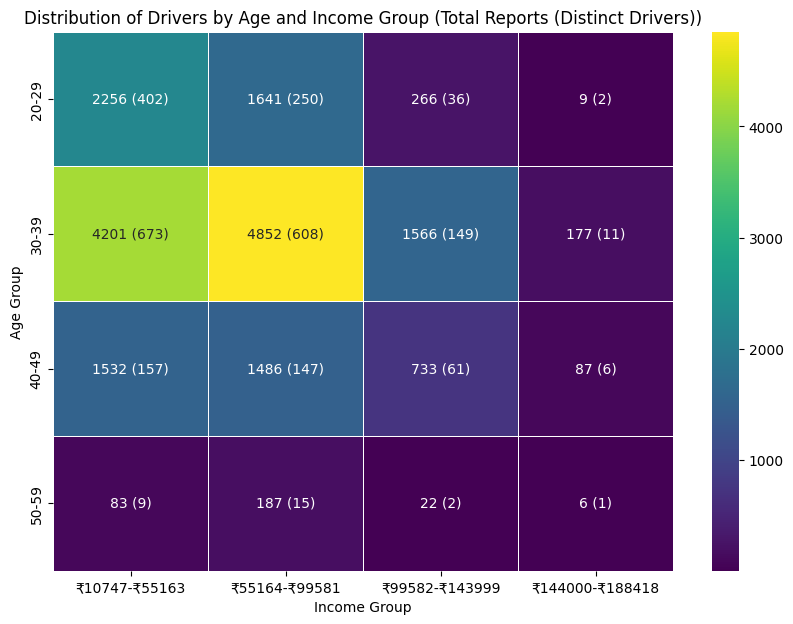

In [ ]:
# Get the count of drivers in each Age Group and Income Group combination
age_income_counts = spark.sql("""
    SELECT Age_Group, Income_Group, COUNT(*) as total_reports, COUNT(DISTINCT Driver_ID) as distinct_drivers
    FROM ola_drivers
    GROUP BY Age_Group, Income_Group
    ORDER BY Age_Group, Income_Group
""").toPandas()

# Create a combined annotation string for the heatmap
age_income_counts['annotation'] = age_income_counts.apply(lambda row: f"{int(row['total_reports'])} ({int(row['distinct_drivers'])})", axis=1)

# Pivot the data for the heatmap annotations
heatmap_annotations = age_income_counts.pivot(index='Age_Group', columns='Income_Group', values='annotation').fillna("0 (0)")

# Pivot the data for the heatmap values (using total reports for color intensity)
heatmap_values = age_income_counts.pivot(index='Age_Group', columns='Income_Group', values='total_reports').fillna(0)


# Reorder the columns and rows to match the desired order
age_order = ['20-29', '30-39', '40-49', '50-59']
income_order = ['₹10747-₹55163', '₹55164-₹99581', '₹99582-₹143999', '₹144000-₹188418']

heatmap_annotations = heatmap_annotations.reindex(index=age_order, columns=income_order).fillna("0 (0)")
heatmap_values = heatmap_values.reindex(index=age_order, columns=income_order).fillna(0)

# Create the heatmap using total reports for color and combined annotation
plt.figure(figsize=(10, 7))
sns.heatmap(heatmap_values, annot=heatmap_annotations, fmt='s', cmap='viridis', linewidths=.5)
plt.xlabel('Income Group')
plt.ylabel('Age Group')
plt.title('Distribution of Drivers by Age and Income Group (Total Reports (Distinct Drivers))')
plt.show()

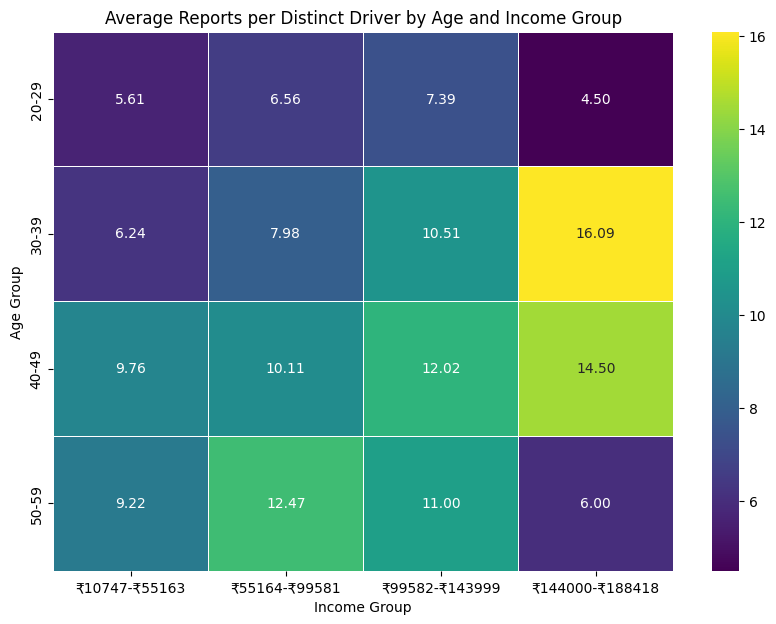

In [ ]:
# Get the count of drivers in each Age Group and Income Group combination and calculate average reports per driver
age_income_counts = spark.sql("""
    SELECT
        Age_Group,
        Income_Group,
        COUNT(*) as total_reports,
        COUNT(DISTINCT Driver_ID) as distinct_drivers,
        ROUND(COUNT(*) / COUNT(DISTINCT Driver_ID), 2) as avg_reports_per_driver
    FROM ola_drivers
    GROUP BY Age_Group, Income_Group
    ORDER BY Age_Group, Income_Group
""").toPandas()

# Pivot the data for the heatmap values and annotations (using average reports per driver)
heatmap_data = age_income_counts.pivot(index='Age_Group', columns='Income_Group', values='avg_reports_per_driver').fillna(0)

# Reorder the columns and rows to match the desired order
age_order = ['20-29', '30-39', '40-49', '50-59']
income_order = ['₹10747-₹55163', '₹55164-₹99581', '₹99582-₹143999', '₹144000-₹188418']

heatmap_data = heatmap_data.reindex(index=age_order, columns=income_order).fillna(0)

# Create the heatmap using average reports per driver for color and annotation
plt.figure(figsize=(10, 7))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='viridis', linewidths=.5)
plt.xlabel('Income Group')
plt.ylabel('Age Group')
plt.title('Average Reports per Distinct Driver by Age and Income Group')
plt.show()

- **Age groups (30 - 39)** and **(40 - 49)** show high level of commitment on working for the company giving a moderate retention rates within these age groups as higher amount reciprocates to the more work being taken contributing to a higher company knowledge base.

 Time dedication frame for age group **(30 - 39)** is **180 - 480 days.**
 **(6 months - 15 months)**

**JOINING DESIGNATION AND PROMOTIONAL GRADES**

In [ ]:
spark.sql("""select Joining_Designation, count(distinct driver_id) as Total_drivers_per_joining_post from ola_drivers
group by Joining_Designation
order by Joining_Designation asc""").show()

+-------------------+------------------------------+
|Joining_Designation|Total_drivers_per_joining_post|
+-------------------+------------------------------+
|                  1|                          1026|
|                  2|                           815|
|                  3|                           493|
|                  4|                            36|
|                  5|                            11|
+-------------------+------------------------------+



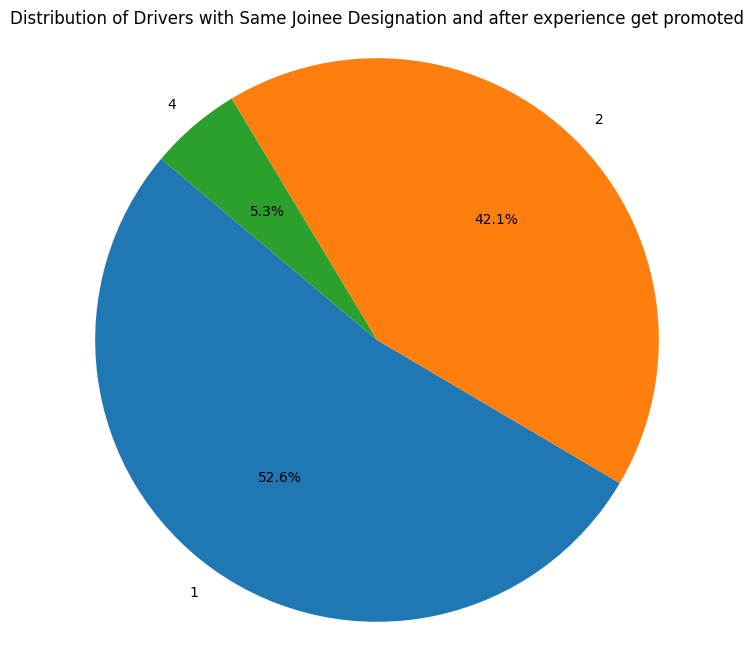

In [ ]:
from pyspark.sql.functions import collect_set, size, datediff, min, max, array_sort, col, year, concat_ws, sort_array

same_grade_post_counts_df = spark.sql("""
SELECT
    td2.Same_grade_post,
    count(*) as Total_Same_grade_post
FROM (
    SELECT
        Driver_ID,
        COLLECT_SET(Joining_Designation) as Distinct_Joining_Designations,
        COLLECT_SET(Grade) as Distinct_Grades,
        SIZE(COLLECT_SET(Grade)) as Count_Distinct_Grades,
        -- Check if first element of both arrays are the same
        CASE
            WHEN ARRAY_SORT(COLLECT_SET(Joining_Designation))[0] = ARRAY_SORT(COLLECT_SET(Grade))[0] THEN ARRAY_SORT(COLLECT_SET(Joining_Designation))[0]
            ELSE 'No'
        END as Same_grade_post
    FROM ola_drivers
    GROUP BY Driver_ID
    HAVING SIZE(COLLECT_SET(Grade)) > 1
) td2
WHERE td2.Same_grade_post != 'No'
GROUP BY td2.Same_grade_post
ORDER BY td2.Same_grade_post
""").toPandas()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(same_grade_post_counts_df['Total_Same_grade_post'], labels=same_grade_post_counts_df['Same_grade_post'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Drivers with Same Joinee Designation and after experience get promoted')
plt.axis('equal')
plt.show()

In [ ]:
## Grade Basis Hikes

spark.sql("""
SELECT
    td2.Same_grade_post,
    td2.Distinct_Grades ,
    count(*) as Total_Same_grade_post
FROM (
    SELECT
        Driver_ID,
        MIN(DateOfJoining) as First_Join_Date,
        MAX(LastWorkingDate) as Last_Date,
        DATEDIFF(MAX(LastWorkingDate), MIN(DateOfJoining)) as Total_Duration_Days,
        COLLECT_SET(Joining_Designation) as Distinct_Joining_Designations,
        COLLECT_SET(Grade) as Distinct_Grades,
        SIZE(COLLECT_SET(Grade)) as Count_Distinct_Grades,
        COUNT(*) as Total_Records,
        -- Check if first element of both arrays are the same
        CASE
            WHEN ARRAY_SORT(COLLECT_SET(Joining_Designation))[0] != ARRAY_SORT(COLLECT_SET(Grade))[0] THEN ARRAY_SORT(COLLECT_SET(Joining_Designation))[0]
            ELSE 'No'
        END as Same_grade_post
    FROM ola_drivers
    GROUP BY Driver_ID
    HAVING SIZE(COLLECT_SET(Grade)) > 1
) td2
WHERE td2.Same_grade_post != 'No'
GROUP BY td2.Same_grade_post, td2.Distinct_Grades
ORDER BY td2.Same_grade_post asc, Total_Same_grade_post desc
""").show(truncate=False)

+---------------+---------------+---------------------+
|Same_grade_post|Distinct_Grades|Total_Same_grade_post|
+---------------+---------------+---------------------+
|1              |[2, 3]         |14                   |
|1              |[3, 4]         |7                    |
|1              |[5, 4]         |1                    |
|2              |[3, 4]         |2                    |
|2              |[5, 4]         |1                    |
+---------------+---------------+---------------------+



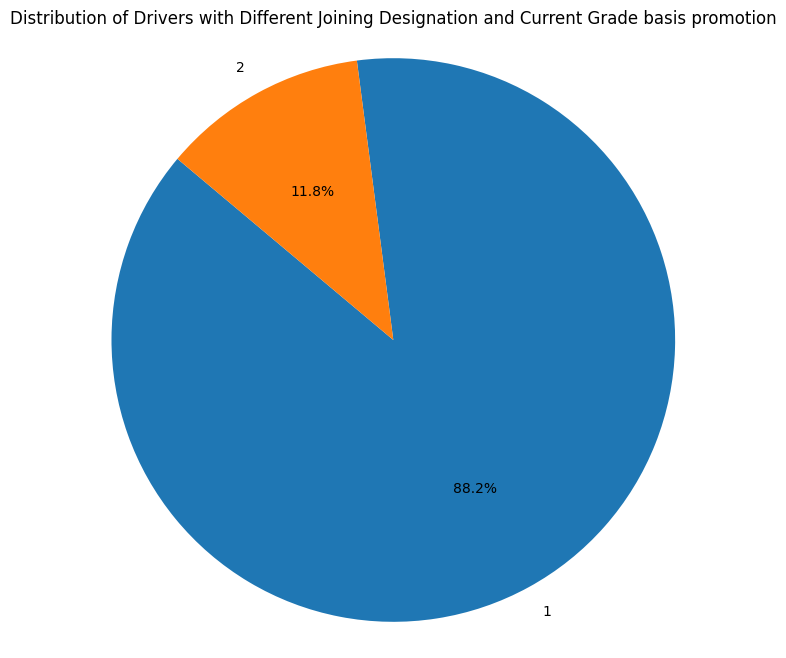

In [ ]:
same_grade_post_distribution_df = spark.sql("""
SELECT
    td2.Same_grade_post,
    sum(td2.Total_Same_grade_post) as Total_Same_grade_post_Sum
FROM (
    SELECT
        Driver_ID,
        COUNT(*) as Total_Records,
        -- Check if first element of both arrays are the same
        CASE
            WHEN ARRAY_SORT(COLLECT_SET(Joining_Designation))[0] != ARRAY_SORT(COLLECT_SET(Grade))[0] THEN ARRAY_SORT(COLLECT_SET(Joining_Designation))[0]
            ELSE 'No'
        END as Same_grade_post,
        count(*) as Total_Same_grade_post
    FROM ola_drivers
    GROUP BY Driver_ID
    HAVING SIZE(COLLECT_SET(Grade)) > 1
) td2
WHERE td2.Same_grade_post != 'No'
GROUP BY td2.Same_grade_post
ORDER BY td2.Same_grade_post
""").toPandas()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(same_grade_post_distribution_df['Total_Same_grade_post_Sum'], labels=same_grade_post_distribution_df['Same_grade_post'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Drivers with Different Joining Designation and Current Grade basis promotion')
plt.axis('equal')
plt.show()

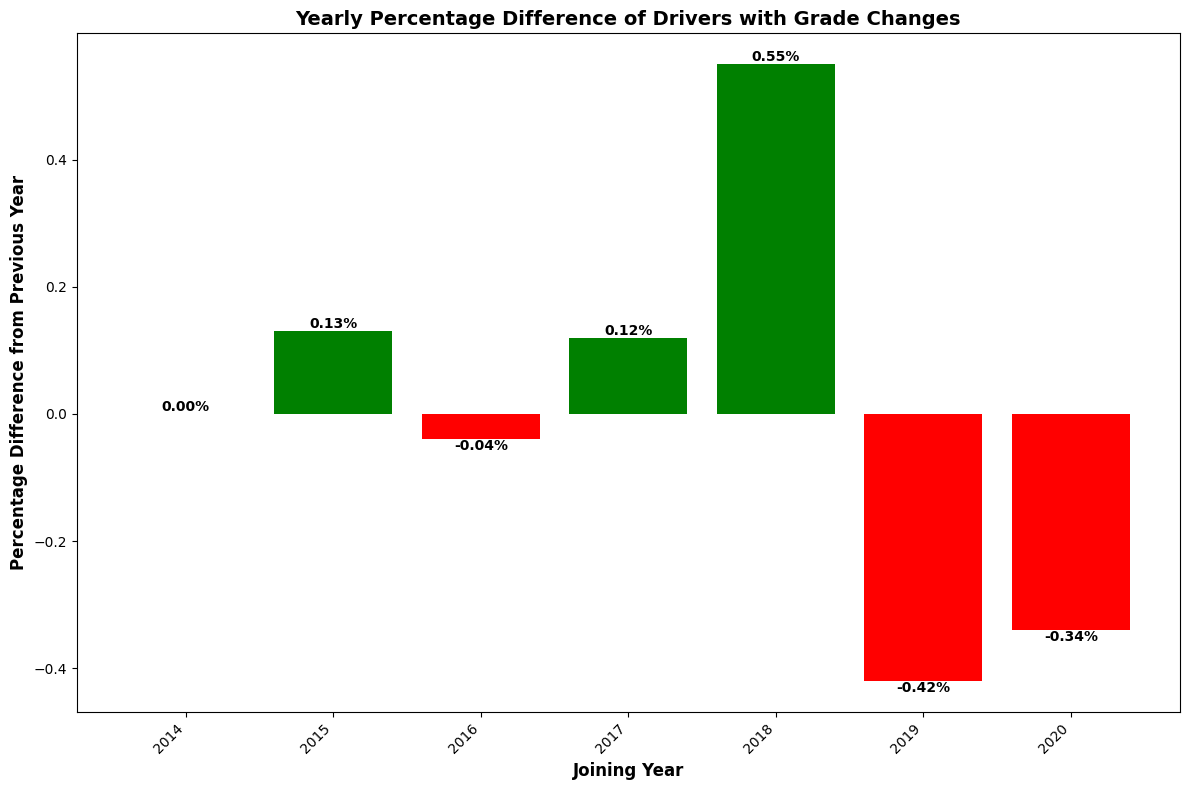


TABLE: DRIVERS WITH GRADE CHANGES BY JOINING YEAR
Join Year    Total Drivers   % of Total   % Difference   
--------------------------------------------------------------------------------
2013         1               0.04         N/A (First Year)
2014         1               0.04         0.00%          
2015         4               0.17         0.13%          
2016         3               0.13         -0.04%         
2017         6               0.25         0.12%          
2018         19              0.80         0.55%          
2019         9               0.38         -0.42%         
2020         1               0.04         -0.34%         
--------------------------------------------------------------------------------
OVERALL TOTAL 2381            100.00%                     

SUMMARY STATISTICS:
• Total years analyzed: 8
• Total drivers with grade changes: 44
• Overall total drivers in dataset: 2,381
• Percentage of all drivers with grade changes: 1.85%
• Average drivers with 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Execute the SQL query and convert to pandas DataFrame
percentage_difference_df = spark.sql("""
WITH YearlyCounts AS (
    SELECT
        YEAR(First_Join_Date) as Join_Year,
        count(*) as Total_Drivers
    FROM (
        SELECT
            Driver_ID,
            MIN(DateOfJoining) as First_Join_Date,
            MAX(LastWorkingDate) as Last_Date,
            DATEDIFF(MAX(LastWorkingDate), MIN(DateOfJoining)) as Total_Duration_Days,
            COLLECT_SET(Joining_Designation) as Distinct_Joining_Designations,
            COLLECT_SET(Grade) as Distinct_Grades,
            SIZE(COLLECT_SET(Grade)) as Count_Distinct_Grades,
            COUNT(*) as Total_Records
        FROM ola_drivers
        GROUP BY Driver_ID
        HAVING SIZE(COLLECT_SET(Grade)) > 1
    ) td
    GROUP BY YEAR(First_Join_Date)
),
TotalDriversOverall AS (
    SELECT count(distinct Driver_ID) as OverallTotalDrivers
    FROM ola_drivers
)
SELECT
    yc.Join_Year,
    yc.Total_Drivers,
    ROUND((yc.Total_Drivers * 100.0 / tdo.OverallTotalDrivers), 2) as Percentage_of_Total_Drivers,
    LAG(ROUND((yc.Total_Drivers * 100.0 / tdo.OverallTotalDrivers), 2), 1) OVER (ORDER BY yc.Join_Year) as Lagged_Percentage_of_Total_Drivers,
    ROUND((yc.Total_Drivers * 100.0 / tdo.OverallTotalDrivers), 2) - LAG(ROUND((yc.Total_Drivers * 100.0 / tdo.OverallTotalDrivers), 2), 1) OVER (ORDER BY yc.Join_Year) as Percentage_Difference
FROM YearlyCounts yc
CROSS JOIN TotalDriversOverall tdo
ORDER BY yc.Join_Year asc
""").toPandas()

# Get overall total drivers for the table
overall_total_drivers = spark.sql("SELECT count(distinct Driver_ID) as OverallTotalDrivers FROM ola_drivers").collect()[0]['OverallTotalDrivers']

# Drop the first row as it will have a NULL Percentage_Difference
percentage_difference_df_clean = percentage_difference_df.dropna(subset=['Percentage_Difference'])

# Define colors based on the sign of the Percentage_Difference
colors = ['green' if diff >= 0 else 'red' for diff in percentage_difference_df_clean['Percentage_Difference']]

# Create a bar chart
plt.figure(figsize=(12, 8))
bars = plt.bar(percentage_difference_df_clean['Join_Year'].astype(str),
               percentage_difference_df_clean['Percentage_Difference'],
               color=colors)

plt.xlabel('Joining Year', fontsize=12, fontweight='bold')
plt.ylabel('Percentage Difference from Previous Year', fontsize=12, fontweight='bold')
plt.title('Yearly Percentage Difference of Drivers with Grade Changes', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Add labels to the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}%',
             ha='center', va='bottom' if yval >= 0 else 'top',
             fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Display the table of total drivers
print("\n" + "="*80)
print("TABLE: DRIVERS WITH GRADE CHANGES BY JOINING YEAR")
print("="*80)
print(f"{'Join Year':<12} {'Total Drivers':<15} {'% of Total':<12} {'% Difference':<15}")
print("-"*80)

# Display all years including the first one (which doesn't have percentage difference)
for _, row in percentage_difference_df.iterrows():
    join_year = str(int(row['Join_Year']))
    total_drivers = int(row['Total_Drivers'])
    pct_total = row['Percentage_of_Total_Drivers']

    if pd.isna(row['Percentage_Difference']):
        pct_diff = "N/A (First Year)"
    else:
        pct_diff = f"{row['Percentage_Difference']:.2f}%"

    print(f"{join_year:<12} {total_drivers:<15} {pct_total:<12.2f} {pct_diff:<15}")

print("-"*80)
print(f"{'OVERALL TOTAL':<12} {overall_total_drivers:<15} {'100.00%':<12} {'':<15}")
print("="*80)

# Additional summary statistics
print(f"\nSUMMARY STATISTICS:")
print(f"• Total years analyzed: {len(percentage_difference_df)}")
print(f"• Total drivers with grade changes: {percentage_difference_df['Total_Drivers'].sum():,}")
print(f"• Overall total drivers in dataset: {overall_total_drivers:,}")
print(f"• Percentage of all drivers with grade changes: {(percentage_difference_df['Total_Drivers'].sum() / overall_total_drivers * 100):.2f}%")
print(f"• Average drivers with grade changes per year: {percentage_difference_df['Total_Drivers'].mean():.1f}")
print(f"• Year with most grade changes: {int(percentage_difference_df.loc[percentage_difference_df['Total_Drivers'].idxmax(), 'Join_Year'])} ({percentage_difference_df['Total_Drivers'].max():,} drivers)")
print(f"• Year with least grade changes: {int(percentage_difference_df.loc[percentage_difference_df['Total_Drivers'].idxmin(), 'Join_Year'])} ({percentage_difference_df['Total_Drivers'].min():,} drivers)")

# Percentage difference statistics (excluding first year)
if len(percentage_difference_df_clean) > 0:
    print(f"\nPERCENTAGE DIFFERENCE ANALYSIS:")
    print(f"• Average yearly change: {percentage_difference_df_clean['Percentage_Difference'].mean():.2f}%")
    print(f"• Largest increase: {percentage_difference_df_clean['Percentage_Difference'].max():.2f}%")
    print(f"• Largest decrease: {percentage_difference_df_clean['Percentage_Difference'].min():.2f}%")
    print(f"• Years with positive growth: {len(percentage_difference_df_clean[percentage_difference_df_clean['Percentage_Difference'] > 0])}")
    print(f"• Years with negative growth: {len(percentage_difference_df_clean[percentage_difference_df_clean['Percentage_Difference'] < 0])}")

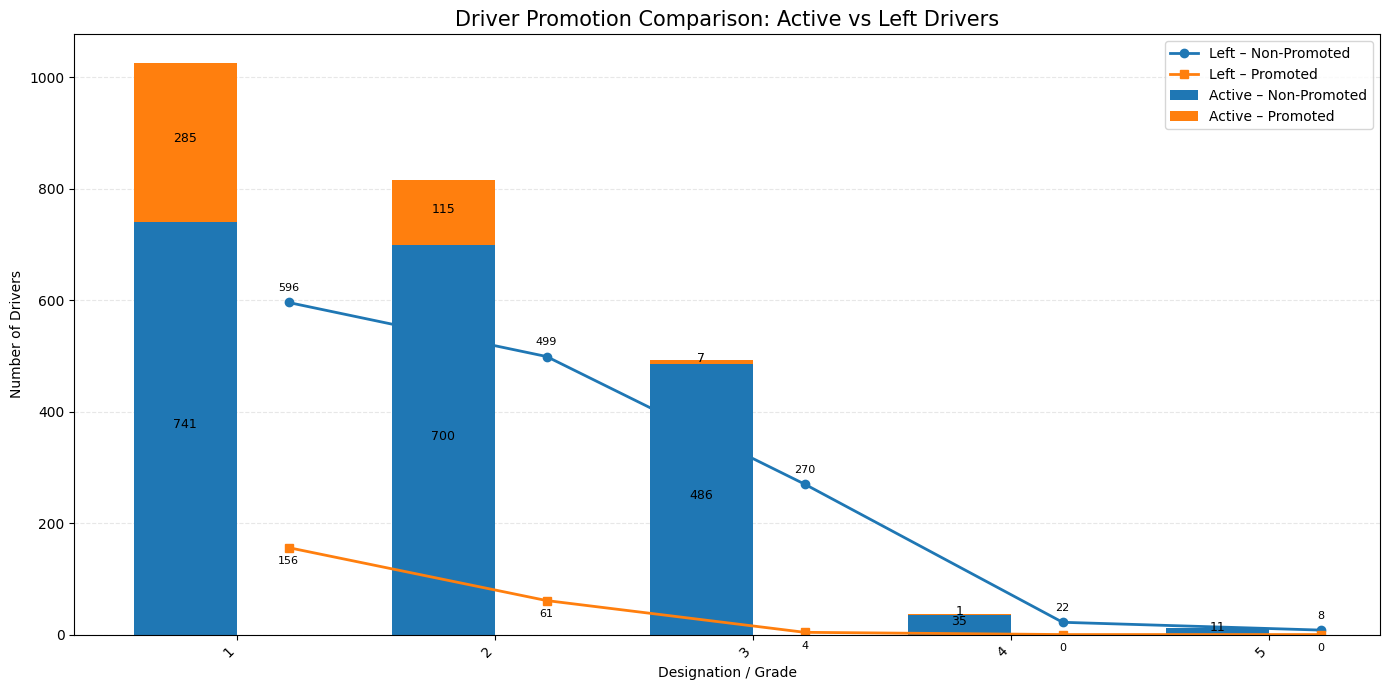

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

result_df = spark.sql("""
WITH JoiningGrade AS (
    SELECT
        Driver_ID,
        Joining_Designation,
        MAX(Grade) AS Max_Grade
    FROM ola_drivers
    GROUP BY Driver_ID, Joining_Designation
),
GradeDesignationCounts AS (
    SELECT
        Joining_Designation,
        Max_Grade,
        COUNT(*) AS cnt,
        ARRAY_UNION(
            ARRAY(CAST(Joining_Designation AS STRING)),
            ARRAY(CAST(Max_Grade AS STRING))
        ) AS joined_union_array
    FROM JoiningGrade
    GROUP BY Joining_Designation, Max_Grade
),
TotalDriversPerJoiningDesignation AS (
    SELECT
        Joining_Designation,
        COUNT(DISTINCT Driver_ID) AS total_drivers
    FROM ola_drivers
    GROUP BY Joining_Designation
),
LeftDriversPerJoiningDesignation AS (
    SELECT
        Joining_Designation,
        COUNT(DISTINCT Driver_ID) AS left_drivers
    FROM ola_drivers
    WHERE LastWorkingDate IS NOT NULL
    GROUP BY Joining_Designation
),
LeftGradeDesignationCounts AS (
    SELECT
        jg.Joining_Designation,
        jg.Max_Grade,
        COUNT(*) AS left_cnt,
        ARRAY_UNION(
            ARRAY(CAST(jg.Joining_Designation AS STRING)),
            ARRAY(CAST(jg.Max_Grade AS STRING))
        ) AS joined_union_array
    FROM JoiningGrade jg
    INNER JOIN ola_drivers od
        ON jg.Driver_ID = od.Driver_ID
       AND od.LastWorkingDate IS NOT NULL
    GROUP BY jg.Joining_Designation, jg.Max_Grade
)

SELECT
    gdc.joined_union_array,
    'All_Drivers' AS driver_type,
    ROUND(gdc.cnt * 100.0 / td.total_drivers, 2) AS Non_Promoted_Percentage,
    ROUND((td.total_drivers - gdc.cnt) * 100.0 / td.total_drivers, 2) AS Promoted_Percentage,
    gdc.cnt AS Non_Promoted_Count,
    (td.total_drivers - gdc.cnt) AS Promoted_Count,
    td.total_drivers AS Total_Drivers
FROM GradeDesignationCounts gdc
JOIN TotalDriversPerJoiningDesignation td
  ON gdc.Joining_Designation = td.Joining_Designation
WHERE size(gdc.joined_union_array) = 1

UNION ALL

SELECT
    lgdc.joined_union_array,
    'Left_Drivers' AS driver_type,
    ROUND(lgdc.left_cnt * 100.0 / ld.left_drivers, 2) AS Non_Promoted_Percentage,
    ROUND((ld.left_drivers - lgdc.left_cnt) * 100.0 / ld.left_drivers, 2) AS Promoted_Percentage,
    lgdc.left_cnt AS Non_Promoted_Count,
    (ld.left_drivers - lgdc.left_cnt) AS Promoted_Count,
    ld.left_drivers AS Total_Drivers
FROM LeftGradeDesignationCounts lgdc
JOIN LeftDriversPerJoiningDesignation ld
  ON lgdc.Joining_Designation = ld.Joining_Designation
WHERE size(lgdc.joined_union_array) = 1

ORDER BY joined_union_array ASC, driver_type DESC
""").toPandas()

all_df = result_df[result_df['driver_type'] == 'All_Drivers']
left_df = result_df[result_df['driver_type'] == 'Left_Drivers']

categories = [str(x[0]) for x in all_df['joined_union_array']]
x = np.arange(len(categories))

plt.figure(figsize=(14, 7))
ax = plt.gca()

# Bar charts (Active Drivers)
ax.bar(x - 0.2, all_df['Non_Promoted_Count'], width=0.4, label="Active – Non-Promoted")
ax.bar(x - 0.2, all_df['Promoted_Count'], width=0.4,
       bottom=all_df['Non_Promoted_Count'], label="Active – Promoted")

# Line charts (Left Drivers)
ax.plot(x + 0.2, left_df['Non_Promoted_Count'], marker='o', linewidth=2,
        label="Left – Non-Promoted")
ax.plot(x + 0.2, left_df['Promoted_Count'], marker='s', linewidth=2,
        label="Left – Promoted")

for i in range(len(x)):
    # Active Non-Promoted
    np_c = int(all_df['Non_Promoted_Count'].iloc[i])
    if np_c > 0:
        ax.text(i - 0.2, np_c/2, str(np_c), ha='center', fontsize=9)

    # Active Promoted
    p_c = int(all_df['Promoted_Count'].iloc[i])
    if p_c > 0:
        ax.text(i - 0.2, np_c + p_c/2, str(p_c), ha='center', fontsize=9)

    # Left Non-Promoted
    ln = int(left_df['Non_Promoted_Count'].iloc[i])
    ax.annotate(str(ln), xy=(i + 0.2, ln), textcoords="offset points",
                xytext=(0, 8), ha='center', fontsize=8)

    # Left Promoted
    lp = int(left_df['Promoted_Count'].iloc[i])
    ax.annotate(str(lp), xy=(i + 0.2, lp), textcoords="offset points",
                xytext=(0, -12), ha='center', fontsize=8)


ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right')

ax.set_ylabel("Number of Drivers")
ax.set_xlabel("Designation / Grade")

ax.set_title("Driver Promotion Comparison: Active vs Left Drivers", fontsize=15)

ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
spark.sql("""WITH promotional_drivers AS (
    SELECT
        Driver_ID,
        COLLECT_SET(Grade) AS Distinct_Grades,
        ARRAY_UNION(COLLECT_SET(Joining_Designation), COLLECT_SET(Grade)) AS All_Distinct_Roles
    FROM ola_drivers
    GROUP BY Driver_ID
    HAVING SIZE(COLLECT_SET(Grade)) > 1
)

select month(od.Dateofjoining) as Year_on_Joining, count(distinct pd.driver_id) as Total_drivers from promotional_drivers pd
inner join ola_drivers od
on od.Driver_ID = pd.Driver_ID
group by month(od.Dateofjoining)
order by month(od.Dateofjoining) asc""").show()

+---------------+-------------+
|Year_on_Joining|Total_drivers|
+---------------+-------------+
|              1|            4|
|              2|            2|
|              4|            1|
|              5|            5|
|              6|            7|
|              7|            7|
|              8|            5|
|              9|            2|
|             10|            4|
|             11|            5|
|             12|            2|
+---------------+-------------+



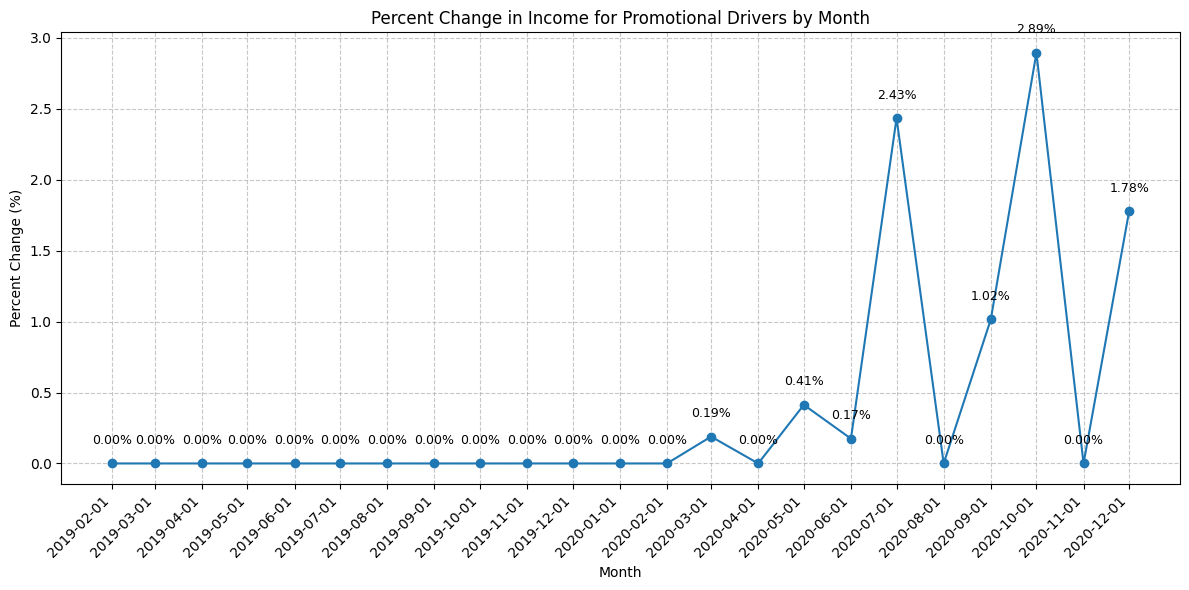

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plot_df_spark = spark.sql("""
WITH promotional_drivers AS (
    SELECT
        Driver_ID,
        COLLECT_SET(Grade) AS Distinct_Grades,
        ARRAY_UNION(COLLECT_SET(Joining_Designation), COLLECT_SET(Grade)) AS All_Distinct_Roles
    FROM ola_drivers
    GROUP BY Driver_ID
    HAVING SIZE(COLLECT_SET(Grade)) > 1
),

DriverCount AS (
    SELECT
        COUNT(DISTINCT CASE WHEN pd.Driver_ID IS NOT NULL THEN od.Driver_ID END)
            AS Total_Drivers_Promoted,
        COUNT(DISTINCT CASE WHEN pd.Driver_ID IS NULL THEN od.Driver_ID END)
            AS Total_Drivers_Not_Promoted
    FROM ola_drivers od
    LEFT JOIN promotional_drivers pd
        ON pd.Driver_ID = od.Driver_ID
)

SELECT td.MMM_YY as Year, avg(td.percent_change) as percent_change
FROM (
    SELECT
        pd.Driver_ID,
        od.MMM_YY,
        od.Income,
        LAG(od.Income, 1, NULL) OVER (
            PARTITION BY pd.Driver_ID
            ORDER BY od.MMM_YY ASC
        ) AS Previous_Income,
        (od.Income - LAG(od.Income, 1, NULL) OVER (
            PARTITION BY pd.Driver_ID ORDER BY od.MMM_YY ASC
        )) * 100.0 / od.Income AS percent_change
    FROM promotional_drivers pd
    INNER JOIN ola_drivers od
        ON od.Driver_ID = pd.Driver_ID
) td
WHERE td.Previous_Income IS NOT NULL AND td.Income != 0
GROUP BY td.MMM_YY
ORDER BY td.MMM_YY
""")

plot_df = plot_df_spark.toPandas()

# Convert MMM_YY to datetime and convert Decimal to float
plot_df['Year'] = pd.to_datetime(plot_df['Year'], format='%b-%y')
plot_df['percent_change'] = plot_df['percent_change'].astype(float)  # Convert Decimal to float
plot_df = plot_df.sort_values('Year')

plt.figure(figsize=(12, 6))
plt.plot(plot_df['Year'], plot_df['percent_change'], marker='o')
plt.title('Percent Change in Income for Promotional Drivers by Month')
plt.xlabel('Month')
plt.ylabel('Percent Change (%)')
plt.grid(True, linestyle='--', alpha=0.7)

# Fix overlapping x labels
plt.xticks(plot_df['Year'], rotation=45, ha='right')

y_max = plot_df['percent_change'].max()
offset = y_max * 0.04   # dynamic spacing above each point

for x, y in zip(plot_df['Year'], plot_df['percent_change']):
    plt.text(
        x,
        y + offset,
        f"{y:.2f}%",
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=0
    )

plt.tight_layout()
plt.show()

**BUSINESS VALUE**

Business Value Growth Data:
    MMM_YY  Total_Business_Value  Percentage_Of_Average  \
0        1            1170704780                 128.64   
1        2            1060315840                 116.51   
2        3            2713437150                 298.15   
3        4             408232160                  44.86   
4        5             536001710                  58.90   
5        6             572262440                  62.88   
6        7             756342410                  83.11   
7        8             618685100                  67.98   
8        9             841406120                  92.45   
9       10             746631900                  82.04   
10      11             664844120                  73.05   
11      12             832168550                  91.44   

   Month_Over_Month_Growth  
0                     None  
1                    -9.43  
2                   155.91  
3                   -84.96  
4                    31.30  
5                     6.77  
6

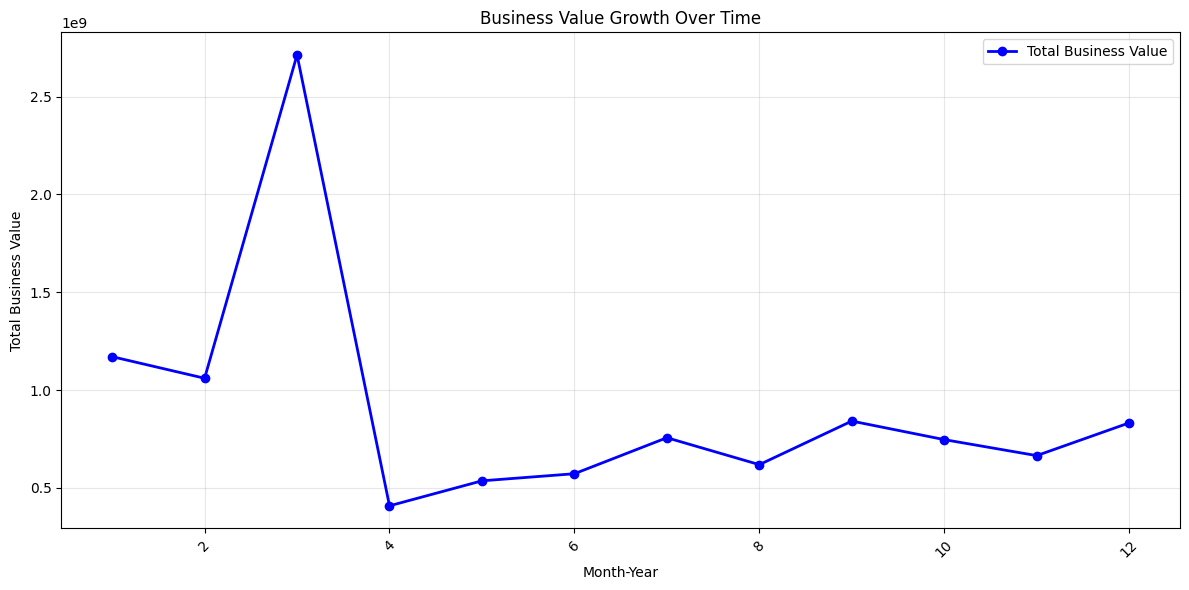

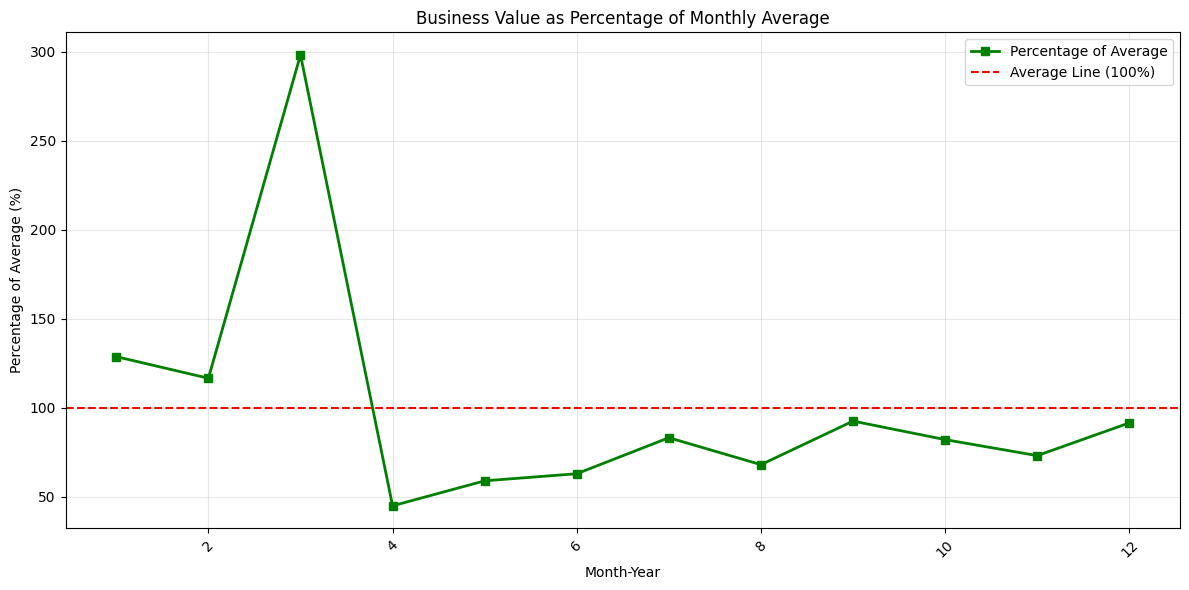

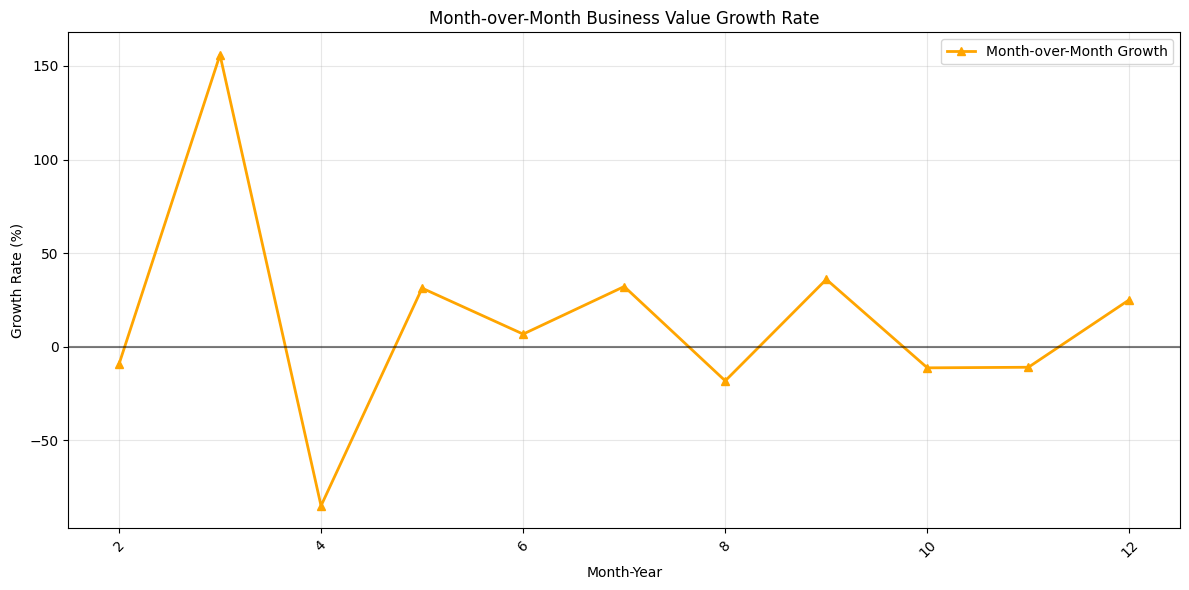

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

result_df = spark.sql("""
WITH monthly_totals AS (
    SELECT
        month(MMM_YY) as MMM_YY,
        SUM(Total_Business_Value) as monthly_business_value
    FROM ola_drivers
    GROUP BY month(MMM_YY)
),
overall_avg AS (
    SELECT AVG(monthly_business_value) as avg_monthly_value
    FROM monthly_totals
)
SELECT
    mt.MMM_YY,
    mt.monthly_business_value as Total_Business_Value,
    ROUND((mt.monthly_business_value * 100.0 / oa.avg_monthly_value), 2) as Percentage_Of_Average,
    ROUND(((mt.monthly_business_value - LAG(mt.monthly_business_value) OVER (ORDER BY mt.MMM_YY)) * 100.0 /
          LAG(mt.monthly_business_value) OVER (ORDER BY mt.MMM_YY)), 2) as Month_Over_Month_Growth
FROM monthly_totals mt
CROSS JOIN overall_avg oa
ORDER BY mt.MMM_YY
""")

# Convert to pandas for plotting
plot_data = result_df.toPandas()

# Display the data
print("Business Value Growth Data:")
print("=" * 50)
print(plot_data)

# Create simple line plot
plt.figure(figsize=(12, 6))

# Plot Total Business Value
plt.plot(plot_data['MMM_YY'], plot_data['Total_Business_Value'],
         marker='o', linewidth=2, label='Total Business Value', color='blue')

plt.title('Business Value Growth Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Total Business Value')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Create plot for Percentage of Average
plt.figure(figsize=(12, 6))
plt.plot(plot_data['MMM_YY'], plot_data['Percentage_Of_Average'],
         marker='s', linewidth=2, label='Percentage of Average', color='green')
plt.axhline(y=100, color='red', linestyle='--', label='Average Line (100%)')
plt.title('Business Value as Percentage of Monthly Average')
plt.xlabel('Month-Year')
plt.ylabel('Percentage of Average (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Create plot for Month-over-Month Growth
plt.figure(figsize=(12, 6))
plt.plot(plot_data['MMM_YY'], plot_data['Month_Over_Month_Growth'],
         marker='^', linewidth=2, label='Month-over-Month Growth', color='orange')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
plt.title('Month-over-Month Business Value Growth Rate')
plt.xlabel('Month-Year')
plt.ylabel('Growth Rate (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

- As the data contains reports from 2019 - 2020, March shows a very higher business revenue for Ola compared to the each and every month.

- Higher number of rides by each drivers have helped to boost its revenue to 155% above the previous month February. As coming to the 2020, on the same month as per Business Today Report, there was a dramatic drop in the demand surgence as COVID-19 hardly strikes India. Where the cab suspensions were higher in all the metropolitian cities curtailing the business revenue to its diminishing marginal returns. The data could be that as March is the end of FY the stock prices or any type of reserves could be overvalued as for the accounting purpose

- April

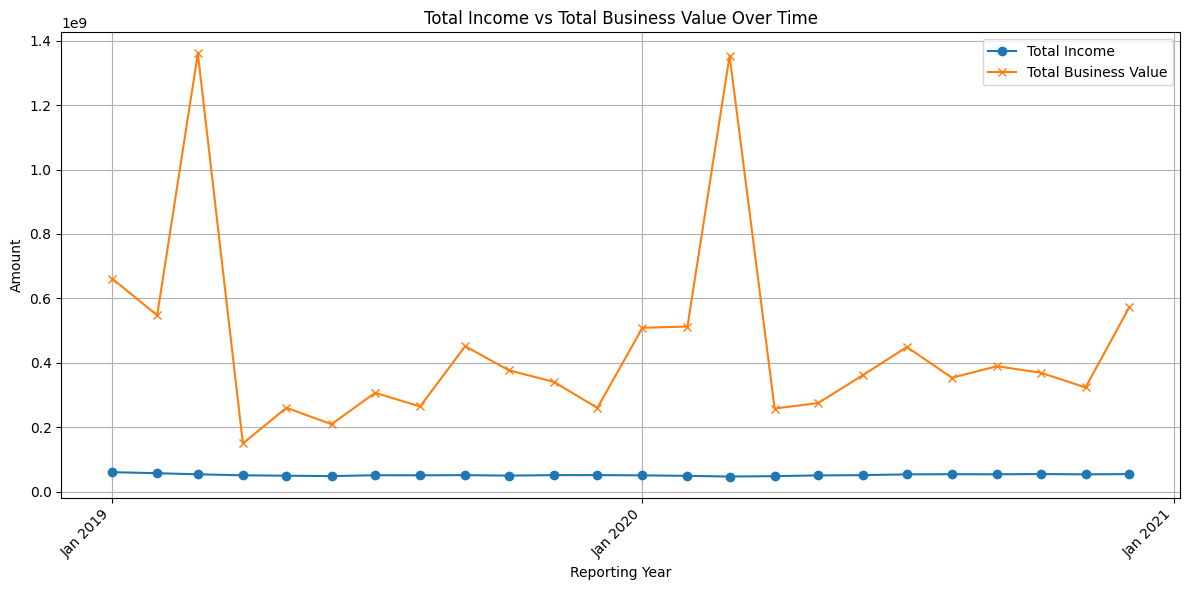

In [ ]:
import matplotlib.dates as mdates
import pandas as pd
import matplotlib.pyplot as plt

income_business_df = spark.sql("""
    SELECT
        MMM_YY AS Reporting_Year,
        sum(Income) as Total_Income,
        sum(Total_Business_Value) as Total_Business
    FROM ola_drivers
    group by MMM_YY
    ORDER BY Reporting_Year""").toPandas()

# Ensure 'Reporting_Year' is a datetime object for proper plotting
income_business_df['Reporting_Year'] = pd.to_datetime(income_business_df['Reporting_Year'])

plt.figure(figsize=(12, 6))
plt.plot(income_business_df['Reporting_Year'], income_business_df['Total_Income'], label='Total Income', marker='o')
plt.plot(income_business_df['Reporting_Year'], income_business_df['Total_Business'], label='Total Business Value', marker='x')

plt.title('Total Income vs Total Business Value Over Time')
plt.xlabel('Reporting Year')
plt.ylabel('Amount')
plt.legend()
plt.grid(True)

# Format x-axis to show month and year
ax = plt.gca()
formatter = mdates.DateFormatter('%b %Y')  # Changed from '%b %y' to '%b %Y' for full year
ax.xaxis.set_major_formatter(formatter)

# Set appropriate locator based on your date range
if len(income_business_df) > 0:
    date_range = income_business_df['Reporting_Year'].max() - income_business_df['Reporting_Year'].min()
    if date_range.days > 365:  # If span is more than 1 year
        ax.xaxis.set_major_locator(mdates.YearLocator())
    else:  # If within 1 year
        ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.xticks(rotation=45, ha='right')  # Rotate and align for readability

plt.tight_layout()
plt.show()

- The remuneration for every drivers stays fixed only varies for 44 employees who are getting into a promotion status by (?).

- Business Value represents that each day there would be a change in its revenue value showing more volatality as business tries to grow.

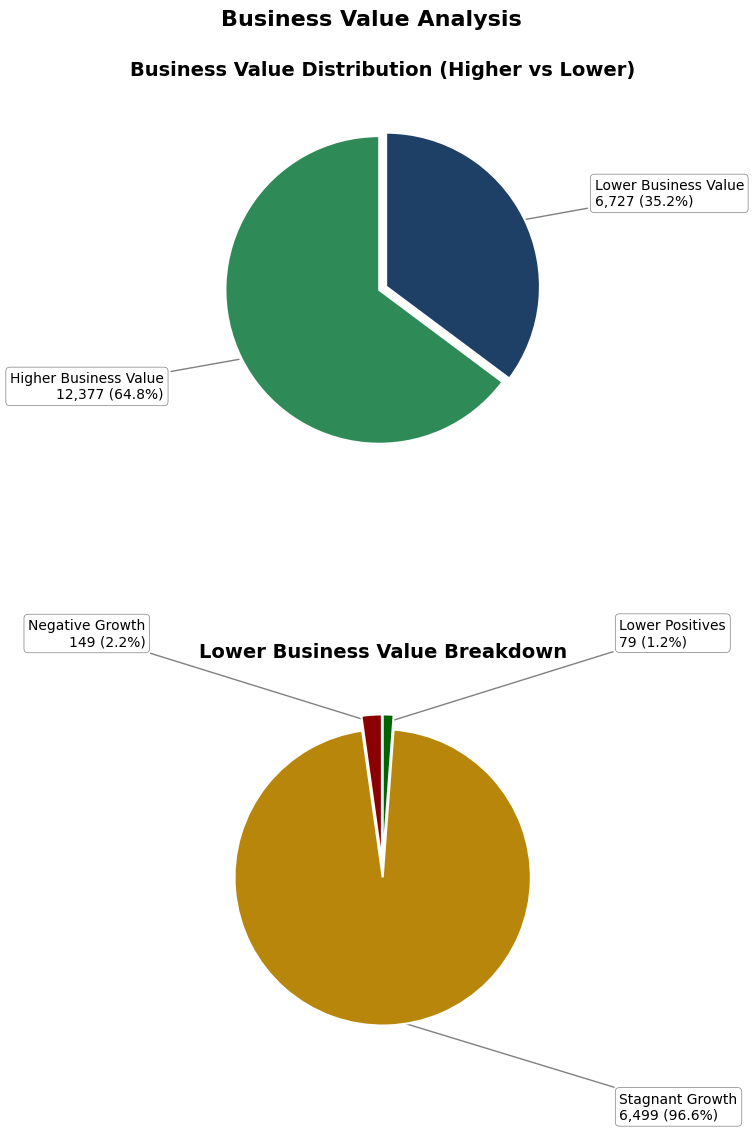

                   ACTUAL BUSINESS COUNTS                   
Higher Business Value : 12,377
Lower Business Value  : 6,727
  - Negative Growth   : 149
  - Stagnant Growth   : 6,499
  - Lower Positives   : 79
------------------------------------------------------------
Total Records         : 19,104


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

result_df = spark.sql("""
    SELECT *, Lower_Business_Value - (Negative_Growth + Stagnant_Growth) AS Lower_Positives
    FROM (
        SELECT
            SUM(CASE WHEN Total_Business_Value > Income THEN 1 ELSE 0 END) AS Higher_Business_Value,
            SUM(CASE WHEN Total_Business_Value < Income THEN 1 ELSE 0 END) AS Lower_Business_Value,
            SUM(CASE WHEN Total_Business_Value < 0 THEN 1 ELSE 0 END) AS Negative_Growth,
            SUM(CASE WHEN Total_Business_Value = 0 THEN 1 ELSE 0 END) AS Stagnant_Growth
        FROM ola_drivers
    ) td
""")

# Convert Spark DataFrame to pandas
result = result_df.toPandas().iloc[0]

# Extract values
higher_value = result['Higher_Business_Value']
lower_value = result['Lower_Business_Value']
negative_growth = result['Negative_Growth']
stagnant_growth = result['Stagnant_Growth']
lower_positives = result['Lower_Positives']

main_labels = ['Higher Business Value', 'Lower Business Value']
main_sizes = [higher_value, lower_value]
main_colors = ['#2E8B57', '#1E3F66']  # Dark Sea Green, Dark Blue

sub_labels = ['Negative Growth', 'Stagnant Growth', 'Lower Positives']
sub_sizes = [negative_growth, stagnant_growth, lower_positives]
sub_colors = ['#8B0000', '#B8860B', '#006400']  # Dark Red, Dark Goldenrod, Dark Green


def make_label_text(values):
    def format_label(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f"{pct:.1f}% ({val:,})"
    return format_label

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 12))


wedges_main, _ = ax1.pie(
    main_sizes,
    labels=None,
    colors=main_colors,
    startangle=90,
    explode=(0, 0.05),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.5)
kw = dict(arrowprops=dict(arrowstyle="-", color="gray"),
          bbox=bbox_props, zorder=0, va="center")

for i, p in enumerate(wedges_main):
    ang = (p.theta2 - p.theta1) / 2. + p.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    ax1.annotate(
        f"{main_labels[i]}\n{main_sizes[i]:,} ({(main_sizes[i]/sum(main_sizes))*100:.1f}%)",
        xy=(x, y),
        xytext=(1.4 * np.sign(x), 1.4 * y),
        horizontalalignment=horizontalalignment,
        **kw
    )

ax1.set_title("Business Value Distribution (Higher vs Lower)",
              fontsize=14, fontweight='bold', pad=30)
ax1.axis('equal')


wedges_sub, _ = ax2.pie(
    sub_sizes,
    labels=None,
    colors=sub_colors,
    startangle=90,
    explode=(0.05, 0.05, 0.05),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

for i, p in enumerate(wedges_sub):
    ang = (p.theta2 - p.theta1) / 2. + p.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    ax2.annotate(
        f"{sub_labels[i]}\n{sub_sizes[i]:,} ({(sub_sizes[i]/sum(sub_sizes))*100:.1f}%)",
        xy=(x, y),
        xytext=(1.6 * np.sign(x), 1.6 * y),
        horizontalalignment=horizontalalignment,
        **kw
    )

ax2.set_title("Lower Business Value Breakdown",
              fontsize=14, fontweight='bold', pad=30)
ax2.axis('equal')

plt.suptitle("Business Value Analysis", fontsize=16, fontweight='bold', y=0.97)
plt.subplots_adjust(hspace=0.7)  # More gap between pies
plt.show()

print("=" * 60)
print("ACTUAL BUSINESS COUNTS".center(60))
print("=" * 60)
print(f"Higher Business Value : {higher_value:,.0f}")
print(f"Lower Business Value  : {lower_value:,.0f}")
print(f"  - Negative Growth   : {int(negative_growth):,}")
print(f"  - Stagnant Growth   : {int(stagnant_growth):,}")
print(f"  - Lower Positives   : {int(lower_positives):,}")
print("-" * 60)
print(f"Total Records         : {higher_value + lower_value:,.0f}")
print("=" * 60)


In [ ]:
## Total Business Value ratio by Active and Left Drivers


spark.sql("""
    SELECT
        SUM(CASE WHEN LastworkingDate IS NOT NULL THEN Total_Business_Value ELSE 0 END) AS Left_Drivers_Total_Business_Value,
        SUM(CASE WHEN (LastworkingDate IS NOT NULL and Total_Business_Value < 0) THEN Total_Business_Value ELSE 0 END) AS Drivers_Left_Business_Negative,
        SUM(CASE WHEN Total_Business_Value < 0 THEN Total_Business_Value ELSE 0 END) - SUM(CASE WHEN (LastworkingDate IS NOT NULL and Total_Business_Value < 0) THEN Total_Business_Value ELSE 0 END)
         AS Drivers_Active_Business_Negative,
       SUM(Total_Business_Value) - SUM(CASE WHEN LastworkingDate IS NOT NULL THEN Total_Business_Value ELSE 0 END) AS Active_Drivers_Total_Business
    FROM ola_drivers
""").show()

+---------------------------------+------------------------------+--------------------------------+-----------------------------+
|Left_Drivers_Total_Business_Value|Drivers_Left_Business_Negative|Drivers_Active_Business_Negative|Active_Drivers_Total_Business|
+---------------------------------+------------------------------+--------------------------------+-----------------------------+
|                         66560490|                      -9224400|                       -64149820|                  10854471790|
+---------------------------------+------------------------------+--------------------------------+-----------------------------+



In [ ]:
## Highest Negative Value by Grade wise

spark.sql("""
    SELECT
        Grade,
        SUM(Total_Business_Value), sum(case when Total_Business_Value < 0 then Total_Business_Value else 0 end) as Negative_TBV_per_Grade from ola_drivers group by grade
        order by Grade asc""").show()

+-----+-------------------------+----------------------+
|Grade|sum(Total_Business_Value)|Negative_TBV_per_Grade|
+-----+-------------------------+----------------------+
|    1|               1854494680|             -12474300|
|    2|               3091545830|             -13958110|
|    3|               2878290530|             -34757580|
|    4|               2665722600|             -10536130|
|    5|                430978640|              -1648100|
+-----+-------------------------+----------------------+



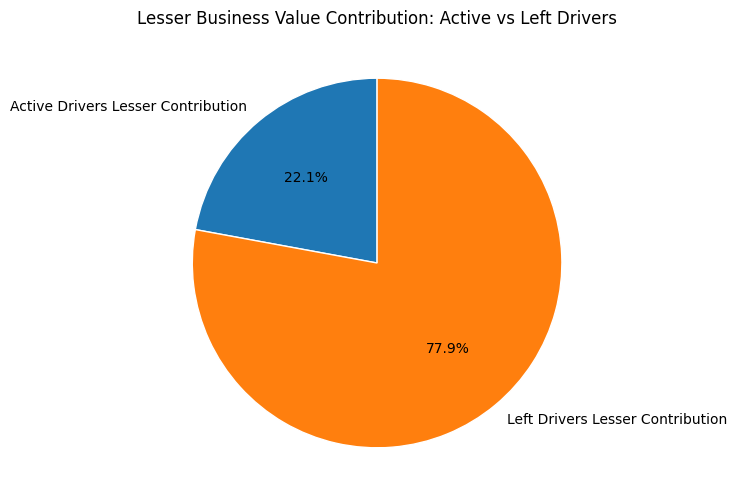

In [ ]:
import matplotlib.pyplot as plt

# Run your Spark SQL query
result_df = spark.sql("""
    WITH TotalDrivers AS (
        SELECT Driver_ID
        FROM ola_drivers
        GROUP BY Driver_ID
        HAVING SUM(Total_Business_Value) < SUM(Income)
    ),
    LeftDrivers AS (
        SELECT DISTINCT Driver_ID
        FROM ola_drivers
        WHERE LastWorkingDate IS NOT NULL
    )
    SELECT
        'Left_Drivers_Lesser_Contribution' as Metric,
        COUNT(*) as Count
    FROM TotalDrivers td
    WHERE td.Driver_ID IN (SELECT Driver_ID FROM LeftDrivers)

    UNION ALL

    SELECT
        'All_Drivers_Lesser_Contribution' as Metric,
        COUNT(*) as Count
    FROM TotalDrivers
""")

# Convert to pandas for easier handling
pdf = result_df.toPandas()

# Extract counts
left_count = int(pdf.loc[pdf['Metric'] == 'Left_Drivers_Lesser_Contribution', 'Count'].values[0])
all_count = int(pdf.loc[pdf['Metric'] == 'All_Drivers_Lesser_Contribution', 'Count'].values[0])

# Calculate Active Drivers' count
active_count = all_count - left_count

# Prepare pie chart data
labels = ['Active Drivers Lesser Contribution', 'Left Drivers Lesser Contribution']
sizes = [active_count, left_count]

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
plt.title("Lesser Business Value Contribution: Active vs Left Drivers")
plt.show()


In [ ]:
# Promotional Group
spark.sql("""
    WITH PromotionalDrivers AS (
        SELECT
            Driver_ID,
            COLLECT_SET(Grade) AS Distinct_Grades
        FROM ola_drivers
        GROUP BY Driver_ID
        HAVING SIZE(COLLECT_SET(Grade)) > 1
    ),

    FlattenedPromotionalGrades AS (
        SELECT
            pd.Driver_ID,
            exploded_grade AS Grade_Promoted
        FROM PromotionalDrivers pd
        LATERAL VIEW EXPLODE(pd.Distinct_Grades) adtable AS exploded_grade
    ),

    LeftDriver AS (
        SELECT DISTINCT Driver_ID
        FROM ola_drivers
        WHERE LastWorkingDate IS NOT NULL
    )

    SELECT
        fpg.Grade_Promoted as Grade,
        COUNT(DISTINCT fpg.Driver_ID) AS Total_Promotional_Drivers,
        COUNT(DISTINCT CASE WHEN ld.Driver_ID IS NOT NULL THEN fpg.Driver_ID END) AS Left_Promotional_Drivers,
        COUNT(DISTINCT CASE WHEN ld.Driver_ID IS NULL THEN fpg.Driver_ID END) AS Active_Promotional_Drivers
    FROM FlattenedPromotionalGrades fpg
    LEFT JOIN LeftDriver ld ON fpg.Driver_ID = ld.Driver_ID
    GROUP BY fpg.Grade_Promoted
    ORDER BY Grade asc
""").show()

+-----+-------------------------+------------------------+--------------------------+
|Grade|Total_Promotional_Drivers|Left_Promotional_Drivers|Active_Promotional_Drivers|
+-----+-------------------------+------------------------+--------------------------+
|    1|                       10|                       0|                        10|
|    2|                       32|                       1|                        31|
|    3|                       31|                       2|                        29|
|    4|                       12|                       2|                        10|
|    5|                        3|                       1|                         2|
+-----+-------------------------+------------------------+--------------------------+



In [ ]:
spark.sql("""WITH PromotionalDrivers AS (
        SELECT
            Driver_ID,
            COLLECT_SET(Grade) AS Distinct_Grades
        FROM ola_drivers
        GROUP BY Driver_ID
        HAVING SIZE(COLLECT_SET(Grade)) > 1
    )

    select count(*) as Total_drivers_underperformed_from_promotion from(
    select od.Driver_ID, sum(od.Income) as Total_Income, sum(od.Total_Business_Value) as Total_BV from PromotionalDrivers pd
    inner join ola_drivers od
    on od.Driver_ID = pd.Driver_ID
    group by od.Driver_ID
    having (Total_BV * 100/Total_Income) <= 100
    )""").show()

+-------------------------------------------+
|Total_drivers_underperformed_from_promotion|
+-------------------------------------------+
|                                          0|
+-------------------------------------------+



In [ ]:
spark.sql("""
WITH Undervalued_TBV_driver AS (
    SELECT
        Driver_ID,
        SUM(Total_Business_Value) AS Total_BV,
        SUM(Income) AS Total_Income
    FROM ola_drivers
    GROUP BY Driver_ID
    HAVING (Total_BV * 100 / Total_Income) <= 100
),

LeftDrivers AS (
    SELECT DISTINCT Driver_ID
    FROM ola_drivers
    WHERE LastWorkingDate IS NOT NULL
)

SELECT
    od.Grade,
    COUNT(DISTINCT CASE
        WHEN ut.Driver_ID IS NOT NULL AND ld.Driver_ID IS NOT NULL
        THEN od.Driver_ID
    END) AS Total_drivers_left,

    COUNT(DISTINCT CASE
        WHEN ut.Driver_ID IS NOT NULL AND ld.Driver_ID IS NULL
        THEN od.Driver_ID
    END) AS Total_drivers_active

FROM ola_drivers od
LEFT JOIN Undervalued_TBV_driver ut
    ON ut.Driver_ID = od.Driver_ID
LEFT JOIN LeftDrivers ld
    ON ld.Driver_ID = od.Driver_ID

GROUP BY od.Grade
ORDER BY od.Grade ASC
""").show()


+-----+------------------+--------------------+
|Grade|Total_drivers_left|Total_drivers_active|
+-----+------------------+--------------------+
|    1|               225|                  35|
|    2|               253|                  77|
|    3|               163|                  74|
|    4|                14|                   2|
|    5|                11|                   1|
+-----+------------------+--------------------+



In [ ]:
spark.sql("""
    WITH Performed_Drivers AS (
        SELECT
            Driver_ID,
            SUM(Total_Business_Value) AS Total_BV, -- Added Total_BV
            SUM(Income) AS Total_Income,           -- Added Total_Income
            MIN(DateOfJoining) as First_Join_Date,
            MAX(LastWorkingDate) as Last_Date,
            DATEDIFF(MAX(LastWorkingDate), MIN(DateOfJoining)) as Total_Duration_Days,
            COLLECT_SET(Joining_Designation) as Distinct_Joining_Designations,
            COLLECT_SET(Grade) as Distinct_Grades,
            ARRAY_UNION(COLLECT_SET(Joining_Designation), COLLECT_SET(Grade)) as Count_Distinct_Grades,
            COUNT(*) as Total_Records
        FROM ola_drivers
        GROUP BY Driver_ID
        HAVING SIZE(COLLECT_SET(Grade)) > 1
        AND (SUM(Total_Business_Value) * 100 / SUM(Income)) > 100
    ),

    PromotionalDrivers AS (
        SELECT
            Driver_ID,
            COLLECT_SET(Grade) AS Distinct_Grades
        FROM ola_drivers
        GROUP BY Driver_ID
        HAVING SIZE(COLLECT_SET(Grade)) > 1
    )


    select
        td.Driver_ID,
        td.BV_Income_Percentage,
        td.Total_BV,
        td.Rank_Overall,
        td.Count_Distinct_Grades
    from(
      SELECT
        Driver_ID,
        Total_BV,
        Total_Income,
        (Total_BV * 100 / Total_Income) AS BV_Income_Percentage,
        DENSE_RANK() OVER (ORDER BY (Total_BV * 100 / Total_Income) DESC) AS Rank_Overall,
        Count_Distinct_Grades -- Make Count_Distinct_Grades available for outer select
      FROM Performed_Drivers
    ) td
    inner join PromotionalDrivers pr
    on pr.Driver_ID = td.Driver_ID
    order by td.Rank_Overall asc

""").show(44)

+---------+--------------------+--------+------------+---------------------+
|Driver_ID|BV_Income_Percentage|Total_BV|Rank_Overall|Count_Distinct_Grades|
+---------+--------------------+--------+------------+---------------------+
|     1249|  6757.0068988343855|27355810|           1|               [1, 2]|
|     1327|     5222.7259111333|33998640|           2|               [1, 2]|
|     2008|  3971.6270158544025|26824210|           3|               [1, 2]|
|      582|   3961.022561454709|26819450|           4|               [2, 3]|
|      307|   3182.170024012097|56839380|           5|            [2, 3, 4]|
|      568|  3075.9689064091776|41667690|           6|            [1, 3, 4]|
|     1783|   2809.072485086214|34374620|           7|            [1, 2, 3]|
|      368|   2715.376590384507|30869270|           8|               [1, 2]|
|      434|  2610.7590076846445|51680810|           9|            [1, 2, 3]|
|     2543|   2539.364478360517|33882080|          10|            [1, 2, 3]|

In [ ]:
spark.sql("""WITH Performed_Drivers AS (
        SELECT
            Driver_ID,
            SUM(Total_Business_Value) AS Total_BV, -- Added Total_BV
            SUM(Income) AS Total_Income,           -- Added Total_Income
            MIN(DateOfJoining) as First_Join_Date,
            MAX(LastWorkingDate) as Last_Date,
            DATEDIFF(MAX(LastWorkingDate), MIN(DateOfJoining)) as Total_Duration_Days,
            COLLECT_SET(Joining_Designation) as Distinct_Joining_Designations,
            COLLECT_SET(Grade) as Distinct_Grades,
            ARRAY_UNION(COLLECT_SET(Joining_Designation), COLLECT_SET(Grade)) as Count_Distinct_Grades,
            COUNT(*) as Total_Records
        FROM ola_drivers
        GROUP BY Driver_ID
        HAVING SIZE(COLLECT_SET(Grade)) > 1
        AND (SUM(Total_Business_Value) * 100 / SUM(Income)) > 100
    )

    select Count_Distinct_Grades, sum(Total_BV) as Total_BV from Performed_Drivers
    group by Count_Distinct_Grades
    order by Total_BV desc""").show()

+---------------------+---------+
|Count_Distinct_Grades| Total_BV|
+---------------------+---------+
|            [1, 2, 3]|421856440|
|            [1, 3, 4]|322430570|
|               [1, 2]|254003950|
|               [2, 3]|231795660|
|            [2, 3, 4]| 81134050|
|            [2, 5, 4]| 54792310|
|            [1, 5, 4]| 52526160|
|               [4, 5]| 33823290|
+---------------------+---------+



/tmp/ipython-input-814889110.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Count_Distinct_Grades', y='Avg_BV', data=plot_df_pandas, palette='viridis')


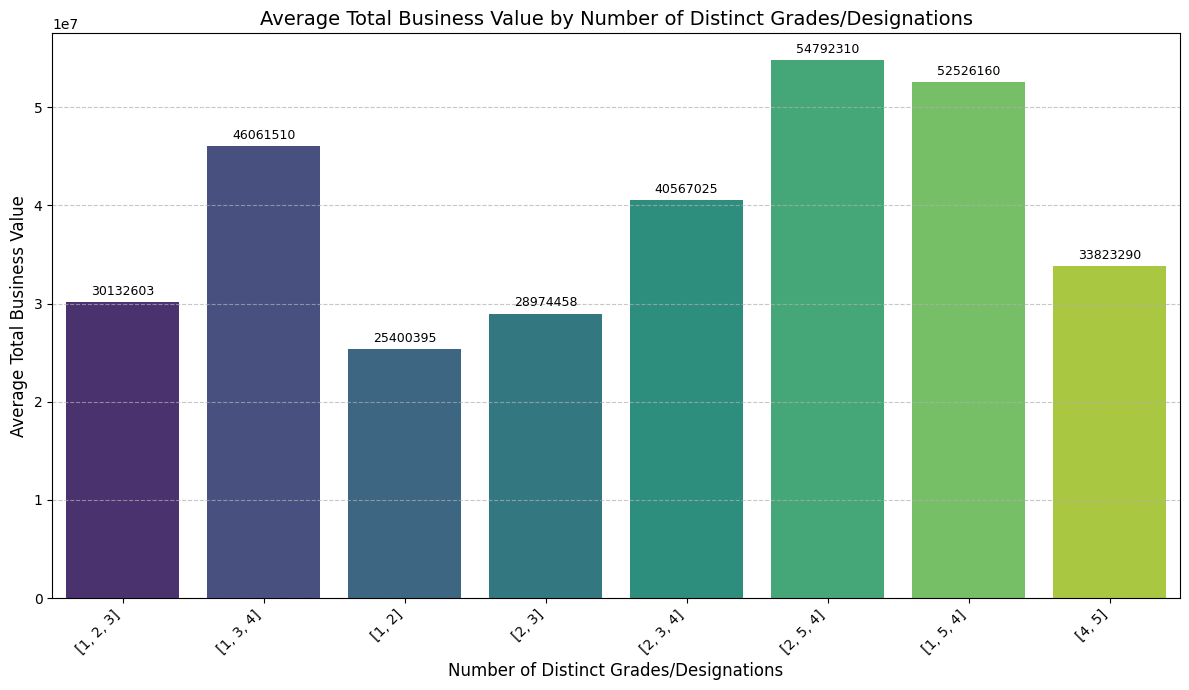

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Execute the Spark SQL query to get the aggregated data
plot_df_spark = spark.sql("""WITH Performed_Drivers AS (
        SELECT
            Driver_ID,
            SUM(Total_Business_Value) AS Total_BV,
            SUM(Income) AS Total_Income,
            MIN(DateOfJoining) as First_Join_Date,
            MAX(LastWorkingDate) as Last_Date,
            DATEDIFF(MAX(LastWorkingDate), MIN(DateOfJoining)) as Total_Duration_Days,
            COLLECT_SET(Joining_Designation) as Distinct_Joining_Designations,
            COLLECT_SET(Grade) as Distinct_Grades,
            ARRAY_UNION(COLLECT_SET(Joining_Designation), COLLECT_SET(Grade)) as Count_Distinct_Grades,
            COUNT(*) as Total_Records
        FROM ola_drivers
        GROUP BY Driver_ID
        HAVING SIZE(COLLECT_SET(Grade)) > 1
        AND (SUM(Total_Business_Value) * 100 / SUM(Income)) > 100
    )

    select Count_Distinct_Grades, avg(Total_BV) as Avg_BV, sum(Total_BV) as Total_BV from Performed_Drivers
    group by Count_Distinct_Grades
    order by Total_BV desc""") # Corrected string termination

# Convert Spark DataFrame to Pandas DataFrame for plotting
plot_df_pandas = plot_df_spark.toPandas()

# Convert the list in 'Count_Distinct_Grades' column to string for plotting
plot_df_pandas['Count_Distinct_Grades'] = plot_df_pandas['Count_Distinct_Grades'].apply(lambda x: str(x))

plt.figure(figsize=(12, 7)) # Increased figure size for better label visibility
ax = sns.barplot(x='Count_Distinct_Grades', y='Avg_BV', data=plot_df_pandas, palette='viridis')
plt.title('Average Total Business Value by Number of Distinct Grades/Designations', fontsize=14)
plt.xlabel('Number of Distinct Grades/Designations', fontsize=12)
plt.ylabel('Average Total Business Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(fontsize=10)

# Add data labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=9, color='black', padding=3)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
spark.sql("""With td as(
    select Driver_ID, (Total_Revenue * 100/Total_Business_value_By_Driver_ID) as Total_contribution_by_Driver from(
        select Driver_ID, sum(Income) as Total_Revenue, sum(Total_Business_Value) as Total_Business_value_By_Driver_ID from ola_drivers
        group by Driver_ID
        having (sum(Income) * 100/sum(Total_Business_Value)) <= 0
    ) as Total_contribution
)

select
    count(distinct td.Driver_ID) - sum(case when od.LastWorkingDate IS NOT NULL then 1 else 0 end)
     as Total_drivers_active,
    sum(case when od.LastWorkingDate IS NOT NULL then 1 else 0 end) as Total_drivers_left
from ola_drivers od
inner join td on od.Driver_ID = td.Driver_ID
""").show()

+--------------------+------------------+
|Total_drivers_active|Total_drivers_left|
+--------------------+------------------+
|                   0|                10|
+--------------------+------------------+



In [ ]:
## Total business value is positive as contribution in each entry, comparison by
## promotional and aggregate drivers

spark.sql("""With td as
(
    select Driver_ID, count(*) as TBV_count, sum(case when Total_Business_Value > 0
    then 1 else 0 end) as Total_Postive, sum(Total_Business_Value) as Total_Business_Value_acquired from ola_drivers
    group by Driver_ID
    having Total_Postive = TBV_count
),
promotional_drivers as
(
    SELECT
        Driver_ID,
        MIN(DateOfJoining) as First_Join_Date,
        MAX(LastWorkingDate) as Last_Date,
        DATEDIFF(MAX(LastWorkingDate), MIN(DateOfJoining)) as Total_Duration_Days,
        COLLECT_SET(Joining_Designation) as Distinct_Joining_Designations,
        COLLECT_SET(Grade) as Distinct_Grades,
        SIZE(COLLECT_SET(Grade)) as Count_Distinct_Grades,
        COUNT(*) as Total_Records
    FROM ola_drivers
    GROUP BY Driver_ID
    HAVING SIZE(COLLECT_SET(Grade)) > 1
)

select sum(case when pd.Driver_ID is NOT NULL then 1 else 0 end) as Total_drivers_promoted_based_on_TBV, count(*) as Total_drivers_acquired from td
left join promotional_drivers pd
on pd.Driver_ID = td.Driver_ID
""").show()

+-----------------------------------+----------------------+
|Total_drivers_promoted_based_on_TBV|Total_drivers_acquired|
+-----------------------------------+----------------------+
|                                 10|                   137|
+-----------------------------------+----------------------+



In [ ]:
## Total Business Value by sum which is positive by promotional and driver_id

spark.sql("""With td as
(
    select Driver_ID, count(*) as TBV_count, sum(Total_Business_Value) as Total_Business_Value_acquired from ola_drivers
    group by Driver_ID
    having Total_Business_Value_acquired > 0
),
promotional_drivers as
(
    SELECT
        Driver_ID,
        MIN(DateOfJoining) as First_Join_Date,
        MAX(LastWorkingDate) as Last_Date,
        DATEDIFF(MAX(LastWorkingDate), MIN(DateOfJoining)) as Total_Duration_Days,
        COLLECT_SET(Joining_Designation) as Distinct_Joining_Designations,
        COLLECT_SET(Grade) as Distinct_Grades,
        SIZE(COLLECT_SET(Grade)) as Count_Distinct_Grades,
        COUNT(*) as Total_Records
    FROM ola_drivers
    GROUP BY Driver_ID
    HAVING SIZE(COLLECT_SET(Grade)) > 1
)

select sum(case when pd.Driver_ID is NOT NULL then 1 else 0 end) as Total_drivers_promoted_based_on_TBV, count(*) as Total_drivers_acquired from td
left join promotional_drivers pd
on pd.Driver_ID = td.Driver_ID
""").show()

+-----------------------------------+----------------------+
|Total_drivers_promoted_based_on_TBV|Total_drivers_acquired|
+-----------------------------------+----------------------+
|                                 44|                  1652|
+-----------------------------------+----------------------+



In [ ]:
# Simple count of promotional vs non-promotional drivers
driver_count_summary = spark.sql("""
WITH PromotionalDrivers AS (
    SELECT
        Driver_ID
    FROM ola_drivers
    GROUP BY Driver_ID
    HAVING SIZE(COLLECT_SET(Grade)) > 1
)

SELECT
    CASE
        WHEN pd.Driver_ID IS NOT NULL THEN 'Promotional Drivers'
        ELSE 'Non-Promotional Drivers'
    END AS Driver_Type,
    COUNT(DISTINCT od.Driver_ID) as Driver_Count,
    COUNT(*) as Total_Records,
    ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT od.Driver_ID), 2) as Avg_Records_Per_Driver,
    ROUND(COUNT(DISTINCT od.Driver_ID) * 100.0 / (SELECT COUNT(DISTINCT Driver_ID) FROM ola_drivers), 2) as Percentage_Of_Total
FROM ola_drivers od
LEFT JOIN PromotionalDrivers pd ON od.Driver_ID = pd.Driver_ID
GROUP BY
    CASE
        WHEN pd.Driver_ID IS NOT NULL THEN 'Promotional Drivers'
        ELSE 'Non-Promotional Drivers'
    END
""")

driver_count_summary.show()

+--------------------+------------+-------------+----------------------+-------------------+
|         Driver_Type|Driver_Count|Total_Records|Avg_Records_Per_Driver|Percentage_Of_Total|
+--------------------+------------+-------------+----------------------+-------------------+
| Promotional Drivers|          44|          990|                 22.50|               1.85|
|Non-Promotional D...|        2337|        18114|                  7.75|              98.15|
+--------------------+------------+-------------+----------------------+-------------------+



In [ ]:
spark.sql("""
    WITH td AS (
        SELECT
            Driver_ID,
            COUNT(*) AS TBV_count,
            SUM(CASE WHEN Total_Business_Value > 0 THEN 1 ELSE 0 END) AS Total_Postive,
            AVG(Total_Business_Value) AS Avg_TBV
        FROM
            ola_drivers
        GROUP BY
            Driver_ID
        HAVING
            (Total_Postive = TBV_count) AND SUM(Total_Business_Value) > 0
    ),
    driver_tbv_with_lag AS (
        SELECT
            od.Driver_ID,
            od.Total_Business_Value,
            od.MMM_YY,
            LAG(od.Total_Business_Value, 1, 0) OVER (PARTITION BY od.Driver_ID ORDER BY od.MMM_YY) AS previous_Total_Business_Value
        FROM
            td
        INNER JOIN
            ola_drivers od ON td.Driver_ID = od.Driver_ID
    ),
    qualified_drivers AS (
        SELECT
            Driver_ID,
            SUM(CASE WHEN Cumulative_Increase > 0 THEN 1 ELSE 0 END) as Total_Cumulative_Increase,
            COUNT(*) as TBV_count
        FROM (
            SELECT
                Driver_ID,
                Total_Business_Value,
                previous_Total_Business_Value,
                Total_Business_Value - previous_Total_Business_Value AS Cumulative_Increase
            FROM
                driver_tbv_with_lag
        ) tbv_appreciation
        GROUP BY Driver_ID
        HAVING Total_Cumulative_Increase = TBV_count
    )

    SELECT
        qd.Driver_ID,
        qd.Total_Cumulative_Increase,
        YEAR(od.DateOfJoining) AS Joining_Year,
        od.Grade,
        od.Joining_Designation,
        td.Avg_TBV,
        ROUND(td.Avg_TBV, 2) AS Average_Business_Value
    FROM qualified_drivers qd
    INNER JOIN ola_drivers od ON qd.Driver_ID = od.Driver_ID
    INNER JOIN td ON qd.Driver_ID = td.Driver_ID
    WHERE qd.TBV_count > 1
    GROUP BY
        qd.Driver_ID,
        qd.Total_Cumulative_Increase,
        YEAR(od.DateOfJoining),
        od.Grade,
        od.Joining_Designation,
        td.Avg_TBV
""").show()

+---------+-------------------------+------------+-----+-------------------+------------------+----------------------+
|Driver_ID|Total_Cumulative_Increase|Joining_Year|Grade|Joining_Designation|           Avg_TBV|Average_Business_Value|
+---------+-------------------------+------------+-----+-------------------+------------------+----------------------+
|      155|                        2|        2017|    3|                  2|          801190.0|              801190.0|
|      385|                        3|        2020|    3|                  3| 377186.6666666667|             377186.67|
|      867|                        3|        2020|    2|                  2|1119183.3333333333|            1119183.33|
|     2130|                        2|        2015|    2|                  2|          181225.0|              181225.0|
+---------+-------------------------+------------+-----+-------------------+------------------+----------------------+



In [ ]:
TBV_positive = spark.sql("""
WITH td AS (
    SELECT
        Driver_ID,
        COUNT(*) AS TBV_count,
        SUM(CASE WHEN Total_Business_Value > 0 THEN 1 ELSE 0 END) AS Total_Postive
    FROM
        ola_drivers
    GROUP BY
        Driver_ID
    HAVING
        (Total_Postive = TBV_count) AND SUM(Total_Business_Value) > 0
),
driver_tbv_with_lag AS (
    SELECT
        od.Driver_ID,
        od.Total_Business_Value,
        od.MMM_YY,
        LAG(od.Total_Business_Value, 1, 0) OVER (PARTITION BY od.Driver_ID ORDER BY od.MMM_YY) AS previous_Total_Business_Value
    FROM
        td
    INNER JOIN
        ola_drivers od ON td.Driver_ID = od.Driver_ID
),
driver_tbv_with_growth AS (
    SELECT
        Driver_ID,
        SUM(CASE WHEN Cumulative_Increase > 0 THEN 1 ELSE 0 END) AS Total_Cumulative_Increase,
        COUNT(*) AS TBV_count
    FROM (
        SELECT
            Driver_ID,
            Total_Business_Value,
            previous_Total_Business_Value,
            Total_Business_Value - previous_Total_Business_Value AS Cumulative_Increase
        FROM
            driver_tbv_with_lag
    ) tbv_appreciation
    GROUP BY Driver_ID
    HAVING Total_Cumulative_Increase = TBV_count
),
growth_calculations AS (
    SELECT
        dtbv.Driver_ID,
        dtbv.MMM_YY,
        dtbv.Total_Business_Value,
        dtbv.previous_Total_Business_Value,
        CASE
            WHEN dtbv.Total_Business_Value IS NOT NULL AND dtbv.Total_Business_Value != 0
            THEN (CAST(dtbv.previous_Total_Business_Value AS DOUBLE) / dtbv.Total_Business_Value)
            ELSE NULL
        END AS Growth_Percentage,
        LAG(
            CASE
                WHEN dtbv.Total_Business_Value IS NOT NULL AND dtbv.Total_Business_Value != 0
                THEN (CAST(dtbv.previous_Total_Business_Value AS DOUBLE) / dtbv.Total_Business_Value)
                ELSE NULL
            END,
            1,
            0
        ) OVER (PARTITION BY dtbv.Driver_ID ORDER BY dtbv.MMM_YY ASC) AS GP_lag
    FROM
        driver_tbv_with_lag dtbv
    INNER JOIN
        driver_tbv_with_growth dbv ON dbv.Driver_ID = dtbv.Driver_ID
)
SELECT
    Driver_ID,
    MMM_YY,
    Total_Business_Value,
    previous_Total_Business_Value,
    Growth_Percentage,
    GP_lag,
    (Growth_Percentage - GP_lag) AS Growth_Difference
FROM
    growth_calculations
ORDER BY
    Driver_ID, MMM_YY
""")

In [ ]:
multiple_columns = TBV_positive.select("Driver_ID", "Total_Business_Value", "Growth_Difference")
multiple_columns.show()

+---------+--------------------+--------------------+
|Driver_ID|Total_Business_Value|   Growth_Difference|
+---------+--------------------+--------------------+
|      155|              434000|                 0.0|
|      155|             1168380| 0.37145449254523355|
|      385|              151210|                 0.0|
|      385|              330550| 0.45744970503705945|
|      385|              649800|0.051245278034654895|
|      549|              212640|                 0.0|
|      664|              186080|                 0.0|
|      810|              153540|                 0.0|
|      867|              940170|                 0.0|
|      867|             1008490|  0.9322551537447075|
|      867|             1408890|-0.21645051321208963|
|      952|              200020|                 0.0|
|     2130|              112440|                 0.0|
|     2130|              250010|  0.4497420103195872|
+---------+--------------------+--------------------+



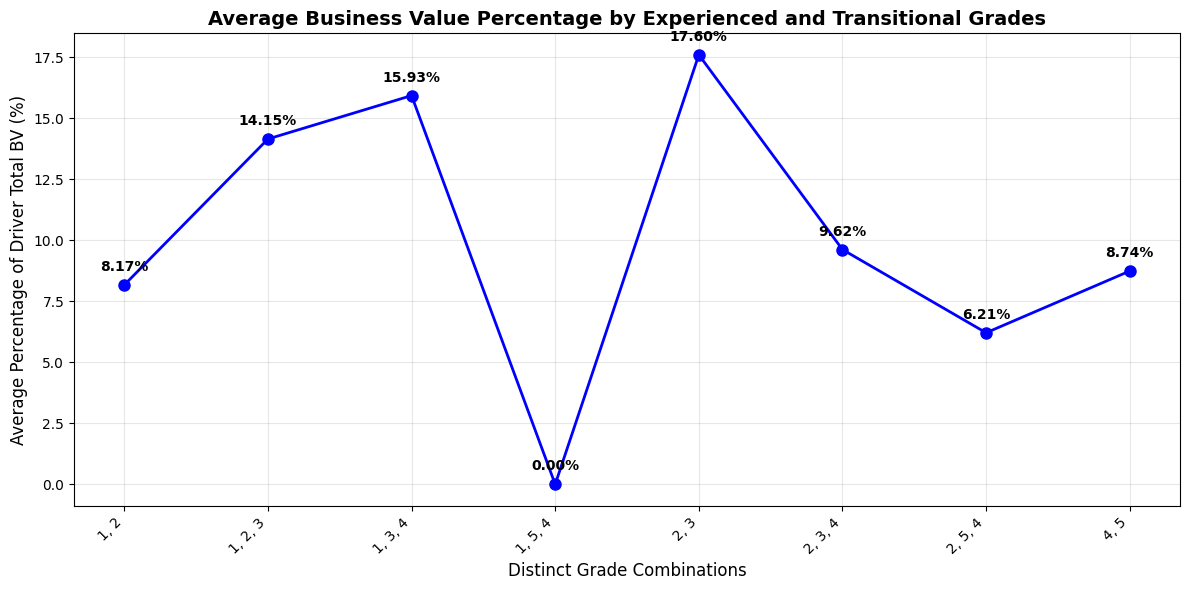

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plot_df = spark.sql("""WITH promotional_drivers AS (
    SELECT
        Driver_ID,
        COLLECT_SET(Grade) AS Distinct_Grades,
        ARRAY_UNION(COLLECT_SET(Joining_Designation), COLLECT_SET(Grade)) AS All_Distinct_Roles
    FROM ola_drivers
    GROUP BY Driver_ID
    HAVING SIZE(COLLECT_SET(Grade)) > 1
),
DriverGradeBusiness AS (
    SELECT
        od.Driver_ID,
        od.Grade,
        SUM(od.Total_Business_Value) AS Business_Value_Per_Grade
    FROM ola_drivers od
    INNER JOIN promotional_drivers pd ON od.Driver_ID = pd.Driver_ID
    GROUP BY od.Driver_ID, od.Grade
),
RankedDriverPerformance AS (
    SELECT
        dgb.Driver_ID,
        dgb.Grade,
        dgb.Business_Value_Per_Grade,
        (dgb.Business_Value_Per_Grade * 100.0 / SUM(dgb.Business_Value_Per_Grade) OVER (PARTITION BY dgb.Driver_ID)) AS Percentage_of_Driver_Total_BV
    FROM DriverGradeBusiness dgb
),
DriverRows AS (
    SELECT
        Driver_ID,
        Grade,
        Business_Value_Per_Grade,
        Percentage_of_Driver_Total_BV,
        LAG(Percentage_of_Driver_Total_BV, 1, 0.0) OVER (PARTITION BY Driver_ID ORDER BY Grade) AS Lagged_Percentage_BV,
        (Percentage_of_Driver_Total_BV - LAG(Percentage_of_Driver_Total_BV, 1, 0.0) OVER (PARTITION BY Driver_ID ORDER BY Grade)) AS Percentage_Change_BV,
        ROW_NUMBER() OVER (PARTITION BY Driver_ID ORDER BY Grade) as rn
    FROM RankedDriverPerformance
),
Promoted_Grade_Contribution AS (
    SELECT
        pd.Driver_ID,
        pd.All_Distinct_Roles,
        pt.Percentage_of_Driver_Total_BV
    FROM (
        SELECT
            Driver_ID,
            Grade,
            Business_Value_Per_Grade,
            Percentage_of_Driver_Total_BV,
            Lagged_Percentage_BV,
            Percentage_Change_BV
        FROM DriverRows
        WHERE rn = 2
    ) pt
    INNER JOIN promotional_drivers pd ON pd.Driver_ID = pt.Driver_ID
)
SELECT
    All_Distinct_Roles AS Num_Distinct_Grades,
    ROUND(AVG(Percentage_of_Driver_Total_BV), 2) AS Avg_Percentage_of_Driver_Total_BV
FROM Promoted_Grade_Contribution
GROUP BY Num_Distinct_Grades
ORDER BY Num_Distinct_Grades ASC
""").toPandas()

# Convert arrays to string labels for plotting
plot_df['Grade_Label'] = plot_df['Num_Distinct_Grades'].apply(lambda x: str(x).replace('[', '').replace(']', ''))

# Create the line chart
plt.figure(figsize=(12, 6))
plt.plot(plot_df['Grade_Label'], plot_df['Avg_Percentage_of_Driver_Total_BV'],
         marker='o', linewidth=2, markersize=8, color='blue')

plt.title('Average Business Value Percentage by Experienced and Transitional Grades', fontsize=14, fontweight='bold')
plt.xlabel('Distinct Grade Combinations', fontsize=12)
plt.ylabel('Average Percentage of Driver Total BV (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

# Add value labels on points
for i, (label, value) in enumerate(zip(plot_df['Grade_Label'], plot_df['Avg_Percentage_of_Driver_Total_BV'])):
    plt.annotate(f'{value}%', (i, value), textcoords="offset points",
                xytext=(0,10), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**City Distributions**

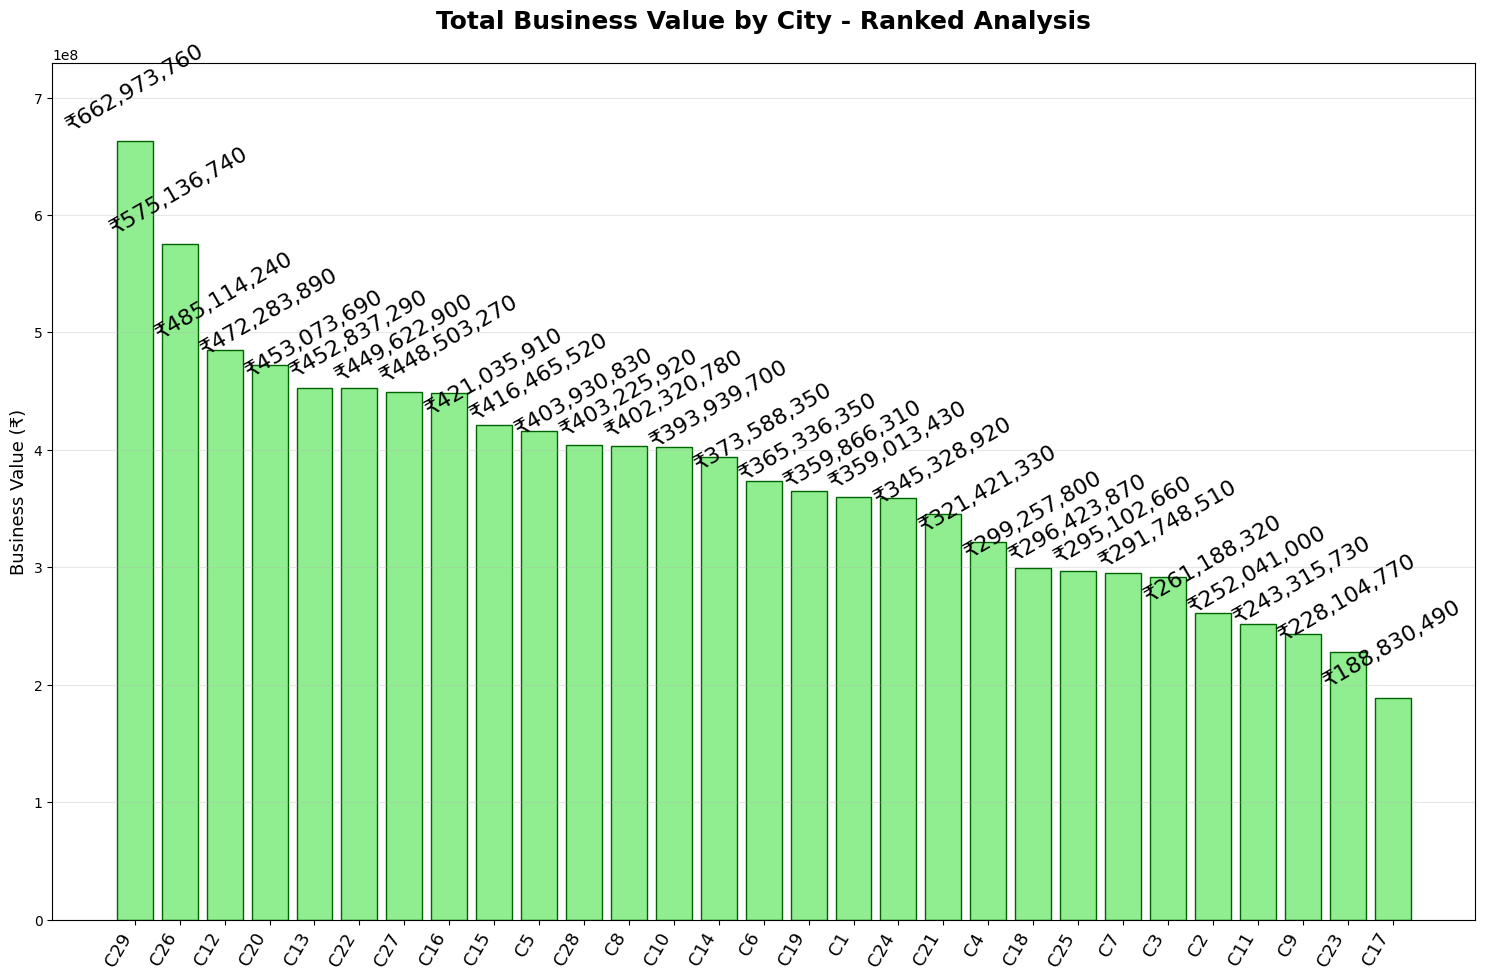

In [ ]:
# Convert Spark DataFrame to pandas DataFrame
spark_df_pd = spark_df.toPandas()

# Get the data
city_business = spark_df_pd.groupby("City")["Total_Business_Value"].sum().sort_values(ascending=False)

plt.figure(figsize=(15, 10))  # Even larger plot
bars = plt.bar(range(len(city_business)), city_business.values, color='lightgreen', edgecolor='darkgreen')

# More tilted numbering (60 degrees)
plt.xticks(range(len(city_business)),
           [f"{city}" for i, city in enumerate(city_business.index)],
           rotation=60, ha='right', fontsize=13)

plt.title("Total Business Value by City - Ranked Analysis", fontsize=18, fontweight='bold', pad=25)
plt.ylabel('Business Value (₹)', fontsize=13)

# Value labels on bars
for i, value in enumerate(city_business.values):
    plt.text(i, value + (__builtins__.max(city_business.values) * 0.008),
             f'₹{value:,.0f}', ha='center', va='bottom', fontsize=16,
             rotation=30)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.ylim(0, __builtins__.max(city_business.values) * 1.1) # Extend y-axis limit by 10%
plt.show()

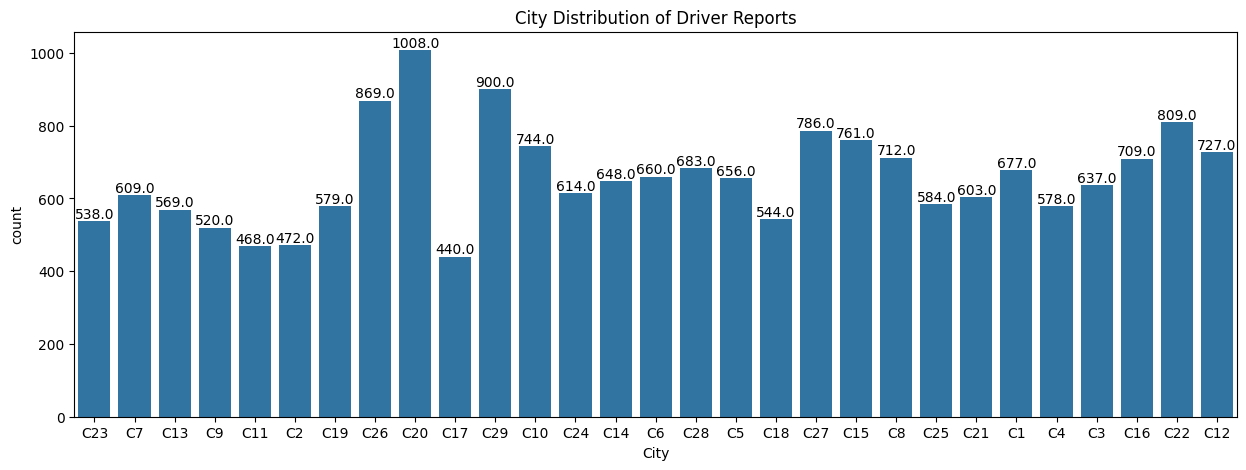

In [ ]:
# Convert Spark DataFrame to pandas DataFrame for plotting with seaborn
spark_df_pd = spark_df.toPandas()

plt.figure(figsize=(15, 5))
ax = sns.countplot(data=spark_df_pd, x="City")
plt.title("City Distribution of Driver Reports")

# Add numerical labels to the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

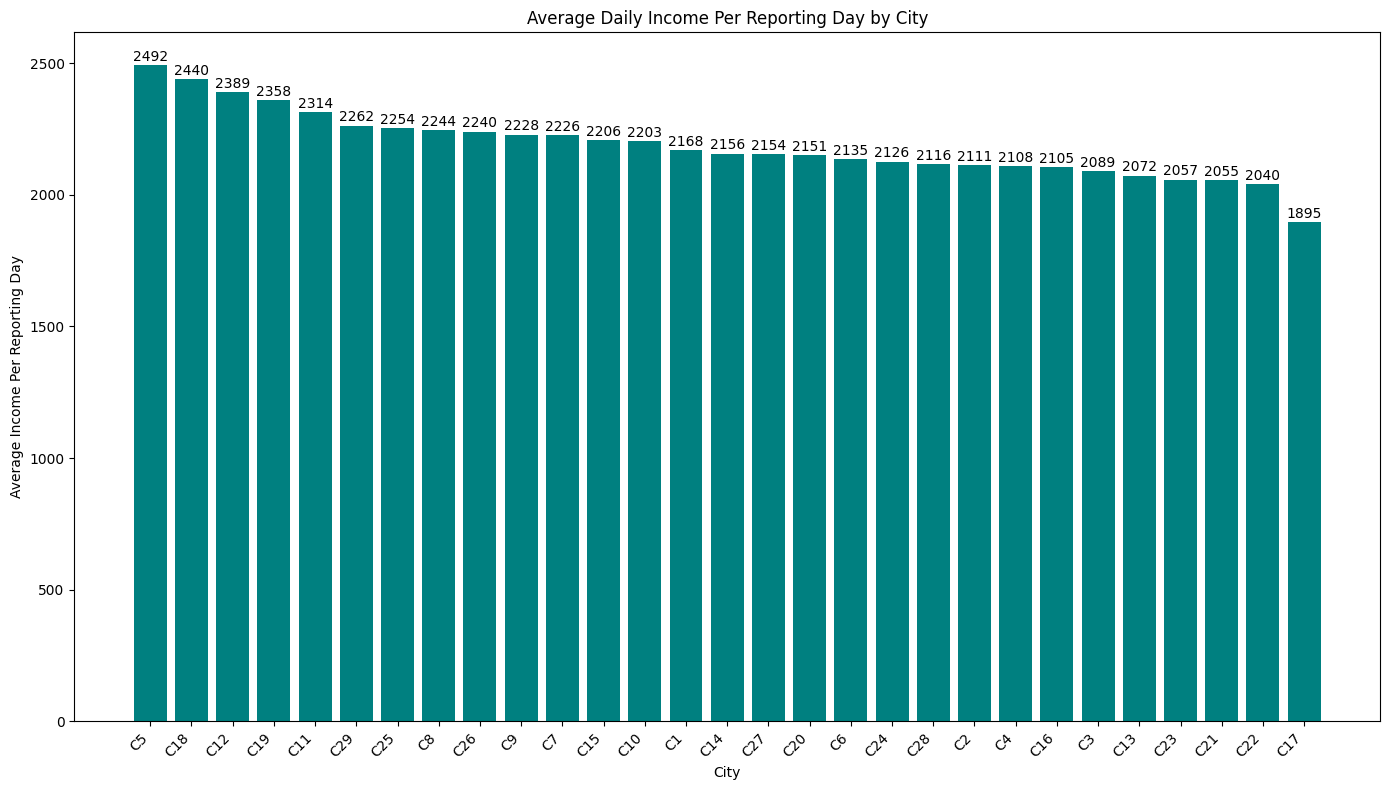

In [ ]:
# Execute the SQL query and convert the result to a pandas DataFrame
average_income_per_reporting_day_df = spark.sql("""
    WITH CityReportingDays AS (
        SELECT
            City,
            COUNT(*) * 30 as Total_Reporting_Days,
            SUM(Income) as Sum_Income
        FROM ola_drivers
        GROUP BY City
    )
    SELECT
        City,
        ROUND((Sum_Income / Total_Reporting_Days),0) as Average_Income_Per_Reporting_Day
    FROM CityReportingDays
    ORDER BY Average_Income_Per_Reporting_Day DESC
""").toPandas()

# Create a bar chart
plt.figure(figsize=(14, 8))
bars = plt.bar(average_income_per_reporting_day_df['City'], average_income_per_reporting_day_df['Average_Income_Per_Reporting_Day'], color='teal')
plt.xlabel('City')
plt.ylabel('Average Income Per Reporting Day')
plt.title('Average Daily Income Per Reporting Day by City')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add value labels on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.show()

In [ ]:
spark.sql("""select round(count(*)/(select count(distinct Driver_ID) from ola_drivers),0) as Averagely_Reporting_days from ola_drivers""").show()

+------------------------+
|Averagely_Reporting_days|
+------------------------+
|                     8.0|
+------------------------+



- Highest marked is for C20 giving a reporting count on drivers of 1008, taking in with respect to overall, i.e, **1008 x 30 = 30240 estimated days**. Each Trip daily Income per driver could be around **₹ 2151**. Most of the cities in India charge around **150-200** minimum in bracket while commuting into popular areas which are heavily crowded taking that into assumption,
 **Average trips being conducted = $(\frac{2151}{200}$,$\frac{2151}{150}) = (10.7,14.34) \approx$ 11 - 14  trips per driver.**

 - Maximum amount as Income generation on daily basis come from C5 where on a day basis they earn around **₹ 2492**. Average trips conducted could be around $(12.47,16.63) \approx$ **12 - 17 trips per driver.**

 - C17 city gets the least reporting days around **13200 estimated days**. And on the least trips per day basis which is estimatedly given around $(9.47,12.63) \approx$ **9 - 13 trips per driver**.

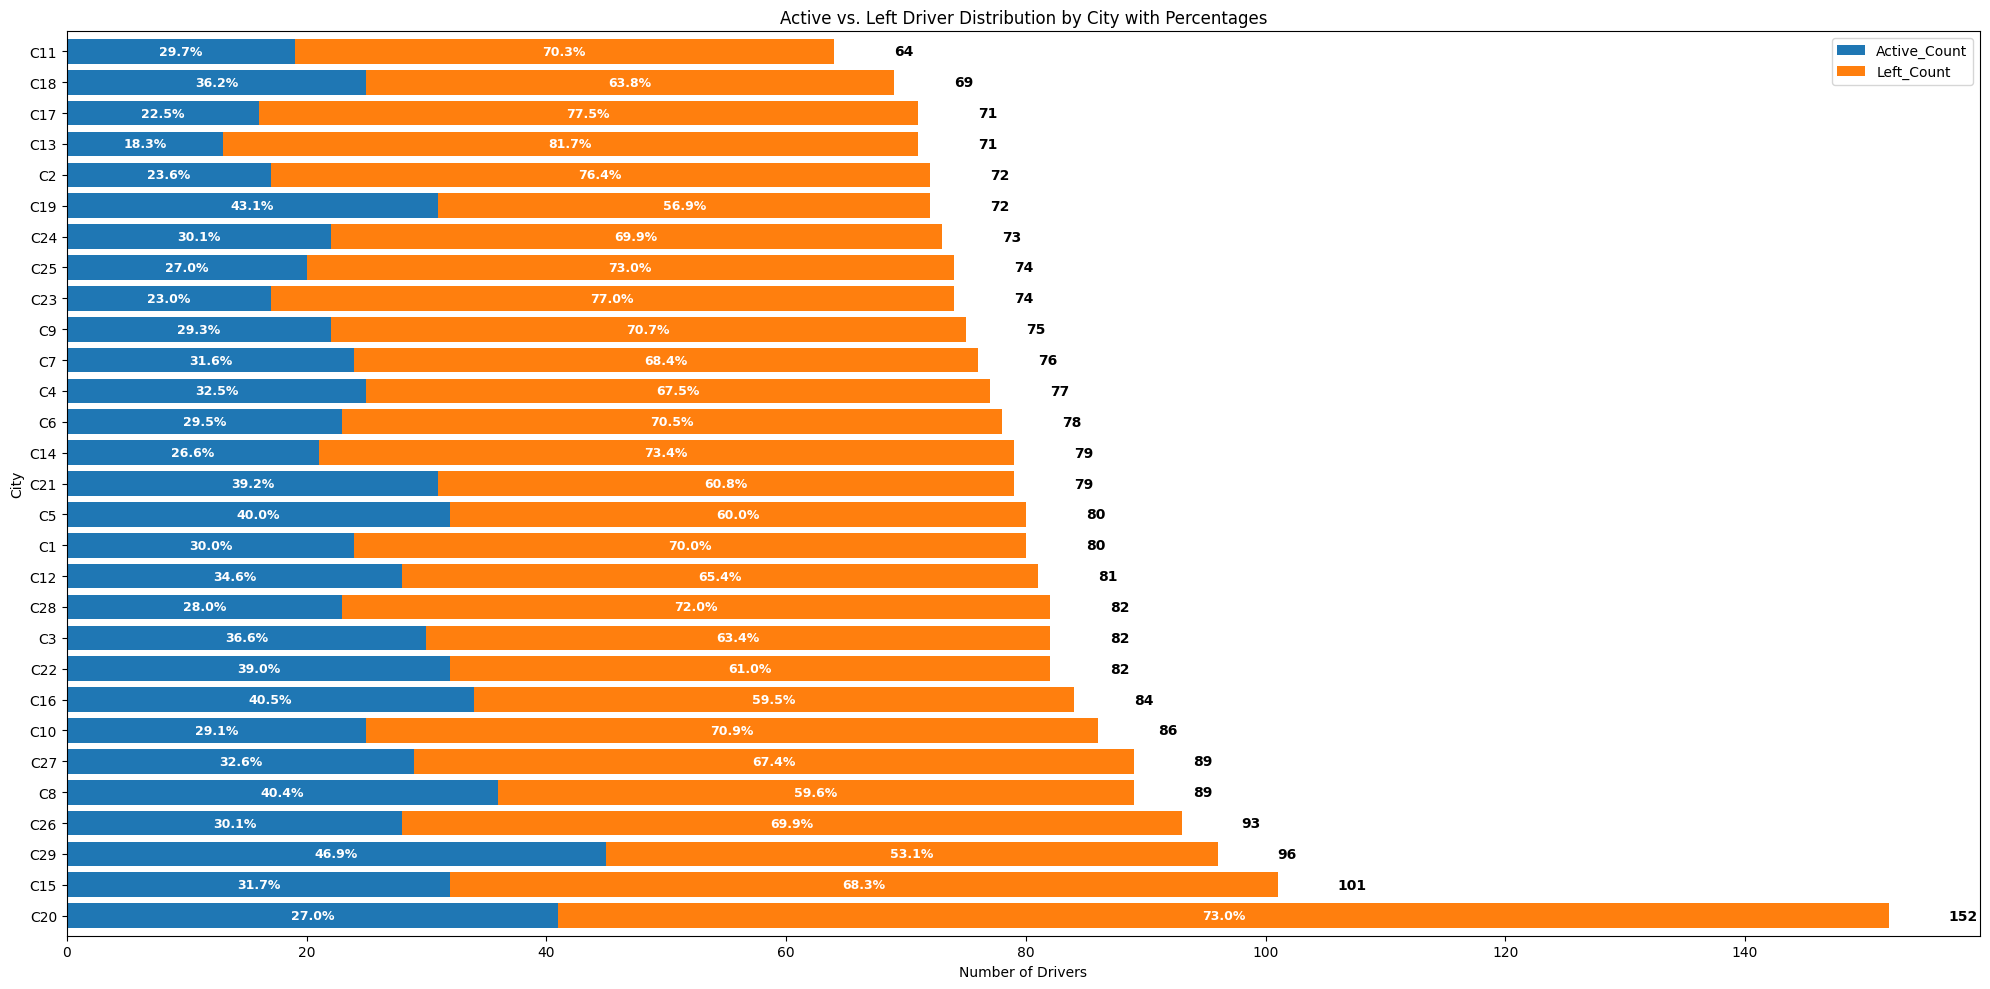

In [ ]:
# Get city distribution for active drivers
active_city_counts = spark.sql("""
    SELECT City, COUNT(DISTINCT Driver_ID) as Active_Count
    FROM ola_drivers
    WHERE Driver_ID not in (select Driver_ID from ola_drivers where LastWorkingDate is not null)
    GROUP BY City
""").toPandas()

# Get city distribution for left drivers
left_city_counts = spark.sql("""
    SELECT City, COUNT(DISTINCT Driver_ID) as Left_Count
    FROM ola_drivers
    WHERE LastWorkingDate IS NOT NULL
    GROUP BY City
""").toPandas()

# Merge the two dataframes
city_distribution_df = pd.merge(active_city_counts, left_city_counts, on='City', how='outer').fillna(0)

# Calculate total for percentage calculation
city_distribution_df['Total'] = city_distribution_df['Active_Count'] + city_distribution_df['Left_Count']

# Set City as index for plotting and sort by Total
city_distribution_df = city_distribution_df.set_index('City').sort_values(by='Total', ascending=False)

# Create a stacked horizontal bar chart with wider bars
ax = city_distribution_df[['Active_Count', 'Left_Count']].plot(kind='barh', stacked=True, figsize=(20, 10), width=0.8)
plt.xlabel('Number of Drivers')
plt.ylabel('City')
plt.title('Active vs. Left Driver Distribution by City with Percentages')
plt.tight_layout()

# Add percentage labels to the bars and total count labels on the right of the stacks with bold font
for i, (city, row) in enumerate(city_distribution_df.iterrows()):
    total = row['Total']
    active_percentage = (row['Active_Count'] / total) * 100 if total > 0 else 0
    left_percentage = (row['Left_Count'] / total) * 100 if total > 0 else 0

    # Add percentage for Active drivers
    if row['Active_Count'] > 0:
        ax.text(row['Active_Count'] / 2, i, f'{active_percentage:.1f}%', ha='center', va='center', color='white', fontsize=9, fontweight='bold')

    # Add percentage for Left drivers
    if row['Left_Count'] > 0:
        ax.text(row['Active_Count'] + row['Left_Count'] / 2, i, f'{left_percentage:.1f}%', ha='center', va='center', color='white', fontsize=9, fontweight='bold')

    # Add total count on the right of the stack
    ax.text(total + 5, i, str(int(total)), ha='left', va='center', fontweight='bold')


plt.show()

In [ ]:
# Calculate the total number of active drivers and total drivers across all cities
total_active_drivers = city_distribution_df['Active_Count'].sum()
total_left_drivers = city_distribution_df['Left_Count'].sum()
total_drivers = city_distribution_df['Total'].sum()

# Calculate the average percentage of active drivers across all cities
average_active_percentage = (total_active_drivers / total_drivers) * 100 if total_drivers > 0 else 0

# Calculate the active percentage for each city
city_distribution_df['Active_Percentage'] = (city_distribution_df['Active_Count'] / city_distribution_df['Total']) * 100

# Identify cities with above and below average active percentage
cities_above_average = city_distribution_df[city_distribution_df['Active_Percentage'] > average_active_percentage]
cities_below_average = city_distribution_df[city_distribution_df['Active_Percentage'] <= average_active_percentage]

# Get the list of cities
cities_above_average_list = cities_above_average.index.tolist()
cities_below_average_list = cities_below_average.index.tolist()

# Calculate the total number of drivers in each category
total_drivers_above_average = cities_above_average['Total'].sum()
total_drivers_below_average = cities_below_average['Total'].sum()

# Calculate the total number of active drivers in each category
total_active_drivers_above_average = cities_above_average['Active_Count'].sum()
total_active_drivers_below_average = cities_below_average['Active_Count'].sum()

# Calculate the total number of left drivers in each category
total_left_drivers_above_average = cities_above_average['Left_Count'].sum()
total_left_drivers_below_average = cities_below_average['Left_Count'].sum()


print(f"Cities with above-average active driver percentage ({average_active_percentage:.2f}%):")
print(cities_above_average_list)
print(f"Total drivers in these cities: {total_drivers_above_average}")
print(f"Total active drivers in these cities: {total_active_drivers_above_average}")
print(f"Total left drivers in these cities: {total_left_drivers_above_average}")
print("-" * 30)
print(f"Cities with below-average active driver percentage ({average_active_percentage:.2f}%):")
print(cities_below_average_list)
print(f"Total drivers in these cities: {total_drivers_below_average}")
print(f"Total active drivers in these cities: {total_active_drivers_below_average}")
print(f"Total left drivers in these cities: {total_left_drivers_below_average}")

Cities with above-average active driver percentage (32.13%):
['C29', 'C8', 'C27', 'C16', 'C22', 'C3', 'C12', 'C5', 'C21', 'C4', 'C19', 'C18']
Total drivers in these cities: 980
Total active drivers in these cities: 378
Total left drivers in these cities: 602
------------------------------
Cities with below-average active driver percentage (32.13%):
['C20', 'C15', 'C26', 'C10', 'C28', 'C1', 'C14', 'C6', 'C7', 'C9', 'C23', 'C25', 'C24', 'C2', 'C13', 'C17', 'C11']
Total drivers in these cities: 1401
Total active drivers in these cities: 387
Total left drivers in these cities: 1014


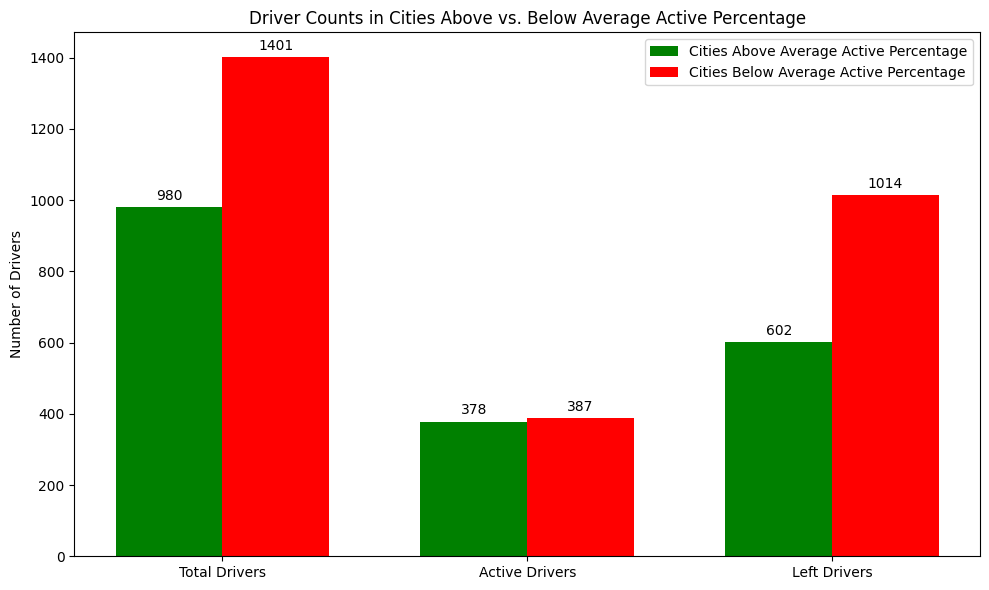

In [ ]:
# Data for plotting
categories = ['Total Drivers', 'Active Drivers', 'Left Drivers']
above_average_counts = [total_drivers_above_average, total_active_drivers_above_average, total_left_drivers_above_average]
below_average_counts = [total_drivers_below_average, total_active_drivers_below_average, total_left_drivers_below_average]

x = np.arange(len(categories))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, above_average_counts, width, label='Cities Above Average Active Percentage', color='green')
rects2 = ax.bar(x + width/2, below_average_counts, width, label='Cities Below Average Active Percentage', color='red')

# Add some text for labels, title and axes ticks
ax.set_ylabel('Number of Drivers')
ax.set_title('Driver Counts in Cities Above vs. Below Average Active Percentage')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Add labels to the bars
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

plt.show()

- Around **58.84%** of the labour have been in the area of red zone where **attrition rate** on cities are higher which would indirectly give more pressure towards the driver on to achieve the target, could even cause a **huge loss** triggered by deteriorating health and lack of support by the remaining partners as drivers serving for the same city.

- **41.12%** of drivers are still active where each city is having **more than 40% of the drivers** which could reduce the burden on the driver for a good cause as the **cities might possess more population on the ride**.

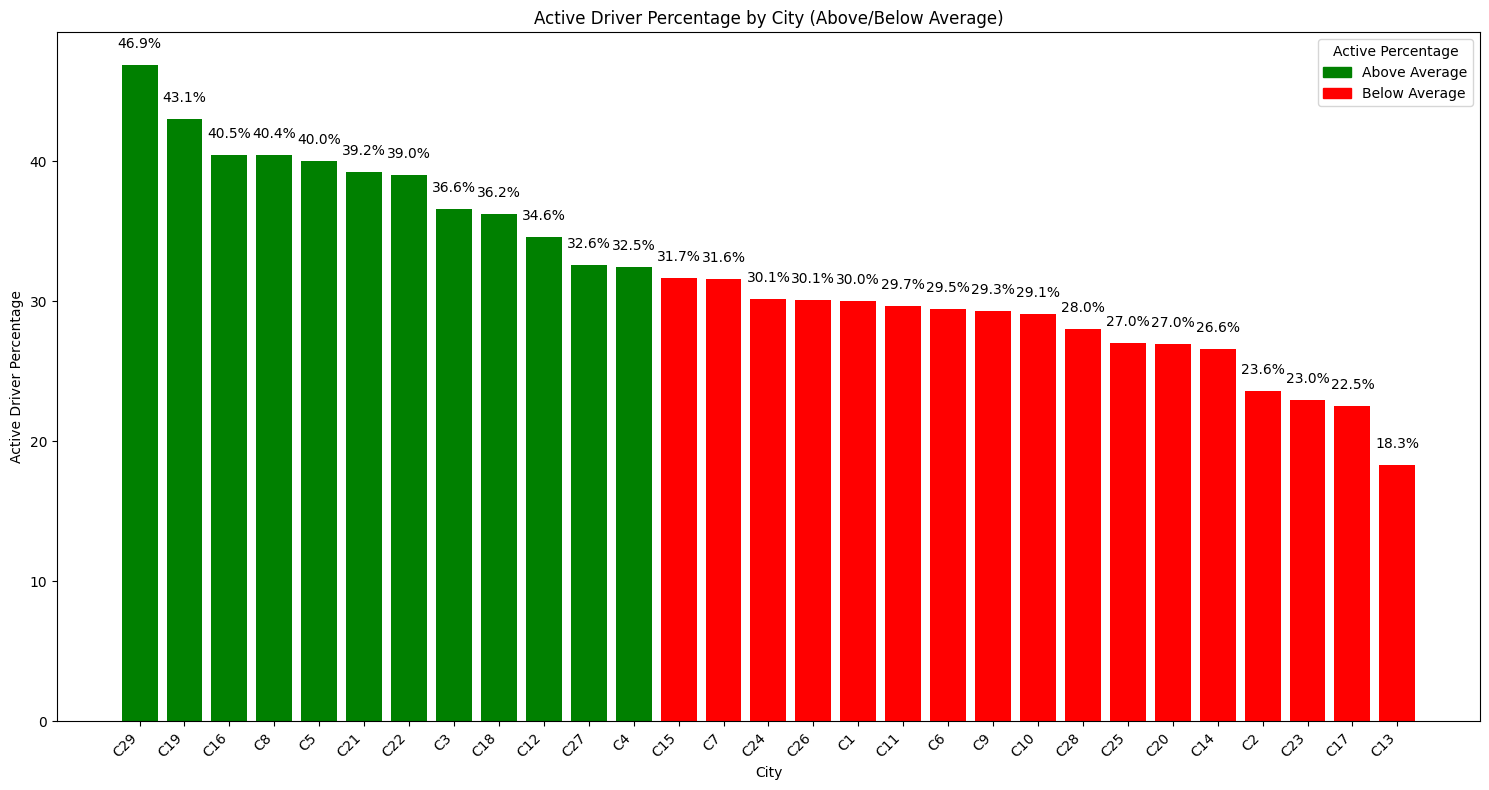

In [ ]:
# Combine above and below average dataframes and sort by active percentage
cities_comparison_df = pd.concat([cities_above_average, cities_below_average]).sort_values(by='Active_Percentage', ascending=False)

# Define colors based on whether the city is above or below average
colors = ['green' if city in cities_above_average_list else 'red' for city in cities_comparison_df.index]

# Create the bar chart
plt.figure(figsize=(15, 8))
bars = plt.bar(cities_comparison_df.index, cities_comparison_df['Active_Percentage'], color=colors)
plt.xlabel('City')
plt.ylabel('Active Driver Percentage')
plt.title('Active Driver Percentage by City (Above/Below Average)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add percentage labels to the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom')

# Create a legend
legend_labels = {'Above Average': 'green', 'Below Average': 'red'}
handles = [plt.Rectangle((0,0),1,1, color=legend_labels[label]) for label in legend_labels]
plt.legend(handles, legend_labels.keys(), title='Active Percentage')


plt.show()

- Out of all the **29 cities**, the better performer with respect to **driver retentions** are the categorized **12 cities** under the **area of green zones**.

- In the **Top 10 Cities of the Average Income** being produced have a **green zone 4 cities** which are on retaining the drivers of above **40%** even when the Ola services are shown on crisis where **above 50%** of the manpower being deployed have just **left** the organisation causing a huge burst on its growth.

- The one of **minimum income** producing city's **C22** which could just bring a daily generation on **₹ 2040** on a daily basis could be **approx 8-11 trips.** Main reason is that trips that each customer would do for a driver on a **period of time within these cities are minimal** and **competition on certain other rivals could be a possible reason for drivers to be impacted on a positive note where a bit number of competition would just reduce the overall burden for the drivers** as the pricing flexibility and duration on each place would be an advantage for one part of the **customer's interest** catering towards the **drivers needs**.

- Higher Attrition rate on drivers are being evident on the remaning **17 cities** especially on the areas where the **cities produce more lesser than the average Income rate**. Only **18.3%** of the drivers are still serving in C13 where by the average income earned by each driver is **₹ 2072** which is still a bit lesser to other cities by **₹100 - ₹150** in a month could by a deficit of **3000 - 4500** rupees that is **5% - 7%** of the **Income to be recieved**. This could lead to the employers to leave the organisation for better benifits and convinience on driver's choice on capability.

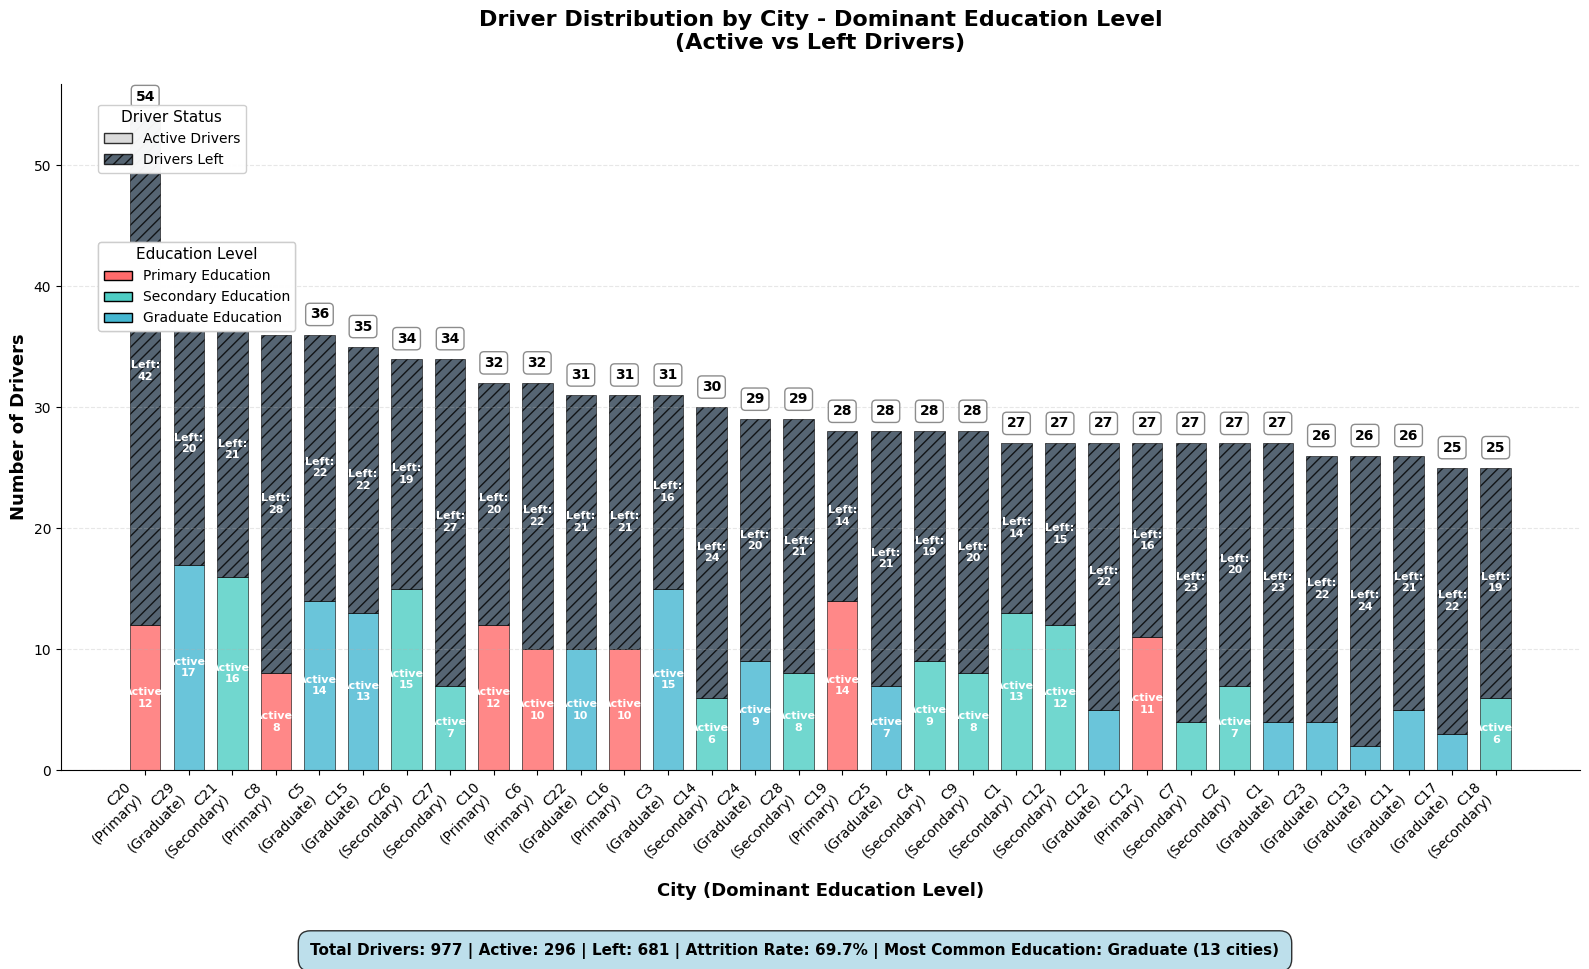

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Execute the SQL query and convert to pandas
result_df = spark.sql("""
With CityRnk As(
    select City, Education_level, count(distinct driver_id) as Total_drivers,
    dense_rank() over (partition by city order by count(distinct driver_id) desc) as Driver_Rank
    from ola_drivers
    group by City, Education_level
),
LeftMembers as(
    select City, Education_level, count(distinct Driver_ID) as Total_drivers_left
    from ola_drivers
    where LastWorkingDate is not null
    group by City, Education_level
)
select cr.City, cr.Education_level, cr.Total_drivers, lm.Total_drivers_left
from CityRnk cr
inner join LeftMembers lm on cr.City = lm.City and cr.Education_level = lm.Education_level
where cr.Driver_Rank = 1
""").toPandas()

# Map education levels to labels for better readability
education_labels = {0: 'Primary', 1: 'Secondary', 2: 'Graduate'}
result_df['Education_Level_Label'] = result_df['Education_level'].map(education_labels)

# Create city labels with education level for x-axis
result_df['City_Label'] = result_df['City'] + '\n(' + result_df['Education_Level_Label'] + ')'

# Calculate remaining drivers (Total_drivers - Total_drivers_left)
result_df['Total_drivers_remaining'] = result_df['Total_drivers'] - result_df['Total_drivers_left']

# Sort by total drivers for better visualization
result_df = result_df.sort_values('Total_drivers', ascending=False)

# Create stacked bar chart
plt.figure(figsize=(16, 10))
bar_width = 0.7

# Define distinct colors for education levels
education_colors = {'Primary': '#FF6B6B', 'Secondary': '#4ECDC4', 'Graduate': '#45B7D1'}

# Define colors for active vs left drivers (lighter for active, darker for left)
active_colors = [education_colors[label] for label in result_df['Education_Level_Label']]
left_colors = ['#2C3E50' for _ in result_df['Education_Level_Label']]  # Dark gray for left drivers

# Create stacked bars
bars_remaining = plt.bar(result_df['City_Label'], result_df['Total_drivers_remaining'],
                        color=active_colors, edgecolor='black', linewidth=0.5,
                        label='Active Drivers', width=bar_width, alpha=0.8)

bars_left = plt.bar(result_df['City_Label'], result_df['Total_drivers_left'],
                   bottom=result_df['Total_drivers_remaining'],
                   color=left_colors, edgecolor='black', linewidth=0.5,
                   label='Drivers Left', width=bar_width, alpha=0.8, hatch='///')

plt.xlabel('City (Dominant Education Level)', fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('Number of Drivers', fontsize=13, fontweight='bold')
plt.title('Driver Distribution by City - Dominant Education Level\n(Active vs Left Drivers)',
          fontsize=16, fontweight='bold', pad=25)

# Add value labels on bars
max_total = result_df['Total_drivers'].max()
for i, (city, total, remaining, left) in enumerate(zip(result_df['City_Label'],
                                                      result_df['Total_drivers'],
                                                      result_df['Total_drivers_remaining'],
                                                      result_df['Total_drivers_left'])):
    # Total drivers label at top
    plt.text(i, total + max_total * 0.02, f'{total:,}',
             ha='center', va='bottom', fontsize=10, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9, edgecolor='gray'))

    # Active drivers label (if significant)
    if remaining > max_total * 0.1:  # Only label if bar is substantial
        plt.text(i, remaining/2, f'Active:\n{remaining:,}',
                ha='center', va='center', fontsize=8, fontweight='bold', color='white')

    # Left drivers label (if significant)
    if left > max_total * 0.1:
        plt.text(i, remaining + left/2, f'Left:\n{left:,}',
                ha='center', va='center', fontsize=8, fontweight='bold', color='white')

# Create custom legends
from matplotlib.patches import Patch

# Legend 1: Driver Status
driver_legend_elements = [
    Patch(facecolor='lightgray', alpha=0.8, edgecolor='black', label='Active Drivers'),
    Patch(facecolor='#2C3E50', alpha=0.8, hatch='///', edgecolor='black', label='Drivers Left')
]

# Legend 2: Education Levels
education_legend_elements = [
    Patch(facecolor=education_colors['Primary'], label='Primary Education', edgecolor='black'),
    Patch(facecolor=education_colors['Secondary'], label='Secondary Education', edgecolor='black'),
    Patch(facecolor=education_colors['Graduate'], label='Graduate Education', edgecolor='black')
]

# Add legends with better positioning
legend1 = plt.legend(handles=driver_legend_elements, loc='upper left',
                    title='Driver Status', title_fontsize=11, fontsize=10,
                    framealpha=0.95, bbox_to_anchor=(0.02, 0.98))
legend2 = plt.legend(handles=education_legend_elements, loc='upper left',
                    title='Education Level', title_fontsize=11, fontsize=10,
                    framealpha=0.95, bbox_to_anchor=(0.02, 0.78))

plt.gca().add_artist(legend1)
plt.gca().add_artist(legend2)

# Customize the plot
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add some statistics as text
total_active = result_df['Total_drivers_remaining'].sum()
total_left = result_df['Total_drivers_left'].sum()
total_drivers = total_active + total_left
attrition_rate = (total_left / total_drivers) * 100

# Find most common education level
most_common_edu = result_df['Education_Level_Label'].mode()[0]
cities_with_most_common_edu = result_df[result_df['Education_Level_Label'] == most_common_edu]['City'].nunique()

plt.figtext(0.5, 0.01,
           f'Total Drivers: {total_drivers:,} | Active: {total_active:,} | Left: {total_left:,} | '
           f'Attrition Rate: {attrition_rate:.1f}% | Most Common Education: {most_common_edu} ({cities_with_most_common_edu} cities)',
           ha='center', fontsize=11, fontweight='bold',
           bbox=dict(boxstyle="round,pad=0.8", facecolor='lightblue', alpha=0.8))

plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

**Optimization Model**